# MOFF2 

Update: June/2026


```
All data and analyses scripts for figures presented in MOFF2 manuscript and SI.
```

In [1]:
import numpy as np
import pandas as pd

# plot!
import matplotlib.pyplot as plt
from matplotlib import colors

# sklearn
import scipy as scipy
from scipy.optimize import curve_fit
from scipy.ndimage.filters import gaussian_filter
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

# UMAP
import umap
import hdbscan
import sklearn.cluster as cluster
from sklearn.metrics import adjusted_rand_score, adjusted_mutual_info_score

import re
import seaborn as sns 

from matplotlib.colors import LogNorm
import os
from scipy.stats import gaussian_kde

import argparse
import pickle
import mdtraj
import shutil
import json
import sys
import os
import seaborn as sns
import sys
import pandas as pd



path='./'
savepath='./manu_figures/'

import matplotlib as mpl
mpl.rcParams['font.family']       = 'sans-serif'
mpl.rcParams['font.sans-serif']   = ['Arial','Helvetica','DejaVu Sans']
mpl.rcParams['font.size']         = 12
mpl.rcParams['axes.titlesize']    = 12
mpl.rcParams['axes.labelsize']    = 12
mpl.rcParams['xtick.labelsize']   = 12
mpl.rcParams['ytick.labelsize']   = 12
mpl.rcParams['legend.fontsize']   = 12
# Ensure vectors with live text
mpl.rcParams['pdf.fonttype']      = 42
mpl.rcParams['ps.fonttype']       = 42


print("Loaded")

/tmp/ipykernel_41/2808240999.py:11: DeprecationWarning: Please use `gaussian_filter` from the `scipy.ndimage` namespace, the `scipy.ndimage.filters` namespace is deprecated.
  from scipy.ndimage.filters import gaussian_filter
2026-06-08 14:58:38.916058: I tensorflow/core/platform/cpu_feature_guard.cc:193] This TensorFlow binary is optimized with oneAPI Deep Neural Network Library (oneDNN) to use the following CPU instructions in performance-critical operations:  AVX2 AVX512F AVX512_VNNI AVX512_BF16 FMA
To enable them in other operations, rebuild TensorFlow with the appropriate compiler flags.
2026-06-08 14:58:39.833153: I tensorflow/core/util/port.cc:104] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.


Loaded


## Main Figure 1

Pair: THR-PHE
sigma = 0.5990 nm
lambda = 0.7362
theta = 0.6101 kJ/mol
r_min = 0.6724 nm
mu = 0.9224 nm
delta = 0.1000 nm
r_cut = 2.3960 nm
AH(mu) = -0.1704 kJ/mol
Gaussian(mu) = 0.6101 kJ/mol
Delta W* = W_total(mu) = 0.4397 kJ/mol


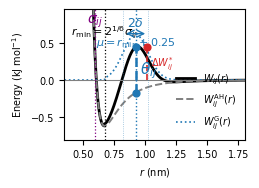

Saved to: ./manu_figures/Figure1A_AH_G.pdf


In [8]:
#!/usr/bin/env python3

import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import pickle
import sys
import os
from openabc.forcefields.MOFF2.lib import _amino_acids, _kcal_to_kj  

# ============================================================
# User settings
# ============================================================

new_pkl = "./parameters/MOFF2.pkl"
param_csv = "./parameters/HPS_Urry_parameters.csv"

savepath = "./manu_figures/"
os.makedirs(savepath, exist_ok=True)

# Representative pair
aa1 = "THR"
aa2 = "PHE"

# Gaussian parameters
delta = 0.10        # nm, Gaussian width
extra = 0.25        # nm, offset from r_min to Gaussian center
c216 = 2 ** (1.0 / 6.0)

# Avoid too-small r because repulsive wall becomes very large
r = np.linspace(0.35, 2.0, 800)

AA = _amino_acids


# ============================================================
# Load sigma and epsilon
# ============================================================

df = pd.read_csv(param_csv)

sigma = np.zeros((20, 20))
epsilon = 0.2 * _kcal_to_kj  # kcal/mol to kJ/mol

for _, row in df.iterrows():
    i = AA.index(row["atom_type1"])
    j = AA.index(row["atom_type2"])
    sigma[i, j] = sigma[j, i] = row["sigma"]


# ============================================================
# Load MOFF2 parameters
# ============================================================

with open(new_pkl, "rb") as f:
    new = pickle.load(f)

H_new = np.asarray(new["hydrophobic_scale"])
G_new = np.asarray(new.get("gauss_coeffs", np.zeros(210)))


# ============================================================
# Build symmetric pair-index mapping
# ============================================================

rows, cols = np.triu_indices(20, 0)

pair_idx = np.zeros((20, 20), dtype=int)
pair_idx[rows, cols] = np.arange(210)
pair_idx[cols, rows] = np.arange(210)


# ============================================================
# AH piecewise potential
# ============================================================

def AH_MOFF_piecewise(r, eps, sig, lam):
    r = np.asarray(r)
    U = np.zeros_like(r)

    r_min = c216 * sig
    r_cut = 4.0 * sig

    LJ = 4.0 * eps * ((sig / r) ** 12 - (sig / r) ** 6)
    LJ_cut = 4.0 * eps * ((sig / r_cut) ** 12 - (sig / r_cut) ** 6)

    s1 = r < r_min
    s2 = (r >= r_min) & (r < r_cut)

    U_excl = np.zeros_like(r)
    U_excl[s1] = LJ[s1] + eps

    AH_base = np.zeros_like(r)
    AH_base[s1] = -eps - LJ_cut
    AH_base[s2] = LJ[s2] - LJ_cut

    return U_excl + lam * AH_base


# ============================================================
# Gaussian correction
# ============================================================

def Gaussian_tail(r, sig, theta):
    r = np.asarray(r)

    r_min = c216 * sig
    r_cut = 4.0 * sig
    mu = r_min + extra

    g = np.zeros_like(r)
    mask = (r >= r_min) & (r < r_cut)

    g[mask] = theta * np.exp(
        -((r[mask] - mu) ** 2) / (2 * delta ** 2)
    )

    return g


# ============================================================
# Extract selected pair parameters
# ============================================================

i = AA.index(aa1)
j = AA.index(aa2)

sig = sigma[i, j]
k = pair_idx[i, j]

lam = H_new[i, j]
theta = G_new[k]

r_min = c216 * sig
mu = r_min + extra
r_cut = 4.0 * sig

V_AH = AH_MOFF_piecewise(r, epsilon, sig, lam)
V_G = Gaussian_tail(r, sig, theta)
V_total = V_AH + V_G

# Values exactly at Gaussian center
V_AH_mu = AH_MOFF_piecewise(np.array([mu]), epsilon, sig, lam)[0]
V_G_mu = Gaussian_tail(np.array([mu]), sig, theta)[0]
V_total_mu = V_AH_mu + V_G_mu

Delta_W_star = V_total_mu


# ============================================================
# Print values
# ============================================================

print(f"Pair: {aa1}-{aa2}")
print(f"sigma = {sig:.4f} nm")
print(f"lambda = {lam:.4f}")
print(f"theta = {theta:.4f} kJ/mol")
print(f"r_min = {r_min:.4f} nm")
print(f"mu = {mu:.4f} nm")
print(f"delta = {delta:.4f} nm")
print(f"r_cut = {r_cut:.4f} nm")
print(f"AH(mu) = {V_AH_mu:.4f} kJ/mol")
print(f"Gaussian(mu) = {V_G_mu:.4f} kJ/mol")
print(f"Delta W* = W_total(mu) = {Delta_W_star:.4f} kJ/mol")


# ============================================================
# Plot
# ============================================================

fig, ax = plt.subplots(figsize=(2.8, 2.05))

# Total pair potential
ax.plot(
    r,
    V_total,
    color="black",
    lw=2.0,
    label=r"$W_{ij}(r)$"
)

# AH baseline
ax.plot(
    r,
    V_AH,
    color="gray",
    lw=1.4,
    linestyle="--",
    label=r"$W_{ij}^{\mathrm{AH}}(r)$"
)

# Optional: Gaussian correction alone
ax.plot(
    r,
    V_G,
    color="tab:blue",
    lw=1.2,
    linestyle=":",
    label=r"$W_{ij}^{\mathrm{G}}(r)$"
)

# Zero line
ax.axhline(
    0,
    color="gray",
    lw=0.8
)

# Set axis limits BEFORE adding labels/annotations
ax.set_xlim(0.35, 1.8)
ax.set_ylim(-0.8, 0.95)


# ============================================================
# Mark sigma
# ============================================================

ax.axvline(
    sig,
    color="purple",
    lw=0.9,
    linestyle=":"
)

ax.text(
    sig,
    0.97,
    r"$\sigma_{ij}$",
    transform=ax.get_xaxis_transform(),
    ha="center",
    va="top",
    fontsize=10,
    color="purple"
)


# ============================================================
# Mark LJ minimum / contact minimum r_min = 2^(1/6) sigma
# ============================================================

ax.axvline(
    r_min,
    color="black",
    lw=0.9,
    linestyle=":"
)

ax.text(
    r_min,
    0.89,
    r"$r_{\min}=2^{1/6}\sigma_{ij}$",
    transform=ax.get_xaxis_transform(),
    ha="center",
    va="top",
    fontsize=8,
    color="black"
)


# ============================================================
# Mark Gaussian center mu = r_min + extra
# ============================================================

ax.axvline(
    mu,
    color="tab:blue",
    lw=1.0,
    linestyle=":"
)

ax.text(
    mu,
    0.80,
    r"$\mu=r_{\min}+0.25$",
    transform=ax.get_xaxis_transform(),
    ha="center",
    va="top",
    fontsize=8,
    color="tab:blue"
)


# ============================================================
# Mark Gaussian width delta around mu
# ============================================================

y_width = 0.62

ax.annotate(
    "",
    xy=(mu - delta, y_width),
    xytext=(mu + delta, y_width),
    arrowprops=dict(
        arrowstyle="<->",
        color="tab:blue",
        lw=1.0
    )
)

ax.text(
    mu,
    y_width + 0.06,
    r"$2\delta$",
    ha="center",
    va="bottom",
    fontsize=9,
    color="tab:blue"
)

# Optional vertical guides for mu +/- delta
ax.vlines(
    [mu - delta, mu + delta],
    ymin=-1.25,
    ymax=0.95,
    color="tab:blue",
    linestyle=":",
    lw=0.6,
    alpha=0.5
)


# ============================================================
# Dashed line for Gaussian correction height theta
# From W_AH(mu) to W_AH(mu) + theta
# ============================================================

ax.vlines(
    mu,
    ymin=V_AH_mu,
    ymax=V_total_mu,
    color="tab:blue",
    linestyle="--",
    lw=1.8
)

ax.scatter(
    [mu, mu],
    [V_AH_mu, V_total_mu],
    color="tab:blue",
    s=24,
    zorder=5
)

ax.text(
    mu + 0.035,
    0.5 * (V_AH_mu + V_total_mu),
    r"$\theta_{ij}$",
    color="tab:blue",
    fontsize=11,
    va="center"
)


# ============================================================
# Dashed line for first-solvation-shell energy Delta W*
# From zero to W_total(mu)
# ============================================================

x_delta = mu + 0.09

ax.vlines(
    x_delta,
    ymin=0,
    ymax=Delta_W_star,
    color="tab:red",
    linestyle="--",
    lw=1.2
)

ax.scatter(
    [x_delta],
    [Delta_W_star],
    color="tab:red",
    s=24,
    zorder=5
)

ax.text(
    x_delta + 0.035,
    0.5 * Delta_W_star,
    r"$\Delta W^{*}_{ij}$",
    color="tab:red",
    fontsize=7,
    va="center"
)


# ============================================================
# Labels and style
# ============================================================

#ax.set_title(f"{aa1}-{aa2}", fontsize=12)

ax.set_xlabel(
    r"$r$ (nm)",
    fontsize=7
)

ax.set_ylabel(
    r"Energy (kJ mol$^{-1}$)",
    fontsize=7
)

ax.tick_params(
    axis="both",
    labelsize=7,
    direction="out"
)

ax.legend(
    frameon=False,
    fontsize=7,
    loc="lower right"
)

plt.tight_layout()


# ============================================================
# Save
# ============================================================

out = os.path.join(
    savepath,
    f"Figure1A_AH_G.pdf"
)

plt.savefig(out, dpi=300, bbox_inches="tight")
plt.show()

print(f"Saved to: {out}")

/tmp/ipykernel_559/2549869001.py:119: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap(obj)`` instead.
  color_map = plt.cm.get_cmap("tab10", len(selected_aas))


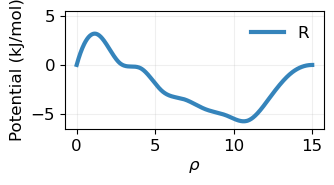

In [9]:
import os
import pickle
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import colormaps
from matplotlib.lines import Line2D
from scipy.interpolate import BSpline

# ─────────────────────────────────────────────────────────────
# CONFIG: define combos
# ─────────────────────────────────────────────────────────────
combos = [
    ("default", "0.8", "1.0", "1.0", "0.01", "0.005"),
]

BASE = "./parameters/"
name='MOFF2'
# AA ordering
aa_labels_orig = [
    "A", "R", "N", "D", "C", "Q", "E", "G", "H", "I",
    "L", "K", "M", "F", "P", "S", "T", "W", "Y", "V"
]
aa_order_target = [
    "G", "A", "R", "K", "E", "D", "Q", "N", "S", "P",
    "T", "H", "C", "M", "V", "L", "I", "Y", "F", "W"
]
order_idx = [aa_labels_orig.index(aa) for aa in aa_order_target]
aa_labels = aa_order_target

# ─────────────────────────────────────────────────────────────
# B-spline basis builder
# ─────────────────────────────────────────────────────────────
def build_clamped_bspline_basis(x, xmin, xmax, n_internal_knots=10, degree=3):
    if n_internal_knots > 0:
        t_internal = np.linspace(xmin, xmax, n_internal_knots + 2)[1:-1]
    else:
        t_internal = np.array([])
    t = np.r_[
        np.repeat(xmin, degree + 1),
        t_internal,
        np.repeat(xmax, degree + 1)
    ]
    n_basis = len(t) - degree - 1
    X = np.empty((len(x), n_basis), dtype=float)
    for i in range(n_basis):
        c = np.zeros(n_basis); c[i] = 1.0
        spl = BSpline(t, c, degree, extrapolate=False)
        X[:, i] = spl(x)
    return np.nan_to_num(X)

# ─────────────────────────────────────────────────────────────
# Load and average spline data for each combo
# ─────────────────────────────────────────────────────────────
combo_curves = []  # each item: shape (20, len(rho))
legend_labels = []
rho_global = None

#color_map = colormaps.get_cmap("tab10").resampled(len(combos))
#combo_colors = [color_map(i) for i in range(len(combos))]

for idx, (group, IDP_w, OP_w, MDP_w, z1, z2) in enumerate(combos):
    result_dir = os.path.join(
        BASE,
    )
    pkl_path = os.path.join(result_dir, f"{name}.pkl")
    if not os.path.isfile(pkl_path):
        print(f"⚠️  Missing: {pkl_path}")
        continue

    with open(pkl_path, "rb") as f:
        d = pickle.load(f)

    # Try direct loading
    if "spl_values" in d and "rho" in d:
        spl_values = np.asarray(d["spl_values"])  # (20, n_groups, len(rho))
        rho = np.asarray(d["rho"])
    else:
        coeffs = np.asarray(d["spl_coeffs"])  # (20, n_groups, n_basis)
        rho_min = float(d.get("rho_min", 0.0))
        rho_max = float(d.get("rho_max", 15.0))
        n_knots = int(d.get("n_internal_knots", 10))
        degree = int(d.get("degree", 3))
        rho = np.linspace(rho_min, rho_max, 500)
        X = build_clamped_bspline_basis(rho, rho_min, rho_max, n_knots, degree)

        # Align dimensions
        min_basis = min(coeffs.shape[-1], X.shape[1])
        coeffs = coeffs[..., :min_basis]
        X = X[:, :min_basis]
        spl_values = np.einsum("agn,tn->agt", coeffs, X)

    # Reorder amino acids
    spl_values = spl_values[order_idx]

    # Average over groups: (20, len(rho))
    mean_splines = np.mean(spl_values, axis=1)
    combo_curves.append(mean_splines)
    #legend_labels.append(f"IDP={IDP_w}, zeta1={z1}")
    legend_labels.append(
    f"group={group}, IDP={IDP_w}, OP={OP_w}, MDP={MDP_w}, zeta1={z1}, zeta2={z2}"
)
    rho_global = rho  # shared



# ─────────────────────────────────────────────────────────────
# Plotting: single figure, selected AAs only
# ─────────────────────────────────────────────────────────────
#selected_aas = ["G", "A", "R", "K", "E", "D", "Q", "N", "S", "P",
#    "T", "H", "C", "M", "V", "L", "I", "Y", "F", "W"]  # ← manually choose here
#selected_aas = ["S", "T", "N", "Q", "C", "G", "P"]
selected_aas = ["R"]
#selected_aas = ["C"]
selected_idx = [aa_labels.index(aa) for aa in selected_aas]

fig, ax = plt.subplots(figsize=(3.5, 2))

# Choose color per AA (optional: automatic colormap)
color_map = plt.cm.get_cmap("tab10", len(selected_aas))
colors = [color_map(i) for i in range(len(selected_aas))]

for i, aa in enumerate(selected_aas):
    idx = selected_idx[i]
    # Use the first combo (or loop if you want to overlay multiple combos)
    for j, curve in enumerate(combo_curves):
        ax.plot(rho_global, curve[idx],
                color=colors[i],
                lw=3,
                label=aa if j == 0 else None,
                alpha=0.9)

ax.set_xlabel(r"$\rho$", fontsize=12)
ax.set_ylabel("Potential (kJ/mol)", fontsize=12)
ax.tick_params(labelsize=12)
ax.legend(frameon=False, ncol=2,fontsize=12)
plt.ylim([-6.5,5.5])
plt.grid(':',alpha = 0.2)
plt.tight_layout()
plt.savefig(savepath+'Figure1A.density.pdf')
plt.show()


## Main Figure 2 & Figure S3

### UMAP of Protein Classes for training and testing

#### 1. UMAP Analysese, and Output pkl file for plots.

In [10]:
#!/usr/bin/env python3
import os
import glob
import random
import pickle
import numpy as np
import matplotlib.pyplot as plt
from collections import Counter
import umap

from mpl_toolkits.axes_grid1.inset_locator import inset_axes, mark_inset


# ============================================================
# Reproducibility
# ============================================================

SEED = 42

os.environ["PYTHONHASHSEED"] = str(SEED)
random.seed(SEED)
np.random.seed(SEED)


# ============================================================
# Paths
# ============================================================

base_dir = "./protein_classes"
savepath = './results/'


umap_cache = os.path.join(savepath, "AA_comp_umap_fixed_embeddings.pkl")


# ============================================================
# Amino acids
# ============================================================

aa_list = [
    "ALA", "ARG", "ASN", "ASP", "CYS",
    "GLN", "GLU", "GLY", "HIS", "ILE",
    "LEU", "LYS", "MET", "PHE", "PRO",
    "SER", "THR", "TRP", "TYR", "VAL"
]


# ============================================================
# Parser
# ============================================================

def parse_folder(folder_name):
    parts = folder_name.split("_")
    dset = parts[0]
    cls = parts[1].upper()
    split = "_".join(parts[2:])
    return dset, cls, split


# ============================================================
# Read residues from CA-only PDB
# ============================================================

def read_residues(pdb):
    residues = []

    with open(pdb) as f:
        for line in f:
            if line.startswith("ATOM"):
                if line[13:15].strip() == "CA":
                    res = line[17:20].strip()
                    if res in aa_list:
                        residues.append(res)

    return residues


def residues_to_key(res):
    return "-".join(res)


# ============================================================
# Panels
# ============================================================

panel_names = [
    "CL_train_all",
    "CL_test_IDP",
    "CL_test_MDP",
    "ESS_train_all",
    "MOFF2_test_all"
]

panels = {
    name: {"IDP": [], "OP": [], "MDP": []}
    for name in panel_names
}

panel_seen = {
    name: set()
    for name in panel_names
}


# ============================================================
# Collect data
# ============================================================

subfolders = sorted([
    f for f in os.listdir(base_dir)
    if os.path.isdir(os.path.join(base_dir, f))
])

for sub in subfolders:

    folder_path = os.path.join(base_dir, sub)

    try:
        dset, cls, split = parse_folder(sub)
    except Exception:
        continue

    pdbs = sorted(glob.glob(os.path.join(folder_path, "*_ca.pdb")))

    for pdb in pdbs:

        residues = read_residues(pdb)

        if not residues:
            continue

        key = residues_to_key(residues)

        counter = Counter(residues)
        total = sum(counter.values())

        freq = [
            counter[a] / total
            for a in aa_list
        ]

        # ----------------------------------------------------
        # Assign panels
        # ----------------------------------------------------

        if dset == "CL" and split == "train":
            name = "CL_train_all"

        elif dset == "CL" and split == "test_reweight" and cls == "IDP":
            name = "CL_test_IDP"

        elif dset == "CL" and split == "test_md" and cls == "IDP":
            name = "CL_test_IDP"

        elif dset == "CL" and split == "test" and cls == "MDP":
            name = "CL_test_MDP"

        elif dset == "ESS" and split == "train":
            name = "ESS_train_all"

        elif dset == "MOFF2" and split == "test":
            name = "MOFF2_test_all"

        else:
            continue

        # Deduplicate within each panel
        if key not in panel_seen[name]:
            panels[name][cls].append(freq)
            panel_seen[name].add(key)


# ============================================================
# Combine for UMAP
# ============================================================

all_data = []
meta = []

for panel in panel_names:
    for cls in ["IDP", "OP", "MDP"]:
        data = panels[panel][cls]

        for d in data:
            all_data.append(d)
            meta.append((panel, cls))

X = np.array(all_data)

print("Total number of unique sequences:", len(X))

for panel in panel_names:
    print(panel)
    for cls in ["IDP", "OP", "MDP"]:
        print(f"  {cls}: {len(panels[panel][cls])}")


# ============================================================
# UMAP: compute once, then reuse forever
# ============================================================

if os.path.exists(umap_cache):

    print(f"\nLoading fixed UMAP embedding from:")
    print(umap_cache)

    with open(umap_cache, "rb") as f:
        cache = pickle.load(f)

    X_umap = cache["X_umap"]
    X_cached = cache["X"]
    meta_cached = cache["meta"]

    # --------------------------------------------------------
    # Safety checks
    # --------------------------------------------------------

    if len(meta_cached) != len(meta):
        raise ValueError(
            "\nCached UMAP has a different number of points.\n"
            "This means the current dataset changed.\n"
            "If this change is intentional, delete the cache file and rerun:\n"
            f"{umap_cache}"
        )

    if not np.allclose(X_cached, X):
        raise ValueError(
            "\nCurrent amino-acid composition matrix differs from cached one.\n"
            "This means the input data or input order changed.\n"
            "If this change is intentional, delete the cache file and rerun:\n"
            f"{umap_cache}"
        )

    if meta_cached != meta:
        raise ValueError(
            "\nCurrent metadata differs from cached metadata.\n"
            "If this change is intentional, delete the cache file and rerun:\n"
            f"{umap_cache}"
        )

else:

    print("\nComputing UMAP for the first time.")
    print("After this, the saved coordinates will be reused for replotting.")

    reducer = umap.UMAP(
        n_neighbors=20,
        min_dist=0.1,
        metric="euclidean",
        random_state=SEED,
        init="spectral"
    )

    X_umap = reducer.fit_transform(X)

    cache = {
        "X_umap": X_umap,
        "X": X,
        "meta": meta,
        "aa_list": aa_list,
        "panel_names": panel_names,
        "seed": SEED,
        "n_neighbors": 20,
        "min_dist": 0.1,
        "metric": "euclidean",
        "init": "spectral"
    }

    with open(umap_cache, "wb") as f:
        pickle.dump(cache, f)

    print(f"Saved fixed UMAP embedding to:")
    print(umap_cache)



Total number of unique sequences: 334
CL_train_all
  IDP: 41
  OP: 37
  MDP: 13
CL_test_IDP
  IDP: 29
  OP: 0
  MDP: 0
CL_test_MDP
  IDP: 0
  OP: 0
  MDP: 14
ESS_train_all
  IDP: 20
  OP: 21
  MDP: 14
MOFF2_test_all
  IDP: 25
  OP: 60
  MDP: 60

Computing UMAP for the first time.
After this, the saved coordinates will be reused for replotting.


/home/yumzhang/miniconda3/envs/idpcg/lib/python3.8/site-packages/umap/umap_.py:1943: UserWarning: n_jobs value -1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(f"n_jobs value {self.n_jobs} overridden to 1 by setting random_state. Use no seed for parallelism.")


Saved fixed UMAP embedding to:
./manu_figures/AA_comp_umap_fixed_embeddingtest.pkl


#### 2. Plot

Total number of unique sequences: 334
CL_train_all
  IDP: 41
  OP: 37
  MDP: 13
CL_test_IDP
  IDP: 29
  OP: 0
  MDP: 0
CL_test_MDP
  IDP: 0
  OP: 0
  MDP: 14
ESS_train_all
  IDP: 20
  OP: 21
  MDP: 14
MOFF2_test_all
  IDP: 25
  OP: 60
  MDP: 60

Loading fixed UMAP embedding from:
./results/AA_comp_umap_fixed_embeddings.pkl


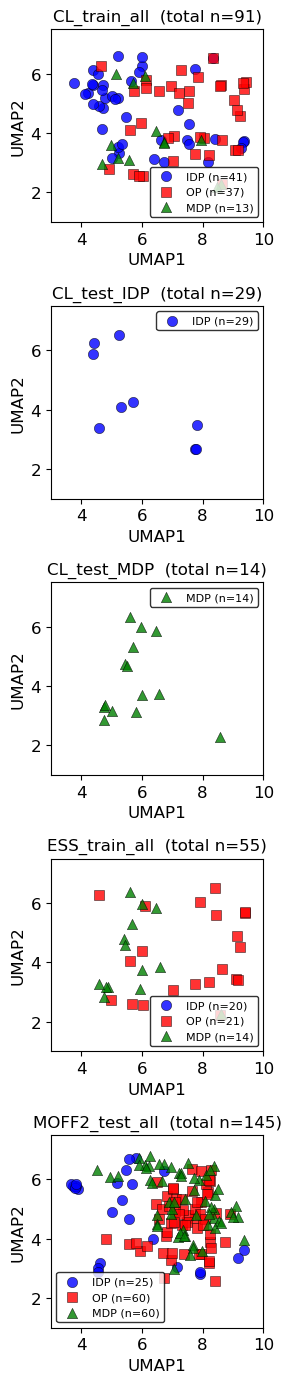


Saved figure to:
./manu_figures/Figure2_AA_comp_allprots.pdf


In [16]:
#!/usr/bin/env python3
import os
import glob
import random
import pickle
import numpy as np
import matplotlib.pyplot as plt
from collections import Counter
import umap

from mpl_toolkits.axes_grid1.inset_locator import inset_axes, mark_inset


# ============================================================
# Reproducibility
# ============================================================

SEED = 42

os.environ["PYTHONHASHSEED"] = str(SEED)
random.seed(SEED)
np.random.seed(SEED)


# ============================================================
# Paths
# ============================================================

base_dir = "./protein_classes"
pkl_path = './results/'
savepath='./manu_figures/'
umap_cache = os.path.join(pkl_path, "AA_comp_umap_fixed_embeddings.pkl")

fig_out = os.path.join(savepath, "Figure2_AA_comp_allprots.pdf")


# ============================================================
# Amino acids
# ============================================================

aa_list = [
    "ALA", "ARG", "ASN", "ASP", "CYS",
    "GLN", "GLU", "GLY", "HIS", "ILE",
    "LEU", "LYS", "MET", "PHE", "PRO",
    "SER", "THR", "TRP", "TYR", "VAL"
]


# ============================================================
# Parser
# ============================================================

def parse_folder(folder_name):
    parts = folder_name.split("_")
    dset = parts[0]
    cls = parts[1].upper()
    split = "_".join(parts[2:])
    return dset, cls, split


# ============================================================
# Read residues from CA-only PDB
# ============================================================

def read_residues(pdb):
    residues = []

    with open(pdb) as f:
        for line in f:
            if line.startswith("ATOM"):
                if line[13:15].strip() == "CA":
                    res = line[17:20].strip()
                    if res in aa_list:
                        residues.append(res)

    return residues


def residues_to_key(res):
    return "-".join(res)


# ============================================================
# Panels
# ============================================================

panel_names = [
    "CL_train_all",
    "CL_test_IDP",
    "CL_test_MDP",
    "ESS_train_all",
    "MOFF2_test_all"
]

panels = {
    name: {"IDP": [], "OP": [], "MDP": []}
    for name in panel_names
}

panel_seen = {
    name: set()
    for name in panel_names
}


# ============================================================
# Collect data
# ============================================================

subfolders = sorted([
    f for f in os.listdir(base_dir)
    if os.path.isdir(os.path.join(base_dir, f))
])

for sub in subfolders:

    folder_path = os.path.join(base_dir, sub)

    try:
        dset, cls, split = parse_folder(sub)
    except Exception:
        continue

    pdbs = sorted(glob.glob(os.path.join(folder_path, "*_ca.pdb")))

    for pdb in pdbs:

        residues = read_residues(pdb)

        if not residues:
            continue

        key = residues_to_key(residues)

        counter = Counter(residues)
        total = sum(counter.values())

        freq = [
            counter[a] / total
            for a in aa_list
        ]

        # ----------------------------------------------------
        # Assign panels
        # ----------------------------------------------------

        if dset == "CL" and split == "train":
            name = "CL_train_all"

        elif dset == "CL" and split == "test_reweight" and cls == "IDP":
            name = "CL_test_IDP"

        elif dset == "CL" and split == "test_md" and cls == "IDP":
            name = "CL_test_IDP"

        elif dset == "CL" and split == "test" and cls == "MDP":
            name = "CL_test_MDP"

        elif dset == "ESS" and split == "train":
            name = "ESS_train_all"

        elif dset == "MOFF2" and split == "test":
            name = "MOFF2_test_all"

        else:
            continue

        # Deduplicate within each panel
        if key not in panel_seen[name]:
            panels[name][cls].append(freq)
            panel_seen[name].add(key)


# ============================================================
# Combine for UMAP
# ============================================================

all_data = []
meta = []

for panel in panel_names:
    for cls in ["IDP", "OP", "MDP"]:
        data = panels[panel][cls]

        for d in data:
            all_data.append(d)
            meta.append((panel, cls))

X = np.array(all_data)

print("Total number of unique sequences:", len(X))

for panel in panel_names:
    print(panel)
    for cls in ["IDP", "OP", "MDP"]:
        print(f"  {cls}: {len(panels[panel][cls])}")


# ============================================================
# UMAP: compute once, then reuse forever
# ============================================================

if os.path.exists(umap_cache):

    print(f"\nLoading fixed UMAP embedding from:")
    print(umap_cache)

    with open(umap_cache, "rb") as f:
        cache = pickle.load(f)

    X_umap = cache["X_umap"]
    X_cached = cache["X"]
    meta_cached = cache["meta"]

    # --------------------------------------------------------
    # Safety checks
    # --------------------------------------------------------

    if len(meta_cached) != len(meta):
        raise ValueError(
            "\nCached UMAP has a different number of points.\n"
            "This means the current dataset changed.\n"
            "If this change is intentional, delete the cache file and rerun:\n"
            f"{umap_cache}"
        )

    if not np.allclose(X_cached, X):
        raise ValueError(
            "\nCurrent amino-acid composition matrix differs from cached one.\n"
            "This means the input data or input order changed.\n"
            "If this change is intentional, delete the cache file and rerun:\n"
            f"{umap_cache}"
        )

    if meta_cached != meta:
        raise ValueError(
            "\nCurrent metadata differs from cached metadata.\n"
            "If this change is intentional, delete the cache file and rerun:\n"
            f"{umap_cache}"
        )

else:

    print("\nComputing UMAP for the first time.")
    print("After this, the saved coordinates will be reused for replotting.")

    reducer = umap.UMAP(
        n_neighbors=20,
        min_dist=0.1,
        metric="euclidean",
        random_state=SEED,
        init="spectral"
    )

    X_umap = reducer.fit_transform(X)

    cache = {
        "X_umap": X_umap,
        "X": X,
        "meta": meta,
        "aa_list": aa_list,
        "panel_names": panel_names,
        "seed": SEED,
        "n_neighbors": 20,
        "min_dist": 0.1,
        "metric": "euclidean",
        "init": "spectral"
    }

    with open(umap_cache, "wb") as f:
        pickle.dump(cache, f)

    print(f"Saved fixed UMAP embedding to:")
    print(umap_cache)


# ============================================================
# Plot settings
# ============================================================

colors = {
    "IDP": "blue",
    "OP": "red",
    "MDP": "green"
}

markers = {
    "IDP": "o",
    "OP": "s",
    "MDP": "^"
}


# ============================================================
# Global axis limits
# ============================================================

pad = 0.8

x_min = X_umap[:, 0].min() - pad
x_max = X_umap[:, 0].max() + pad
y_min = X_umap[:, 1].min() - pad
y_max = X_umap[:, 1].max() + pad


# ============================================================
# Zoom-in setting for first panel
# ============================================================

zoom_panel = "pc_train_all"

# Adjust these manually after seeing the figure.
# These are only examples.
zoom_xlim = (-4, 4)
zoom_ylim = (-3, 3)


# ============================================================
# Plot
# ============================================================

fig, axes = plt.subplots(
    5,
    1,
    figsize=(3., 14),
    sharey=True
)

for ax, panel in zip(axes, panel_names):

    total_n = 0

    for cls in ["IDP", "OP", "MDP"]:

        idx = [
            i for i, (p, c) in enumerate(meta)
            if p == panel and c == cls
        ]

        n_cls = len(idx)
        total_n += n_cls

        if n_cls == 0:
            continue

        ax.scatter(
            X_umap[idx, 0],
            X_umap[idx, 1],
            color=colors[cls],
            marker=markers[cls],
            edgecolors="black",
            linewidths=0.4,
            s=55,
            alpha=0.8,
            label=f"{cls} (n={n_cls})"
        )

    ax.set_title(
        f"{panel}  (total n={total_n})",
        fontsize=12
    )

    ax.legend(
        loc="best",
        fontsize=8,
        frameon=True,
        edgecolor="black"
    )

    #ax.set_xlim(x_min, x_max)
    #ax.set_ylim(y_min, y_max)

    ax.set_xlim(3, 10)
    ax.set_ylim(1, 7.5)

    ax.set_xlabel("UMAP1")
    ax.set_ylabel("UMAP2")



plt.tight_layout()

plt.savefig(fig_out, dpi=300, bbox_inches="tight")
plt.show()

print(f"\nSaved figure to:")
print(fig_out)

Loaded fixed UMAP embedding from:
./manu_figures/AA_comp_umap_fixed_embeddings.pkl
Number of points: 334
UMAP parameters:
  seed: 42
  n_neighbors: 20
  min_dist: 0.1
  metric: euclidean
  init: spectral


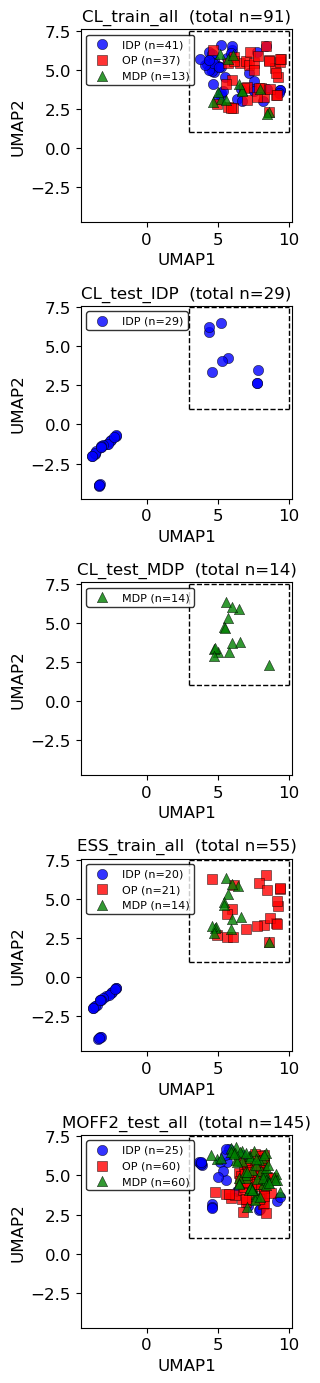

Saved replot to:
./manu_figures/Figure2_all_AA_fixed_umap.pdf


In [20]:
#!/usr/bin/env python3

import os
import pickle
import numpy as np
import matplotlib.pyplot as plt

from mpl_toolkits.axes_grid1.inset_locator import inset_axes, mark_inset


# ============================================================
# Paths
# ============================================================


umap_cache = os.path.join(savepath, "AA_comp_umap_fixed_embeddings.pkl")

fig_out = os.path.join(
    savepath,
    "Figure2_all_AA_fixed_umap.pdf"
)


# ============================================================
# Load fixed UMAP embedding
# ============================================================

with open(umap_cache, "rb") as f:
    cache = pickle.load(f)

X_umap = cache["X_umap"]
X = cache["X"]
meta = cache["meta"]
aa_list = cache["aa_list"]
panel_names = cache["panel_names"]

print("Loaded fixed UMAP embedding from:")
print(umap_cache)

print("Number of points:", len(X_umap))
print("UMAP parameters:")
print("  seed:", cache.get("seed"))
print("  n_neighbors:", cache.get("n_neighbors"))
print("  min_dist:", cache.get("min_dist"))
print("  metric:", cache.get("metric"))
print("  init:", cache.get("init"))


# ============================================================
# Plot settings
# ============================================================

colors = {
    "IDP": "blue",
    "OP": "red",
    "MDP": "green"
}

markers = {
    "IDP": "o",
    "OP": "s",
    "MDP": "^"
}


# ============================================================
# Global axis limits
# ============================================================

pad = 0.8

x_min = X_umap[:, 0].min() - pad
x_max = X_umap[:, 0].max() + pad
y_min = X_umap[:, 1].min() - pad
y_max = X_umap[:, 1].max() + pad


# ============================================================
# Zoom-in setting
# ============================================================

zoom_panel = "CL_train_all"

# Adjust these after checking the full plot
zoom_xlim = (-4, 4)
zoom_ylim = (-3, 3)


# ============================================================
# Plot
# ============================================================

fig, axes = plt.subplots(
    5,
    1,
    figsize=(3.25, 14),
    #sharex=True,
    sharey=True
)

for ax, panel in zip(axes, panel_names):

    total_n = 0

    for cls in ["IDP", "OP", "MDP"]:

        idx = [
            i for i, (p, c) in enumerate(meta)
            if p == panel and c == cls
        ]

        n_cls = len(idx)
        total_n += n_cls

        if n_cls == 0:
            continue

        ax.scatter(
            X_umap[idx, 0],
            X_umap[idx, 1],
            color=colors[cls],
            marker=markers[cls],
            edgecolors="black",
            linewidths=0.4,
            s=55,
            alpha=0.8,
            label=f"{cls} (n={n_cls})"
        )

    # ax.axvline(3, color="black", linestyle="--", linewidth=1.0)
    # ax.axvline(10, color="black", linestyle="--", linewidth=1.0)

    # ax.axhline(1, color="black", linestyle="--", linewidth=1.0)
    # ax.axhline(7.5, color="black", linestyle="--", linewidth=1.0)
    #ax.vlines(3,  ymin=1, ymax=7.5, color="black", linestyle="--", linewidth=1.0)
    #ax.vlines(10, ymin=1, ymax=7.5, color="black", linestyle="--", linewidth=1.0)
    zoom_xlim = (3, 10)
    zoom_ylim = (1, 7.5)
    
    # left and right sides
    ax.vlines(
        zoom_xlim,
        ymin=zoom_ylim[0],
        ymax=zoom_ylim[1],
        color="black",
        linestyle="--",
        linewidth=1.0
    )
    
    # bottom and top sides
    ax.hlines(
        zoom_ylim,
        xmin=zoom_xlim[0],
        xmax=zoom_xlim[1],
        color="black",
        linestyle="--",
        linewidth=1.0
    )



    ax.set_title(
        f"{panel}  (total n={total_n})",
        fontsize=12
    )

    ax.legend(
        loc="best",
        fontsize=8,
        frameon=True,
        edgecolor="black"
    )

    ax.set_xlim(x_min, x_max)
    ax.set_ylim(y_min, y_max)

    ax.set_xlabel("UMAP1")
    ax.set_ylabel("UMAP2")


plt.tight_layout()

plt.savefig(fig_out, dpi=300, bbox_inches="tight")
plt.show()

print("Saved replot to:")
print(fig_out)

### MOFF2-pc Training and MOFF2 validation results


Collected data sizes
IDP: (41, 7)
OP : (37, 7)
MDP: (13, 7)

Length availability
IDP missing length: 0 / 41
OP  missing length: 0 / 37
MDP missing length: 0 / 13

Example json keys for CL / IDP: ACTR
dict_keys(['protein', 'T0', 'T1', 'ionic_strength', 'rg_mean'])

Example json keys for CL / OP: BPTI
dict_keys(['protein', 'T0', 'T1', 'ionic_strength', 'rg_mean'])

Example json keys for CL / MDP: THB-C2
dict_keys(['protein', 'T0', 'T1', 'ionic_strength', 'rg_mean'])


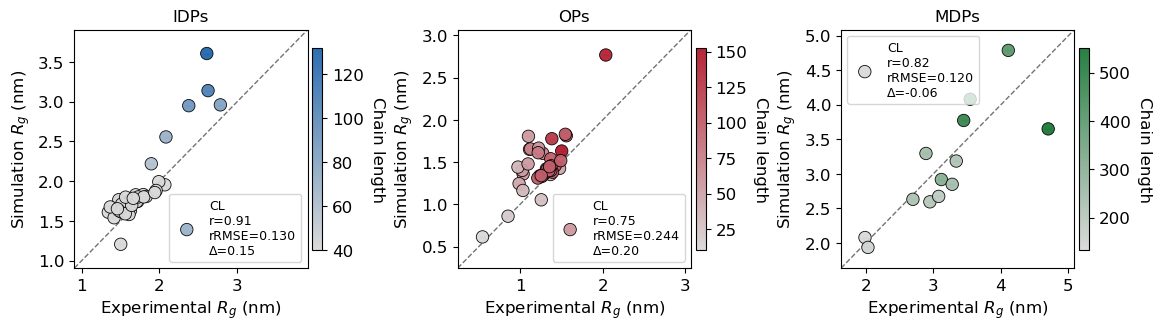

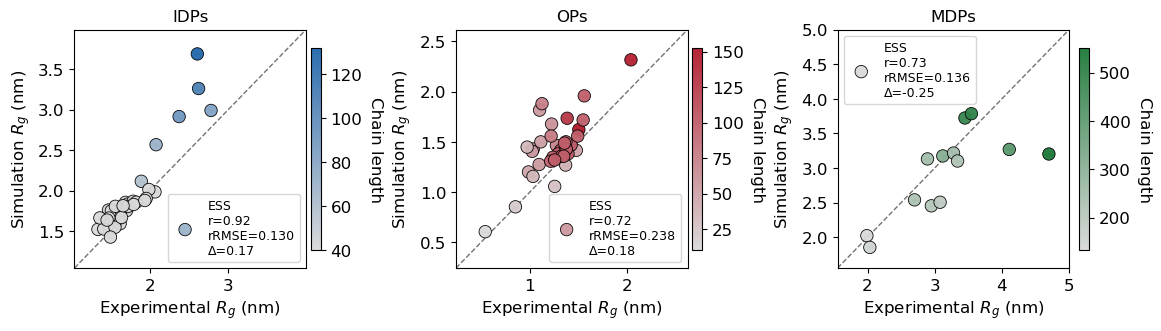

In [20]:
#!/usr/bin/env python3
from matplotlib.colors import LinearSegmentedColormap
import numpy as np
import pandas as pd
import glob
import warnings
warnings.filterwarnings("ignore")

import json
import os
import matplotlib.pyplot as plt

from scipy.stats import pearsonr


# =====================================================
# PATHS
# =====================================================

path = "./"
results_path='./results/'
savepath='./manu_figures/'

pre_result = (
    path
    + "MOFF2-pc"
)

results_main_dir1 = path + "MOFF2"



# =====================================================
# DATASETS
# =====================================================

robustelli2018developing_IDPs = [
    "ACTR",
    "Abeta40",
    "Ash1",
    "NTail",
    "drkN-SH3",
    "p15PAF",
    "sic1",
]

Evo_IDP_indices = (
    list(range(1, 11))
    + [12, 14, 16]
    + list(range(18, 27))
    + [30, 31, 33, 34, 38, 41, 42, 46, 47, 48, 51, 52]
)

Evo_IDPs = [f"Evo{i}" for i in Evo_IDP_indices]

a1_IDPs = [
    "A1-LCD+4D",
    "A1-LCD+12E",
    "A1-LCD+7R",
    "A1-LCD+7F-7Y",
    "A1-LCD+7R+10D",
    "A1-LCD+NLS",
    "A1-LCD-10R",
    "A1-LCD+12D",
    "A1-LCD-8F+4Y",
    "A1-LCD-9F+3Y",
    "A1-LCD+8D",
    "A1-LCD+7K+12D",
    "A1-LCD-10R+10K",
    "A1-LCD-NLS",
    "A1-LCD-9F+6Y",
    "A1-LCD-10G+10S",
    "A1-LCD+2R",
    "A1-LCD-6R",
    "A1-LCD-6R+6K",
    "A1-LCD-4D",
    "A1-LCD-12F+12Y",
    "A1-LCD-3R+3K",
    "A1-LCD+7R+12D",
    "A1-LCD-2K",
]

training_IDPs = robustelli2018developing_IDPs + Evo_IDPs
# training_IDPs = robustelli2018developing_IDPs + Evo_IDPs + a1_IDPs

training_OPs = [
    "BPTI",
    "Chignolin",
    "GB3",
    "Hen-Egg-White-Lysozyme",
    "Homeodomain",
    "NTL9",
    "Protein-B",
    "Protein-G",
    "Trp-cage",
    "Ubiquitin",
    "Villin",
    "WW-domain",
    "alpha3d",
    "bba",
    "bbl",
    "calmodulin",
    "engrailed",
    "gpw",
    "lambda-repressor",
    "1soy_clean",
    "1wla_clean",
    "2ea9_clean",
    "5tvz_clean",
    "AF-P0C232-F1-model_v4_w_H",
    "AF-P0CG98-F1-model_v4_w_H",
    "AF-P00251-F1-model_v4_w_H",
    "AF-P21149-F1-model_v4_w_H",
    "AF-P21318-F1-model_v4_w_H",
    "AF-P29669-F1-model_v4_w_H",
    "AF-P31960-F1-model_v4_w_H",
    "AF-P32729-F1-model_v4_w_H",
    "AF-P61734-F1-model_v4_w_H",
    "AF-P69995-F1-model_v4_w_H",
    "AF-P75202-F1-model_v4_w_H",
    "AF-P75459-F1-model_v4_w_H",
    "AF-P80353-F1-model_v4_w_H",
    "AF-P87285-F1-model_v4_w_H",
]

MDPs = [
    "THB-C2",
    "Ub2",
    "Ub3",
    "Gal3",
    "hnRNPA1-star",
    "FPs-GS8",
    "FPs-GS16",
    "SH4UD-SH3-SH2",
    "TDP43_WtoA",
    "D12",
    "D23",
    "D34",
    "SMAD4",
]


# =====================================================
# EXP DATA
# =====================================================

ca_data_main_dir = (
    "./data"
)

df_lindorff2011fast_rg = pd.read_csv(
    f"{ca_data_main_dir}/"
    "lindorff2011fast_data_rg.csv"
)

df_piana2020development_rg = pd.read_csv(
    f"{ca_data_main_dir}/"
    "piana2020development_data_rg.csv"
)

df_robustelli2018developing_IDP_rg = pd.read_csv(
    f"{ca_data_main_dir}/"
    "robustelli2018developing_IDP_data_rg.csv"
)

df_robustelli2018developing_OP_rg = pd.read_csv(
    f"{ca_data_main_dir}/"
    "robustelli2018developing_OP_data_rg.csv"
)

df_ext_OP_rg = pd.read_csv(
    f"{ca_data_main_dir}/"
    "extended_OP_data_rg.csv"
)

df_Evo_rg = pd.read_csv(
    f"{ca_data_main_dir}/"
    "Evo_data_rg.csv"
)

df_a1_rg = pd.read_csv(
    f"{ca_data_main_dir}/"
    "exp_plus_sim_a1_ref_12F12Y_7Y7F_7K7D.csv"
)

df_data_OP_rg = pd.concat(
    [
        df_lindorff2011fast_rg,
        df_piana2020development_rg,
        df_robustelli2018developing_OP_rg,
        df_ext_OP_rg,
    ],
    ignore_index=True,
)

df_data_IDP_rg = pd.concat(
    [
        df_robustelli2018developing_IDP_rg,
        df_Evo_rg,
        df_a1_rg,
    ],
    ignore_index=True,
)

df_data_OP_rg = df_data_OP_rg.set_index("protein")
df_data_IDP_rg = df_data_IDP_rg.set_index("protein")

df_data_MDP_rg = pd.read_csv(
    "./protein_classes/CL_mdp_train/"
    "MDP_parameters.csv"
).set_index("name")


# =====================================================
# UTILITIES
# =====================================================

def read_rg(directory):
    """
    Read Rg mean and error bar from reweight_rg.json.

    Returns
    -------
    rg_mean : float or None
    rg_err  : float or None
    """

    json_file = f"{directory}/reweight_rg.json"

    if not os.path.exists(json_file):
        return None, None

    with open(json_file, "r") as f:
        data = json.load(f)

    rg_mean = data.get("rg_mean", None)

    # -------------------------------------------------
    # Try common possible error-bar keys.
    # Add your real key here if needed.
    # -------------------------------------------------
    possible_err_keys = [
        "rg_sem",
        "rg_std",
        "rg_err",
        "rg_error",
        "rg_mean_std",
        "rg_mean_sem",
        "rg_std_bootstrap",
        "rg_sem_bootstrap",
    ]

    rg_err = None

    for key in possible_err_keys:
        if key in data:
            rg_err = data[key]
            break

    return rg_mean, rg_err


def get_chain_length_from_pdb(directory):
    """
    Read chain length from the first PDB file in a directory.

    Counts unique residues from ATOM records using:
        chain ID + residue number + insertion code

    This avoids relying on dataframe length columns.
    """

    pdb_files = glob.glob(f"{directory}/*.pdb")

    if len(pdb_files) == 0:
        return np.nan

    # Use first PDB file.
    # If there are multiple PDBs, you can modify this sorting rule.
    pdb_file = sorted(pdb_files)[0]

    residues = set()

    with open(pdb_file, "r") as f:
        for line in f:

            if not line.startswith("ATOM"):
                continue

            chain_id = line[21].strip()
            res_id = line[22:26].strip()
            ins_code = line[26].strip()

            residues.add((chain_id, res_id, ins_code))

    return len(residues)


def print_json_keys_example(df, base_dir, label):
    """
    Diagnostic: print keys from one available reweight_rg.json.
    """

    for p in df["protein"].values:

        json_file = f"{base_dir}/tests3/{p}/reweight_rg.json"

        if os.path.exists(json_file):
            with open(json_file, "r") as f:
                data = json.load(f)

            print("\n================================")
            print(f"Example json keys for {label}: {p}")
            print("================================")
            print(data.keys())
            return

    print(f"No example json found for {label}.")


# =====================================================
# COLLECT DATA
# =====================================================

def collect_rg(protein_list, exp_df, column_name):

    rows = []

    for p in protein_list:

        if p not in exp_df.index:
            continue

        exp_rg = exp_df.loc[p, column_name]

        pre_dir = f"{pre_result}/tests3/{p}"
        ess_dir = f"{results_main_dir1}/tests3/{p}"

        # -------------------------------------------------
        # Read chain length from PDB.
        # First try CL/pre directory, then ESS directory.
        # -------------------------------------------------
        chain_length = get_chain_length_from_pdb(pre_dir)

        if np.isnan(chain_length):
            chain_length = get_chain_length_from_pdb(ess_dir)

        rg_pre, rg_pre_err = read_rg(pre_dir)
        rg_ess, rg_ess_err = read_rg(ess_dir)

        if rg_pre is None and rg_ess is None:
            continue

        rows.append(
            [
                p,
                exp_rg,
                chain_length,
                rg_pre,
                rg_pre_err,
                rg_ess,
                rg_ess_err,
            ]
        )

    return pd.DataFrame(
        rows,
        columns=[
            "protein",
            "Rg_exp",
            "length",
            "Rg_pre",
            "Rg_pre_err",
            "Rg_ess",
            "Rg_ess_err",
        ],
    )


df_IDP = collect_rg(
    training_IDPs,
    df_data_IDP_rg,
    "Rg (nm)",
)

df_OP = collect_rg(
    training_OPs,
    df_data_OP_rg,
    "Rg (nm)",
)

df_MDP = collect_rg(
    MDPs,
    df_data_MDP_rg,
    "Rg (nm)",
)


# =====================================================
# CHECK COLLECTED DATA
# =====================================================

print("\n================================")
print("Collected data sizes")
print("================================")
print("IDP:", df_IDP.shape)
print("OP :", df_OP.shape)
print("MDP:", df_MDP.shape)

print("\n================================")
print("Length availability")
print("================================")
print("IDP missing length:", df_IDP["length"].isna().sum(), "/", len(df_IDP))
print("OP  missing length:", df_OP["length"].isna().sum(), "/", len(df_OP))
print("MDP missing length:", df_MDP["length"].isna().sum(), "/", len(df_MDP))

print_json_keys_example(df_IDP, pre_result, "CL / IDP")
print_json_keys_example(df_OP, pre_result, "CL / OP")
print_json_keys_example(df_MDP, pre_result, "CL / MDP")


# =====================================================
# SAVE COLLECTED TABLES
# =====================================================

df_IDP.to_csv(
    os.path.join(results_path, "collected_model_IDP_Rg.csv"),
    index=False,
)

df_OP.to_csv(
    os.path.join(results_path, "collected_model_OP_Rg.csv"),
    index=False,
)

df_MDP.to_csv(
    os.path.join(results_path, "collected_model_MDP_Rg.csv"),
    index=False,
)


# =====================================================
# PLOTTING HELPERS
# =====================================================

def compute_stats(x, y):
    """
    Compute Pearson r, relative RMSE, and mean signed error.
    """

    x = np.asarray(x, dtype=float)
    y = np.asarray(y, dtype=float)

    mask = np.isfinite(x) & np.isfinite(y)

    x = x[mask]
    y = y[mask]

    if len(x) > 1:
        r, _ = pearsonr(x, y)
    else:
        r = np.nan

    if len(x) > 0:
        rrmse = np.sqrt(
            np.mean((x - y) ** 2 / x ** 2)
        )
        delta = np.mean(y - x)
    else:
        rrmse = np.nan
        delta = np.nan

    return r, rrmse, delta


def get_global_length_range(dfs):
    """
    Shared color scale across IDP, OP, and MDP.
    """

    all_lengths = []

    for df in dfs:

        vals = df["length"].to_numpy(dtype=float)
        vals = vals[np.isfinite(vals)]

        all_lengths.extend(vals)

    if len(all_lengths) == 0:
        return None, None

    return np.min(all_lengths), np.max(all_lengths)



def draw_panel(
    ax,
    df,
    title,
    mode="CL",
    vmin=None,
    vmax=None,
    cmap="viridis",
    size=80,
):

    if mode == "CL":
        rg_col = "Rg_pre"
        err_col = "Rg_pre_err"
        marker = "s"
        label_name = "CL"

    elif mode == "ESS":
        rg_col = "Rg_ess"
        err_col = "Rg_ess_err"
        marker = "o"
        label_name = "ESS"

    else:
        raise ValueError("mode must be either 'CL' or 'ESS'")

    # -------------------------------------------------
    # Select data
    # -------------------------------------------------
    mask = df[rg_col].notna()

    x = df.loc[mask, "Rg_exp"].to_numpy(dtype=float)
    y = df.loc[mask, rg_col].to_numpy(dtype=float)
    yerr = df.loc[mask, err_col].to_numpy(dtype=float)
    length = df.loc[mask, "length"].to_numpy(dtype=float)

    yerr = np.nan_to_num(yerr, nan=0.0)

    r, rrmse, delta = compute_stats(x, y)

    # -------------------------------------------------
    # Error bars
    # -------------------------------------------------
    ax.errorbar(
        x,
        y,
        yerr=yerr,
        fmt="none",
        ecolor="gray",
        elinewidth=1.0,
        capsize=2.5,
        alpha=0.7,
        zorder=1,
    )

    # -------------------------------------------------
    # Scatter
    # -------------------------------------------------
    sc = ax.scatter(
        x,
        y,
        s=size,
        marker='o',
        c=length,
        cmap=cmap,
        vmin=vmin,
        vmax=vmax,
        edgecolors="black",
        linewidths=0.6,
        alpha=0.9,
        zorder=2,
        label=(
            f"{label_name}\n"
            f"r={r:.2f}\n"
            f"rRMSE={rrmse:.3f}\n"
            f"Δ={delta:.2f}"
        ),
    )

    # -------------------------------------------------
    # Diagonal line and axis limits
    # -------------------------------------------------
    vals = []

    for col in ["Rg_exp", rg_col]:
        arr = df[col].to_numpy(dtype=float)
        arr = arr[np.isfinite(arr)]
        vals.extend(arr)

    lo = np.min(vals) - 0.3
    hi = np.max(vals) + 0.3

    ax.plot(
        [lo, hi],
        [lo, hi],
        "--",
        color="gray",
        linewidth=1.0,
        zorder=0,
    )

    ax.set_xlim(lo, hi)
    ax.set_ylim(lo, hi)

    ax.set_title(title)
    ax.set_xlabel("Experimental $R_g$ (nm)")
    ax.set_ylabel("Simulation $R_g$ (nm)")

    ax.legend(
        fontsize=9,
        frameon=True,
        loc="best",
    )

    return sc

# =====================================================
# PLOTTING HELPERS
# =====================================================

from matplotlib.colors import LinearSegmentedColormap


# -----------------------------------------------------
# Class-specific colormaps
# low chain length = light grey
# high chain length = class color
# -----------------------------------------------------

light_grey = "#d9d9d9"

cmap_IDP = LinearSegmentedColormap.from_list(
    "IDP_lightgrey_to_blue",
    [light_grey, "#2166ac"]   # nice deep blue
)

cmap_OP = LinearSegmentedColormap.from_list(
    "OP_lightgrey_to_red",
    [light_grey, "#b2182b"]   # nice deep red
)

cmap_MDP = LinearSegmentedColormap.from_list(
    "MDP_lightgrey_to_green",
    [light_grey, "#1b7837"]   # nice deep green
)


def compute_stats(x, y):
    """
    Compute Pearson r, relative RMSE, and mean signed error.
    """

    x = np.asarray(x, dtype=float)
    y = np.asarray(y, dtype=float)

    mask = np.isfinite(x) & np.isfinite(y)

    x = x[mask]
    y = y[mask]

    if len(x) > 1:
        r, _ = pearsonr(x, y)
    else:
        r = np.nan

    if len(x) > 0:
        rrmse = np.sqrt(
            np.mean((x - y) ** 2 / x ** 2)
        )
        delta = np.mean(y - x)
    else:
        rrmse = np.nan
        delta = np.nan

    return r, rrmse, delta


def draw_panel(
    ax,
    df,
    title,
    mode="CL",
    vmin=None,
    vmax=None,
    cmap=None,
    size=80,
):

    if mode == "CL":
        rg_col = "Rg_pre"
        err_col = "Rg_pre_err"
        label_name = "CL"

    elif mode == "ESS":
        rg_col = "Rg_ess"
        err_col = "Rg_ess_err"
        label_name = "ESS"

    else:
        raise ValueError("mode must be either 'CL' or 'ESS'")

    # -------------------------------------------------
    # Select data
    # -------------------------------------------------
    mask = df[rg_col].notna()

    x = df.loc[mask, "Rg_exp"].to_numpy(dtype=float)
    y = df.loc[mask, rg_col].to_numpy(dtype=float)
    yerr = df.loc[mask, err_col].to_numpy(dtype=float)
    length = df.loc[mask, "length"].to_numpy(dtype=float)

    yerr = np.nan_to_num(yerr, nan=0.0)

    r, rrmse, delta = compute_stats(x, y)

    # -------------------------------------------------
    # Error bars
    # -------------------------------------------------
    ax.errorbar(
        x,
        y,
        yerr=yerr,
        fmt="none",
        ecolor="0.55",
        elinewidth=1.0,
        capsize=2.5,
        alpha=0.7,
        zorder=1,
    )

    # -------------------------------------------------
    # Scatter, colored by chain length
    # -------------------------------------------------
    sc = ax.scatter(
        x,
        y,
        s=size,
        marker="o",
        c=length,
        cmap=cmap,
        vmin=vmin,
        vmax=vmax,
        edgecolors="black",
        linewidths=0.6,
        alpha=0.95,
        zorder=2,
        label=(
            f"{label_name}\n"
            f"r={r:.2f}\n"
            f"rRMSE={rrmse:.3f}\n"
            f"Δ={delta:.2f}"
        ),
    )

    # -------------------------------------------------
    # Diagonal line and axis limits
    # -------------------------------------------------
    vals = []

    for col in ["Rg_exp", rg_col]:
        arr = df[col].to_numpy(dtype=float)
        arr = arr[np.isfinite(arr)]
        vals.extend(arr)

    lo = np.min(vals) - 0.3
    hi = np.max(vals) + 0.3

    ax.plot(
        [lo, hi],
        [lo, hi],
        "--",
        color="0.45",
        linewidth=1.0,
        zorder=0,
    )

    ax.set_xlim(lo, hi)
    ax.set_ylim(lo, hi)

    ax.set_title(title)
    ax.set_xlabel("Experimental $R_g$ (nm)")
    ax.set_ylabel("Simulation $R_g$ (nm)")

    ax.legend(
        fontsize=9,
        frameon=True,
        loc="best",
    )

    return sc


# =====================================================
# COLOR RANGES
# Each class uses its own chain-length color scale
# =====================================================

vmin_IDP, vmax_IDP = df_IDP["length"].min(), df_IDP["length"].max()
vmin_OP,  vmax_OP  = df_OP["length"].min(),  df_OP["length"].max()
vmin_MDP, vmax_MDP = df_MDP["length"].min(), df_MDP["length"].max()


# =====================================================
# PLOT 1: CL ONLY, COLORED BY CHAIN LENGTH
# IDP: light grey -> blue
# OP : light grey -> red
# MDP: light grey -> green
# =====================================================

fig, axes = plt.subplots(
    1,
    3,
    figsize=(11.5, 3.2),
    constrained_layout=True,
)

sc0 = draw_panel(
    axes[0],
    df_IDP,
    "IDPs",
    mode="CL",
    vmin=vmin_IDP,
    vmax=vmax_IDP,
    cmap=cmap_IDP,
)

sc1 = draw_panel(
    axes[1],
    df_OP,
    "OPs",
    mode="CL",
    vmin=vmin_OP,
    vmax=vmax_OP,
    cmap=cmap_OP,
)

sc2 = draw_panel(
    axes[2],
    df_MDP,
    "MDPs",
    mode="CL",
    vmin=vmin_MDP,
    vmax=vmax_MDP,
    cmap=cmap_MDP,
)

for ax, sc in zip(axes, [sc0, sc1, sc2]):

    cbar = fig.colorbar(
        sc,
        ax=ax,
        shrink=0.85,
        pad=0.02,
    )

    cbar.set_label(
        "Chain length",
        rotation=270,
        labelpad=15,
    )

plt.savefig(
    os.path.join(
        savepath,
        "Figure2A_CL_training.pdf",
    ),
    dpi=300,
    bbox_inches="tight",
)

plt.savefig(
    os.path.join(
        savepath,
        "Figure2A_PC_training.png",
    ),
    dpi=300,
    bbox_inches="tight",
)

plt.show()


# =====================================================
# PLOT 2: ESS ONLY, COLORED BY CHAIN LENGTH
# IDP: light grey -> blue
# OP : light grey -> red
# MDP: light grey -> green
# =====================================================

fig, axes = plt.subplots(
    1,
    3,
    figsize=(11.5, 3.2),
    constrained_layout=True,
)

sc0 = draw_panel(
    axes[0],
    df_IDP,
    "IDPs",
    mode="ESS",
    vmin=vmin_IDP,
    vmax=vmax_IDP,
    cmap=cmap_IDP,
)

sc1 = draw_panel(
    axes[1],
    df_OP,
    "OPs",
    mode="ESS",
    vmin=vmin_OP,
    vmax=vmax_OP,
    cmap=cmap_OP,
)

sc2 = draw_panel(
    axes[2],
    df_MDP,
    "MDPs",
    mode="ESS",
    vmin=vmin_MDP,
    vmax=vmax_MDP,
    cmap=cmap_MDP,
)

for ax, sc in zip(axes, [sc0, sc1, sc2]):

    cbar = fig.colorbar(
        sc,
        ax=ax,
        shrink=0.85,
        pad=0.02,
    )

    cbar.set_label(
        "Chain length",
        rotation=270,
        labelpad=15,
    )

plt.savefig(
    os.path.join(
        savepath,
        "FigureS3_ESS_validation.pdf",
    ),
    dpi=300,
    bbox_inches="tight",
)

plt.savefig(
    os.path.join(
        savepath,
        "FigureS3_ESS_validation.png",
    ),
    dpi=300,
    bbox_inches="tight",
)

plt.show()

### MOFF2-pc Testing results (Figure S3)

int64
[24 48 99 38 46]


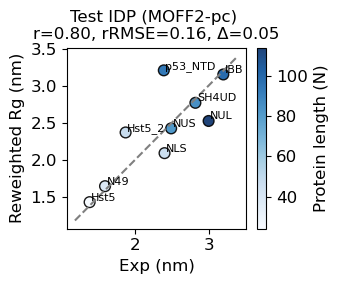

In [18]:
import numpy as np
import pandas as pd
import glob
import warnings
warnings.filterwarnings('ignore')
import argparse
import pickle
import json
import sys
import os
import matplotlib.pyplot as plt
import matplotlib as mpl
from matplotlib.backends.backend_pdf import PdfPages
import seaborn as sns
from scipy.stats import pearsonr

path='./'

results_main_dir=path+"MOFF2/"

test_IDPs = ['Hst5', 'Hst5_2', 'IBB', 'N49', 'NLS', 'NUL', 'NUS', 
             'SH4UD', 'p53_NTD'] 



# set all the training set data
ca_data_main_dir = './data/'

df_exp_IDP_rg = pd.read_csv(f'{ca_data_main_dir}/rg_experimental_data.csv')
df_exp_IDP_rg = df_exp_IDP_rg.set_index('name')






# ==============================
# Helper: get length from CA PDB
# ==============================
def get_length_from_ca_pdb(pdb_path):
    residues = set()
    if not os.path.exists(pdb_path):
        return np.nan

    with open(pdb_path) as f:
        for line in f:
            if line.startswith("ATOM") and line[12:16].strip() == "CA":
                res_id = (line[21], line[22:26].strip())
                residues.add(res_id)

    return len(residues)


# ==============================
# Compare IDP test sets
# ==============================
df_test_set_IDP_rg = pd.DataFrame(columns=[
    'protein', 'Rg_exp', 'Rg_reweight',
    'length'
])

for each_IDP in test_IDPs:
    # if each_IDP in exclusions:
    #     print(f'Skip {each_IDP}')
    #     continue

    each_dir = f'{results_main_dir}/tests3/{each_IDP}'

    # ---- load reweight ----
    reweight_json = f'{each_dir}/reweight_rg.json'
    if not os.path.exists(reweight_json):
        continue

    with open(reweight_json, 'r') as f:
        reweight_dict = json.load(f)

    rg_reweight = reweight_dict['rg_mean']

    # ---- get length from pdb ----
    pdb_path = f'./protein_classes/CL_idp_test_reweight/{each_IDP}_ca.pdb'
    length = get_length_from_ca_pdb(pdb_path)

    # ---- build row ----
    row = [
        each_IDP,
        df_exp_IDP_rg.loc[each_IDP, 'Rg (nm)'],
        rg_reweight,
        length
    ]

    df_test_set_IDP_rg.loc[len(df_test_set_IDP_rg.index)] = row


# ==============================
# Plotting
# ==============================
import matplotlib.pyplot as plt
import numpy as np
from scipy.stats import pearsonr

alpha = 0.9
s = 60

x = df_test_set_IDP_rg['Rg_exp'].to_numpy()
y = df_test_set_IDP_rg['Rg_reweight'].to_numpy()
lengths = df_test_set_IDP_rg['length'].to_numpy()

print(lengths.dtype)
print(lengths[:5])
# ---- metrics ----
r, _ = pearsonr(x, y)
rRMSE = np.sqrt(np.mean((x - y)**2 / x**2))
delta = np.mean(y - x)

# ---- figure ----
plt.figure(figsize=(3.5, 3.))


# scatter with color = length
sc = plt.scatter(
    x, y,
    c=lengths,
    cmap='Blues',
    s=s,
    alpha=alpha,
    edgecolors='black'
)

# diagonal
plt.plot(
    [x.min()-0.2, x.max()+0.2],
    [x.min()-0.2, x.max()+0.2],
    '--', color='gray'
)

# ---- labels ----
for _, row in df_test_set_IDP_rg.iterrows():
    plt.text(
        row['Rg_exp'] + 0.02,
        row['Rg_reweight'] + 0.02,
        row['protein'],
        fontsize=8
    )

# ---- colorbar ----
cbar = plt.colorbar(sc)
cbar.set_label('Protein length (N)')

# ---- titles ----
plt.title(f'Test IDP (MOFF2-pc) \nr={r:.2f}, rRMSE={rRMSE:.2f}, Δ={delta:.2f}')
plt.xlabel('Exp (nm)')
plt.ylabel('Reweighted Rg (nm)')

plt.tight_layout()
plt.savefig(savepath+'FigureS3.MOFF2-pc-testing-IDP.pdf')
plt.show()





### A1-LCD for MOFF2-pc and MOFF2

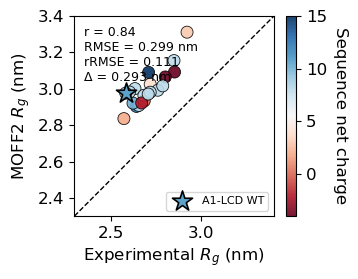

In [81]:
#!/usr/bin/env python3
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import TwoSlopeNorm

# ─────────────────────────────────────────────
# CONFIG
# ─────────────────────────────────────────────

path = './results/'
savepath = './manu_figures/'
os.makedirs(savepath, exist_ok=True)

df = pd.read_csv(path + "MOFF2_rg_A1_lcd.csv")

# =====================================================
# Metrics
# =====================================================

x = df["exp"].to_numpy(dtype=float)
y = df["MOFF2-pc"].to_numpy(dtype=float)

rmse = np.sqrt(np.mean((y - x) ** 2))
rrmse = np.sqrt(np.mean((x - y)**2 / x**2))
corr = np.corrcoef(x, y)[0, 1]
delta = np.mean(y - x)

# =====================================================
# Plot: Experimental vs MOFF2, colored by net charge
# negative = red, positive = blue
# =====================================================

fig, ax = plt.subplots(figsize=(3.7, 2.95))

cmap_charge = plt.get_cmap("RdBu")
# max_abs_charge = np.nanmax(np.abs(df["seq_charge"]))
norm = TwoSlopeNorm(
    vmin=-5,
    vcenter=0.0,
    vmax=15
)

sc = ax.scatter(
    df["exp"],
    df["MOFF2-pc"],
    c=df["seq_charge"],
    cmap=cmap_charge,
    #norm=norm,
    s=75,
    edgecolors="black",
    linewidths=0.6,
    alpha=0.9,
)

# highlight WT
wt_row = df[df["protein"] == "A1-LCD+NLS"]

if not wt_row.empty:
    wt_charge = float(wt_row["seq_charge"].iloc[0])
    wt_color = cmap_charge(norm(wt_charge))

    ax.scatter(
        wt_row["exp"],
        wt_row["MOFF2-pc"],
        marker="*",
        s=230,
        c=[wt_color],
        edgecolors="black",
        linewidths=1.2,
        zorder=5,
        label="A1-LCD WT",
    )

# 1:1 diagonal line
ax.plot(
    [2.3, 3.4],
    [2.3, 3.4],
    "k--",
    lw=1,
)

ax.set_xlabel("Experimental $R_g$ (nm)")
ax.set_ylabel("MOFF2 $R_g$ (nm)")

# stats text
ax.text(
    0.05,
    0.95,
    f"r = {corr:.2f}\n"
    f"RMSE = {rmse:.3f} nm\n"
    f"rRMSE = {rrmse:.3f}\n"
    f"Δ = {delta:.3f} nm",
    transform=ax.transAxes,
    ha="left",
    va="top",
    fontsize=9,
)

# # optional labels
# for _, row in df.iterrows():
#     ax.text(
#         row["exp"] + 0.004,
#         row["MOFF2"] + 0.004,
#         row["protein"].replace("A1-LCD", ""),
#         fontsize=6.5,
#         alpha=0.8,
#     )

# colorbar
cbar = plt.colorbar(sc, ax=ax)
cbar.set_label("Sequence net charge", rotation=270, labelpad=15)

ax.legend(
    loc="lower right",
    frameon=True,
    fontsize=8,
)

ax.set_xlim(2.3, 3.4)
ax.set_ylim(2.3, 3.4)

plt.tight_layout()
plt.savefig(savepath + "Figure2_MOFF2-pc_A1_RG.pdf", dpi=300, bbox_inches="tight")
plt.show()

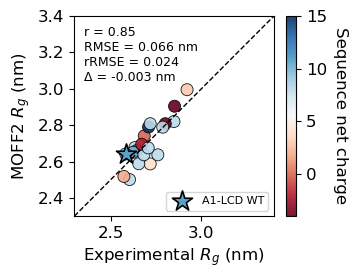

In [80]:
#!/usr/bin/env python3
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import TwoSlopeNorm

# ─────────────────────────────────────────────
# CONFIG
# ─────────────────────────────────────────────

path = './results/'
savepath = './manu_figures/'
os.makedirs(savepath, exist_ok=True)

df = pd.read_csv(path + "MOFF2_rg_A1_lcd.csv")

# =====================================================
# Metrics
# =====================================================

x = df["exp"].to_numpy(dtype=float)
y = df["MOFF2"].to_numpy(dtype=float)

rmse = np.sqrt(np.mean((y - x) ** 2))
#rrmse = rmse / np.mean(x)
rrmse = np.sqrt(np.mean((x - y)**2 / x**2))
corr = np.corrcoef(x, y)[0, 1]
delta = np.mean(y - x)

# =====================================================
# Plot: Experimental vs MOFF2, colored by net charge
# negative = red, positive = blue
# =====================================================

fig, ax = plt.subplots(figsize=(3.7, 2.95))

cmap_charge = plt.get_cmap("RdBu")
# max_abs_charge = np.nanmax(np.abs(df["seq_charge"]))
norm = TwoSlopeNorm(
    vmin=-5,
    vcenter=0.0,
    vmax=15
)

sc = ax.scatter(
    df["exp"],
    df["MOFF2"],
    c=df["seq_charge"],
    cmap=cmap_charge,
    #norm=norm,
    s=75,
    edgecolors="black",
    linewidths=0.6,
    alpha=0.9,
)

# highlight WT
wt_row = df[df["protein"] == "A1-LCD+NLS"]

if not wt_row.empty:
    wt_charge = float(wt_row["seq_charge"].iloc[0])
    wt_color = cmap_charge(norm(wt_charge))

    ax.scatter(
        wt_row["exp"],
        wt_row["MOFF2"],
        marker="*",
        s=230,
        c=[wt_color],
        edgecolors="black",
        linewidths=1.2,
        zorder=5,
        label="A1-LCD WT",
    )

# 1:1 diagonal line
ax.plot(
    [2.3, 3.4],
    [2.3, 3.4],
    "k--",
    lw=1,
)

ax.set_xlabel("Experimental $R_g$ (nm)")
ax.set_ylabel("MOFF2 $R_g$ (nm)")

# stats text
ax.text(
    0.05,
    0.95,
    f"r = {corr:.2f}\n"
    f"RMSE = {rmse:.3f} nm\n"
    f"rRMSE = {rrmse:.3f}\n"
    f"Δ = {delta:.3f} nm",
    transform=ax.transAxes,
    ha="left",
    va="top",
    fontsize=9,
)

# # optional labels
# for _, row in df.iterrows():
#     ax.text(
#         row["exp"] + 0.004,
#         row["MOFF2"] + 0.004,
#         row["protein"].replace("A1-LCD", ""),
#         fontsize=6.5,
#         alpha=0.8,
#     )

# colorbar
cbar = plt.colorbar(sc, ax=ax)
cbar.set_label("Sequence net charge", rotation=270, labelpad=15)

ax.legend(
    loc="lower right",
    frameon=True,
    fontsize=8,
)

ax.set_xlim(2.3, 3.4)
ax.set_ylim(2.3, 3.4)

plt.tight_layout()
plt.savefig(savepath + "Figure2_MOFF2_A1_RG.pdf", dpi=300, bbox_inches="tight")
plt.show()

## Figure S3

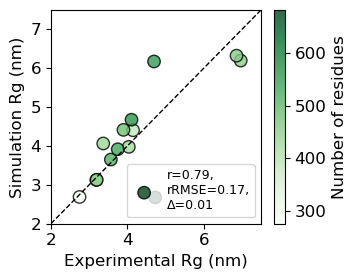

In [15]:
#!/usr/bin/env python3
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import mdtraj as md

# ─────────────────────────────────────────────
# CONFIG
# ─────────────────────────────────────────────
path = './results/'
savepath='./manu_figures/'

df = pd.read_csv(path+'rg_test_mdp_MOFF2_pc_MD.csv')

# ─────────────────────────────────────────────
# PLOT with colorbar for residue count
# ─────────────────────────────────────────────
n_rows = len(results)
n_cols = len(sims)
fig, axes = plt.subplots(n_rows, n_cols, figsize=(3.7*n_cols, 2.95*n_rows), squeeze=False)

for i, result in enumerate(results):
    for j, sim in enumerate(sims):
        ax = axes[i, j]
        subdf = df[(df["result"] == result) & (df["class"] == sim)]
        subdf = subdf[subdf["n_residues"] >= n_res]
        subdf = subdf[subdf["sim_rg_mean"] <= 100]

        if subdf.empty:
            ax.set_title(f"{result}-{sim} (no data)")
            continue

        sc = ax.scatter(
            subdf["ref_rg"], subdf["sim_rg_mean"],
            c=subdf["n_residues"], cmap="Greens", s=80,
            edgecolor="k", alpha=0.8
        )

        # ax.errorbar(
        #     subdf["ref_rg"], subdf["sim_rg_mean"],
        #     yerr=subdf["sim_rg_std"], fmt="none", ecolor="gray", alpha=0.5
        # )
        # ax.errorbar(
        #      subdf["ref_rg"], subdf["sim_rg_mean"],
        #      yerr=subdf["sim_rg_std"], fmt="none", ecolor="gray", alpha=0.5
        # )

        diffs = subdf["sim_rg_mean"].values - subdf["ref_rg"].values
        rmse = np.sqrt(np.mean(diffs**2))
        #rrmse = rmse / np.mean(subdf["ref_rg"].values)
        ref = subdf["ref_rg"].values
        pred = subdf["sim_rg_mean"].values

        rrmse = np.sqrt(np.mean(((pred - ref) / ref) ** 2))
        corr = np.corrcoef(subdf["ref_rg"].values, subdf["sim_rg_mean"].values)[0, 1]

        rg_min = min(subdf["ref_rg"].min(), subdf["sim_rg_mean"].min())
        rg_max = max(subdf["ref_rg"].max(), subdf["sim_rg_mean"].max())
        #ax.plot([rg_min, rg_max], [rg_min, rg_max], "k--", lw=1)
        ax.plot([2, 8.5], [2, 8.5], "k--", lw=1)
        

        #ax.set_xlim(rg_min*0.9, rg_max*1.05)
        #ax.set_ylim(rg_min*0.9, rg_max*1.05)
        ax.set_xlim([2,7.5])
        ax.set_ylim([2,7.5])

        ax.set_xlabel("Experimental Rg (nm)")
        ax.set_ylabel("Simulation Rg (nm)")

        delta = np.mean(subdf["sim_rg_mean"] - subdf["ref_rg"])

        # legend with stats and WT marker
        ax.legend(
            [f"r={corr:.2f},\nrRMSE={rrmse:.2f},\nΔ={delta:.2f}"],
            loc="lower right", frameon=True, fontsize=9
        )



        cbar = plt.colorbar(sc, ax=ax)
        cbar.set_label("Number of residues")

plt.tight_layout()
plt.savefig(savepath+"FigS3.test_MDP_MOFF2-pc_MD.pdf")
plt.show()


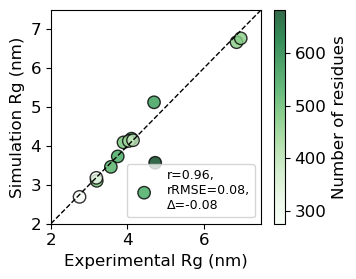

In [14]:
#!/usr/bin/env python3
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import mdtraj as md

# ─────────────────────────────────────────────
# CONFIG
# ─────────────────────────────────────────────
path = './results/'
savepath='./manu_figures/'

df = pd.read_csv(path+'rg_train_mdp_MOFF2_reweight.csv')

# ─────────────────────────────────────────────
# PLOT with colorbar for residue count
# ─────────────────────────────────────────────
n_rows = len(results)
n_cols = len(sims)
fig, axes = plt.subplots(n_rows, n_cols, figsize=(3.7*n_cols, 2.95*n_rows), squeeze=False)

for i, result in enumerate(results):
    for j, sim in enumerate(sims):
        ax = axes[i, j]
        subdf = df

        if subdf.empty:
            ax.set_title(f"{result}-{sim} (no data)")
            continue

        sc = ax.scatter(
            subdf["Rg_exp"], subdf["Rg_sim"],
            c=subdf["chain_length"], cmap="Greens", s=80,
            edgecolor="k", alpha=0.8
        )

        # ax.errorbar(
        #     subdf["ref_rg"], subdf["sim_rg_mean"],
        #     yerr=subdf["sim_rg_std"], fmt="none", ecolor="gray", alpha=0.5
        # )
        # ax.errorbar(
        #      subdf["ref_rg"], subdf["sim_rg_mean"],
        #      yerr=subdf["sim_rg_std"], fmt="none", ecolor="gray", alpha=0.5
        # )

        diffs = subdf["Rg_sim"].values - subdf["Rg_exp"].values
        rmse = np.sqrt(np.mean(diffs**2))
        ref = subdf["Rg_exp"].values
        pred = subdf["Rg_sim"].values

        rrmse = np.sqrt(np.mean(((pred - ref) / ref) ** 2))
        corr = np.corrcoef(subdf["Rg_exp"].values, subdf["Rg_sim"].values)[0, 1]

        rg_min = min(subdf["Rg_exp"].min(), subdf["Rg_sim"].min())
        rg_max = max(subdf["Rg_exp"].max(), subdf["Rg_sim"].max())
        #ax.plot([rg_min, rg_max], [rg_min, rg_max], "k--", lw=1)
        ax.plot([2, 8.5], [2, 8.5], "k--", lw=1)
        

        #ax.set_xlim(rg_min*0.9, rg_max*1.05)
        #ax.set_ylim(rg_min*0.9, rg_max*1.05)
        ax.set_xlim([2,7.5])
        ax.set_ylim([2,7.5])

        ax.set_xlabel("Experimental Rg (nm)")
        ax.set_ylabel("Simulation Rg (nm)")

        delta = np.mean(subdf["Rg_sim"] - subdf["Rg_exp"])

        # legend with stats and WT marker
        ax.legend(
            [f"r={corr:.2f},\nrRMSE={rrmse:.2f},\nΔ={delta:.2f}"],
            loc="lower right", frameon=True, fontsize=9
        )



        cbar = plt.colorbar(sc, ax=ax)
        cbar.set_label("Number of residues")

plt.tight_layout()
plt.savefig(savepath+"FigS3.train_MDP_MOFF2-pc_MD.pdf")
plt.show()


In [8]:
#!/usr/bin/env python3
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import mdtraj as md

# ─────────────────────────────────────────────
# CONFIG
# ─────────────────────────────────────────────
path = './results/'
savepath = './results/'

df = pd.read_csv(path+'rg_test_mdp_MOFF2_pc_reweighted.csv')

# ─────────────────────────────────────────────
# PLOT with colorbar for residue count
# ─────────────────────────────────────────────
n_rows = len(results)
n_cols = len(sims)
fig, axes = plt.subplots(n_rows, n_cols, figsize=(3.7*n_cols, 2.95*n_rows), squeeze=False)

for i, result in enumerate(results):
    for j, sim in enumerate(sims):
        ax = axes[i, j]
        subdf = df[(df["result"] == result) & (df["class"] == sim)]
        subdf = subdf[subdf["n_residues"] >= n_res]
        subdf = subdf[subdf["sim_rg_mean"] <= 100]

        if subdf.empty:
            ax.set_title(f"{result}-{sim} (no data)")
            continue

        sc = ax.scatter(
            subdf["ref_rg"], subdf["sim_rg_mean"],
            c=subdf["n_residues"], cmap="Greens", s=80,
            edgecolor="k", alpha=0.8
        )

        # ax.errorbar(
        #     subdf["ref_rg"], subdf["sim_rg_mean"],
        #     yerr=subdf["sim_rg_std"], fmt="none", ecolor="gray", alpha=0.5
        # )
        # ax.errorbar(
        #      subdf["ref_rg"], subdf["sim_rg_mean"],
        #      yerr=subdf["sim_rg_std"], fmt="none", ecolor="gray", alpha=0.5
        # )

        diffs = subdf["sim_rg_mean"].values - subdf["ref_rg"].values
        rmse = np.sqrt(np.mean(diffs**2))
        rrmse = rmse / np.mean(subdf["ref_rg"].values)
        corr = np.corrcoef(subdf["ref_rg"].values, subdf["sim_rg_mean"].values)[0, 1]

        rg_min = min(subdf["ref_rg"].min(), subdf["sim_rg_mean"].min())
        rg_max = max(subdf["ref_rg"].max(), subdf["sim_rg_mean"].max())
        #ax.plot([rg_min, rg_max], [rg_min, rg_max], "k--", lw=1)
        ax.plot([2, 8.5], [2, 8.5], "k--", lw=1)
        

        #ax.set_xlim(rg_min*0.9, rg_max*1.05)
        #ax.set_ylim(rg_min*0.9, rg_max*1.05)
        ax.set_xlim([2,7.5])
        ax.set_ylim([2,7.5])

        ax.set_xlabel("Experimental Rg (nm)")
        ax.set_ylabel("Simulation Rg (nm)")

        delta = np.mean(subdf["sim_rg_mean"] - subdf["ref_rg"])

        # legend with stats and WT marker
        ax.legend(
            [f"r={corr:.2f},\nrRMSE={rrmse:.2f},\nΔ={delta:.2f}"],
            loc="lower right", frameon=True, fontsize=9
        )



        cbar = plt.colorbar(sc, ax=ax)
        cbar.set_label("Number of residues")

plt.tight_layout()
plt.savefig(savepath+"Fig2B.MDP_CL.pdf")
plt.show()


FileNotFoundError: [Errno 2] No such file or directory: './results/rg_test_mdp_MOFF2_pc_reweighted.csv'

## Main Figure 3

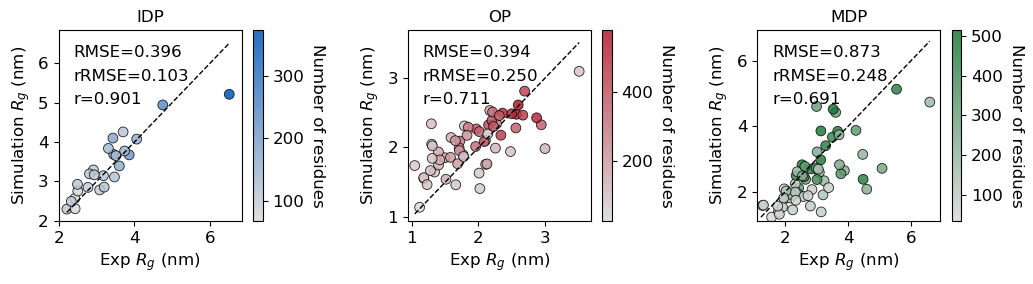

In [82]:
#!/usr/bin/env python3
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap

# ─────────────────────────────────────────────
# CONFIG
# ─────────────────────────────────────────────
path = './results/'
results = ['MOFF2']
sims = ['idp', 'op', 'mdp']
ff = 'MOFF2'
savepath = './manu_figures/'

os.makedirs(savepath, exist_ok=True)

light_grey = "#D9D9D9"

cmap_dict = {
    "idp": LinearSegmentedColormap.from_list(
        "idp_lightgrey_to_blue",
        [light_grey, "#0057B8"]
    ),
    "op": LinearSegmentedColormap.from_list(
        "op_lightgrey_to_red",
        [light_grey, "#B2182B"]
    ),
    "mdp": LinearSegmentedColormap.from_list(
        "mdp_lightgrey_to_green",
        [light_grey, "#1B7837"]
    ),
}

# ─────────────────────────────────────────────
# PLOT with colorbar for residue count
# ─────────────────────────────────────────────
n_rows = len(results)
n_cols = len(sims)

fig, axes = plt.subplots(
    n_rows,
    n_cols,
    figsize=(3.5 * n_cols, 3.0 * n_rows),
    squeeze=False
)

for i, result in enumerate(results):
    for j, sim in enumerate(sims):
        ax = axes[i, j]
        data = path + f"rg_summary_{sim}_{ff}.csv"

        df = pd.read_csv(data)
        subdf = df.copy()

        if subdf.empty:
            ax.axis("off")
            continue

        cmap_use = cmap_dict[sim]

        # scatter with class-specific colormap
        sc = ax.scatter(
            subdf["ref_rg"],
            subdf["sim_rg_mean"],
            c=subdf["n_residues"],
            cmap=cmap_use,
            s=50,
            edgecolor="k",
            linewidth=0.6,
            alpha=0.85,
            label=None
        )

        # error bars (optional)
        # ax.errorbar(
        #     subdf["ref_rg"],
        #     subdf["sim_rg_mean"],
        #     yerr=subdf["sim_rg_std"],
        #     fmt="none",
        #     ecolor="gray",
        #     alpha=0.5,
        #     zorder=1
        # )

        # calculate metrics
        diffs = subdf["sim_rg_mean"].values - subdf["ref_rg"].values
        rmse = np.sqrt(np.mean(diffs ** 2))
        #rrmse = rmse / np.mean(subdf["ref_rg"].values)
        rrmse = np.sqrt(np.mean(diffs ** 2 / (subdf["ref_rg"].values)**2))
        corr = np.corrcoef(
            subdf["ref_rg"].values,
            subdf["sim_rg_mean"].values
        )[0, 1]

        # diagonal line
        rg_min = min(subdf["ref_rg"].min(), subdf["sim_rg_mean"].min())
        rg_max = max(subdf["ref_rg"].max(), subdf["sim_rg_mean"].max())

        ax.plot(
            [rg_min, rg_max],
            [rg_min, rg_max],
            "k--",
            lw=1
        )

        # set equal ranges
        ax.set_xlim(rg_min * 0.9, rg_max * 1.05)
        ax.set_ylim(rg_min * 0.9, rg_max * 1.05)

        ax.set_xlabel("Exp $R_g$ (nm)")
        ax.set_ylabel("Simulation $R_g$ (nm)")
        ax.set_title(sim.upper())

        ax.legend(
            handles=[
                plt.Line2D([], [], linestyle="none", label=f"RMSE={rmse:.3f}"),
                plt.Line2D([], [], linestyle="none", label=f"rRMSE={rrmse:.3f}"),
                plt.Line2D([], [], linestyle="none", label=f"r={corr:.3f}"),
            ],
            loc="upper left",
            frameon=False,
            handlelength=0,
            handletextpad=0,
        )

        # add colorbar
        cbar = plt.colorbar(sc, ax=ax)
        cbar.set_label("Number of residues", rotation=270, labelpad=15)

plt.tight_layout()
plt.savefig(savepath + 'Figure3.MOFF2_test.pdf', dpi=300, bbox_inches='tight')
plt.show()

## Main Figure 4

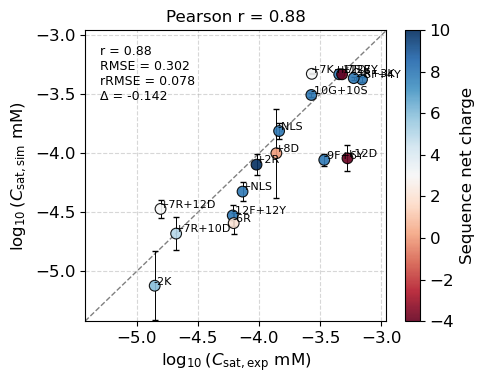

In [59]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import pearsonr
import mdtraj as md


# =====================================================
# Paths
# =====================================================

path = "./results/"


# =====================================================
# Read data
# =====================================================

df = pd.read_csv(
    path + "A1_C_sat_Tmatched_results_MOFF2.csv"
)

exp = df["exp_C_sat"].values / 1000
sim = df["sim_C_sat"].values
sim_std = df["sim_C_sat_sem_block"].values

log_exp = np.log10(np.clip(exp, 1e-12, None))
log_sim = np.log10(np.clip(sim, 1e-12, None))

# approximate log-space error
yerr = sim_std / np.clip(sim, 1e-12, None)

r, _ = pearsonr(log_exp, log_sim)




df["net_charge"] = charges


# remove rows with missing charge
valid = np.isfinite(df["net_charge"].values)

df_plot = df.loc[valid].copy()
log_exp_plot = log_exp[valid]
log_sim_plot = log_sim[valid]
yerr_plot = yerr[valid]


# =====================================================
# Recompute metrics using plotted rows only
# =====================================================

r, _ = pearsonr(log_exp_plot, log_sim_plot)

diff = log_sim_plot - log_exp_plot
rmse = np.sqrt(np.mean(diff ** 2))
rrmse = rmse / np.mean(np.abs(log_exp_plot))
delta = np.mean(diff)


# =====================================================
# Plot
# =====================================================

fig, ax = plt.subplots(figsize=(5., 4.0))

sc = ax.scatter(
    log_exp_plot,
    log_sim_plot,
    c=df_plot["net_charge"],
    cmap="RdBu",
    s=60,
    edgecolors="black",
    linewidths=0.8,
    alpha=0.9,
    zorder=3,
)

ax.errorbar(
    log_exp_plot,
    log_sim_plot,
    yerr=yerr_plot,
    fmt="none",
    ecolor="black",
    elinewidth=0.7,
    capsize=2,
    zorder=2,
)

# labels: remove A1-LCD / A1
for i, p in enumerate(df_plot["protein"].values):

    label = (
        p.replace("A1-LCD", "")
         .replace("A1", "")
    )

    if label == "":
        label = "WT"

    ax.text(
        log_exp_plot[i] - 0.01,
        log_sim_plot[i] + 0.01,
        label,
        fontsize=8,
    )

# 1:1 line
min_val = min(log_exp_plot.min(), log_sim_plot.min()) - 0.3
max_val = max(log_exp_plot.max(), log_sim_plot.max()) + 0.2

ax.plot(
    [min_val, max_val],
    [min_val, max_val],
    "--",
    color="gray",
    linewidth=1.0,
    zorder=1,
)

ax.set_xlim(min_val, max_val)
ax.set_ylim(min_val, max_val)

ax.set_xlabel(r"$\log_{10}(C_{\mathrm{sat,exp}}\ \mathrm{mM})$")
ax.set_ylabel(r"$\log_{10}(C_{\mathrm{sat,sim}}\ \mathrm{mM})$")

ax.set_title(
    f"Pearson r = {r:.2f}"
)

ax.text(
    0.05,
    0.95,
    f"r = {r:.2f}\n"
    f"RMSE = {rmse:.3f}\n"
    f"rRMSE = {rrmse:.3f}\n"
    f"Δ = {delta:.3f}",
    transform=ax.transAxes,
    ha="left",
    va="top",
    fontsize=9,
)

ax.grid(
    True,
    linestyle="--",
    alpha=0.5,
)

cbar = plt.colorbar(sc, ax=ax)
cbar.set_label("Sequence net charge")

plt.tight_layout()

plt.savefig(savepath + "Figure4A.pdf", dpi=300, bbox_inches="tight")


plt.show()


Plotting from CSV: A1-LCD+7R+12D
Saved figure: ./results/density_plots/Fig3a1.A1minusLCDplus7Rplus12D.pdf


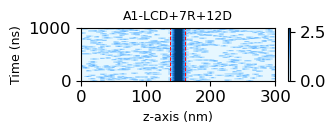


Plotting from CSV: A1-LCD+7R+10D
Saved figure: ./results/density_plots/Fig3a1.A1minusLCDplus7Rplus10D.pdf


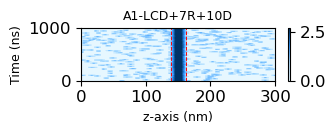


Plotting from CSV: A1-LCD-6R
Saved figure: ./results/density_plots/Fig3a1.A1minusLCDminus6R.pdf


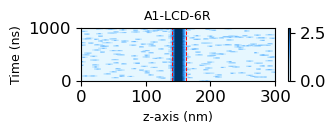


Plotting from CSV: A1-LCD-12F+12Y
Saved figure: ./results/density_plots/Fig3a1.A1minusLCDminus12Fplus12Y.pdf


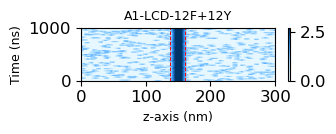


Plotting from CSV: A1-LCD-2K
Saved figure: ./results/density_plots/Fig3a1.A1minusLCDminus2K.pdf


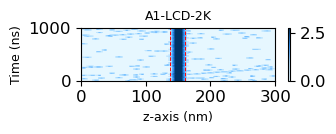


Plotting from CSV: A1-LCD-NLS
Saved figure: ./results/density_plots/Fig3a1.A1minusLCDminusNLS.pdf


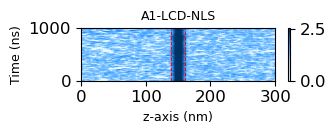


Plotting from CSV: A1-LCD+NLS
Saved figure: ./results/density_plots/Fig3a1.A1minusLCDplusNLS.pdf


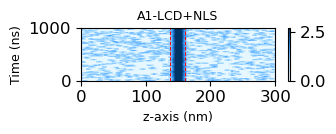


Plotting from CSV: A1-LCD+8D
Saved figure: ./results/density_plots/Fig3a1.A1minusLCDplus8D.pdf


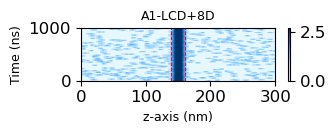


Plotting from CSV: A1-LCD-10G+10S
Saved figure: ./results/density_plots/Fig3a1.A1minusLCDminus10Gplus10S.pdf


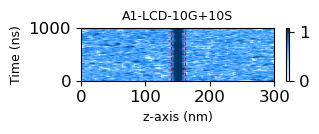


Plotting from CSV: A1-LCD+7F-7Y
Saved figure: ./results/density_plots/Fig3a1.A1minusLCDplus7Fminus7Y.pdf


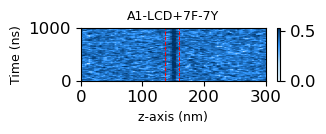


Plotting from CSV: A1-LCD+12D
Saved figure: ./results/density_plots/Fig3a1.A1minusLCDplus12D.pdf


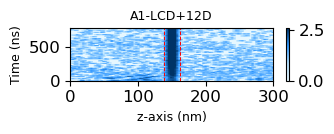


Plotting from CSV: A1-LCD+12E
Saved figure: ./results/density_plots/Fig3a1.A1minusLCDplus12E.pdf


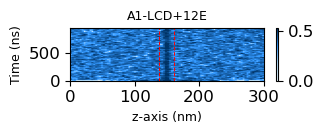


Plotting from CSV: A1-LCD+2R
Saved figure: ./results/density_plots/Fig3a1.A1minusLCDplus2R.pdf


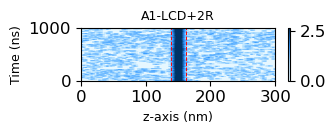


Plotting from CSV: A1-LCD+7K+12D
Saved figure: ./results/density_plots/Fig3a1.A1minusLCDplus7Kplus12D.pdf


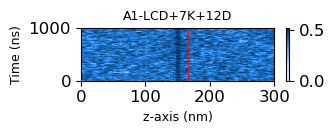


Plotting from CSV: A1-LCD-9F+6Y
Saved figure: ./results/density_plots/Fig3a1.A1minusLCDminus9Fplus6Y.pdf


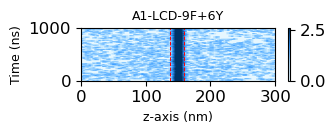


Plotting from CSV: A1-LCD-3R+3K
Saved figure: ./results/density_plots/Fig3a1.A1minusLCDminus3Rplus3K.pdf


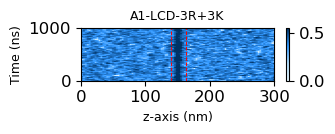


Plotting from CSV: A1-LCD-8F+4Y
Saved figure: ./results/density_plots/Fig3a1.A1minusLCDminus8Fplus4Y.pdf


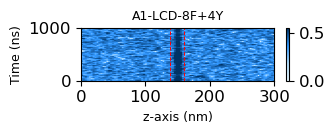


Plotting from CSV: A1-LCD-Y2W
Saved figure: ./results/density_plots/Fig3a1.A1minusLCDminusY2W.pdf


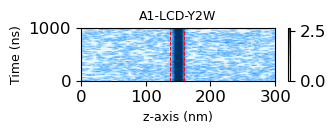


Plotting from CSV: A1-LCD-F2W
Saved figure: ./results/density_plots/Fig3a1.A1minusLCDminusF2W.pdf


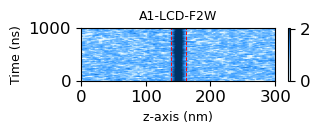


Plotting from CSV: A1-LCD-allW
Saved figure: ./results/density_plots/Fig3a1.A1minusLCDminusallW.pdf


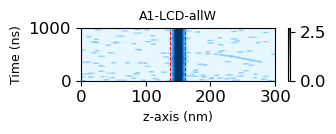


Plotting from CSV: A1-LCD-W-
Saved figure: ./results/density_plots/Fig3a1.A1minusLCDminusWminus.pdf


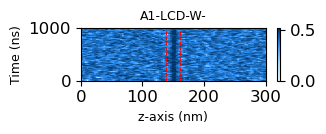

In [71]:
#!/usr/bin/env python3
import os
import numpy as np
import pandas as pd
import mdtraj as md
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors

# ─────────────────────────────────────────────
# CONFIG
# ─────────────────────────────────────────────

path = f"./results/"

sims=[
    'A1-LCD+7R+12D',
    'A1-LCD+7R+10D',
    'A1-LCD-6R',
    'A1-LCD-12F+12Y',
    'A1-LCD-2K',
    'A1-LCD-NLS',
    'A1-LCD+NLS',
    'A1-LCD+8D',
    'A1-LCD-10G+10S',
    'A1-LCD+7F-7Y',
    'A1-LCD+12D',
    'A1-LCD+12E',
    'A1-LCD+2R',
    'A1-LCD+7K+12D',
    'A1-LCD-9F+6Y',
    'A1-LCD-3R+3K',
    'A1-LCD-8F+4Y',
    'A1-LCD-Y2W',
    'A1-LCD-F2W',
    'A1-LCD-allW',
    'A1-LCD-W-',
    
]

discard_frac = 0.0
n_bins = 100

BOX_DEFAULT = np.array([25.0, 25.0, 300.0])

dt_ns = 10.0  # ns per saved frame

savepath = os.path.join(path, "density_plots/")
os.makedirs(savepath, exist_ok=True)

data_savepath = os.path.join(path, "density_plotted_data/")
os.makedirs(data_savepath, exist_ok=True)



def plot_time_density_from_array(
    sim_name,
    density_matrix,
    zmin,
    zmax,
    tmax,
    core_bounds=None,
    save_pdf=True
):
    """
    Plot time-density map from array.
    Used by both Part 1 and Part 2.
    """
    safe_name = safe_filename(sim_name)

    colors = ["#e6f7ff", "#b3e0ff", "#3399ff", "#003366"]
    cmap = mcolors.LinearSegmentedColormap.from_list(
        "enhanced_white_to_blue",
        colors,
        N=256
    )

    vmin = np.percentile(density_matrix, 1)
    vmax = np.percentile(density_matrix, 97)

    norm = mcolors.PowerNorm(
        gamma=0.2,
        vmin=vmin,
        vmax=vmax
    )

    plt.figure(figsize=(3.5, 1.5))

    im = plt.imshow(
        density_matrix,
        extent=[zmin, zmax, 0, tmax],
        aspect="auto",
        origin="lower",
        cmap=cmap,
        norm=norm
    )

    plt.colorbar(im)
    plt.xlabel("z-axis (nm)", fontsize=9)
    plt.ylabel("Time (ns)", fontsize=9)
    plt.title(sim_name, fontsize=9)

    if core_bounds is not None:
        core1, core2 = core_bounds
        plt.axvline(core1, color="red", linestyle="--", linewidth=0.7)
        plt.axvline(core2, color="red", linestyle="--", linewidth=0.7)

    plt.tight_layout()

    if save_pdf:
        fig_pdf = os.path.join(savepath, f"Fig3a1.{safe_name}.pdf")
        plt.savefig(fig_pdf)
        print(f"Saved figure: {fig_pdf}")

    plt.show()




def load_time_density_csv(density_csv):
    """
    Load saved 2D time-density CSV.

    Returns:
        times_ns
        density_matrix
    """
    df = pd.read_csv(density_csv)

    times_ns = df["time_ns"].to_numpy(dtype=float)
    density_matrix = df.drop(columns=["time_ns"]).to_numpy(dtype=float)

    return times_ns, density_matrix


def load_z_bins_csv(zbin_csv):
    """
    Load z-bin metadata.
    """
    zbin_df = pd.read_csv(zbin_csv)

    z_centers = zbin_df["z_center_nm"].to_numpy(dtype=float)
    z_left = zbin_df["z_left_nm"].to_numpy(dtype=float)
    z_right = zbin_df["z_right_nm"].to_numpy(dtype=float)

    zmin = z_left[0]
    zmax = z_right[-1]

    return z_centers, zmin, zmax


def part2_load_csv_and_plot():
    """
    This part does not read DCD.
    It only reads saved CSV files and regenerates figures.
    """
    summary_csv = os.path.join(
        data_savepath,
        "density_summary.csv"
    )

    if not os.path.exists(summary_csv):
        raise FileNotFoundError(
            f"Cannot find summary CSV: {summary_csv}\n"
            "Run part1_save_all_density_csv() first."
        )

    summary_df = pd.read_csv(summary_csv)

    for _, row in summary_df.iterrows():
        sim = row["protein"]

        print(f"\nPlotting from CSV: {sim}")

        density_csv = row["time_density_csv"]
        zbin_csv = row["zbin_csv"]

        if not os.path.exists(density_csv):
            print(f"⚠ Missing density CSV: {density_csv}")
            continue

        if not os.path.exists(zbin_csv):
            print(f"⚠ Missing z-bin CSV: {zbin_csv}")
            continue

        times_ns, density_matrix = load_time_density_csv(density_csv)
        z_centers, zmin, zmax = load_z_bins_csv(zbin_csv)

        if row["has_slab"]:
            core_bounds = (
                float(row["core1_nm"]),
                float(row["core2_nm"])
            )
        else:
            core_bounds = None

        if len(times_ns) > 1:
            tmax = times_ns[-1] + (times_ns[1] - times_ns[0])
        else:
            tmax = times_ns[-1]

        plot_time_density_from_array(
            sim_name=sim,
            density_matrix=density_matrix,
            zmin=zmin,
            zmax=zmax,
            tmax=tmax,
            core_bounds=core_bounds,
            save_pdf=True
        )



# ============================================================
# CHOOSE WHAT TO RUN
# ============================================================

if __name__ == "__main__":

    # First time:
    
    # Later, after CSVs already exist:
    # Comment out Part 1 above and uncomment this:
    part2_load_csv_and_plot()

## Main Figure 5, Figure S4-S8

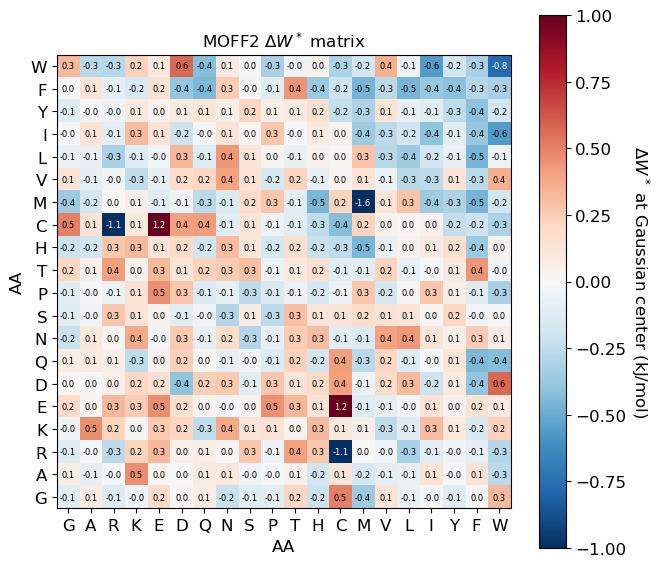

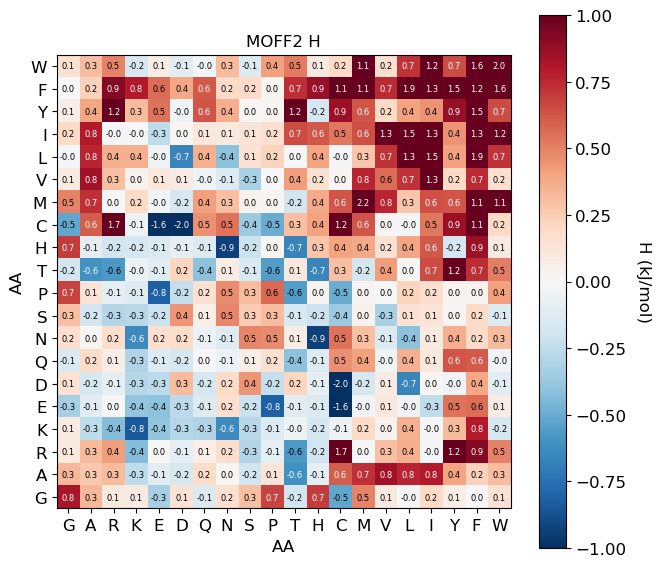

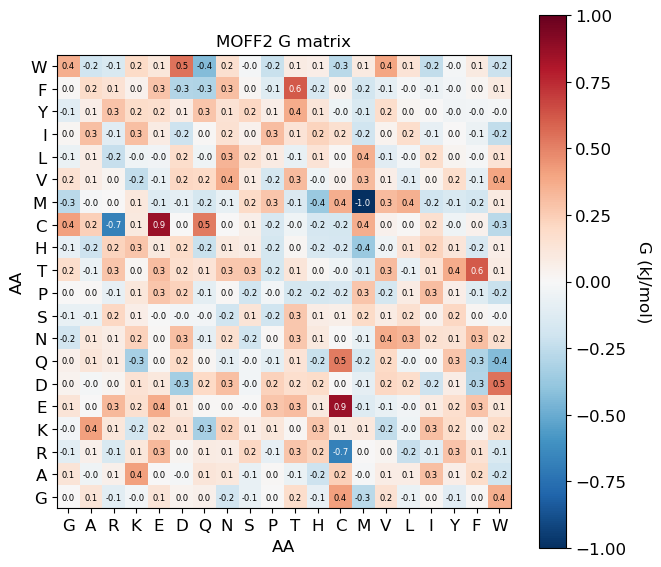


Loaded summary_HPS sources
n_sources: 21
Bandyopadhyay-Mehler (2008)
Biou accessibility information value
Black-Mould (1991)
Cornette (1987)
Eisenberg (1984)
Engelman GES (1986)
FDewet_C36m (2024)
FDewet_a03ws (2024)
FDewet_a99SBdisp (2024)
Hassanali_nBranch <nbr> (2023)
Hopp-Woods (1981)
Jain (2017)
Janin (1979)
Kyte-Doolittle (1982)
Meek (1980)
PARCH (2023)
Ponnuswamy average gain in surrounding hydrophobicity
Ponnuswamy surrounding hydrophobicity folded form
Rose (1985)
Tanford (1962)
Wimley-White (1996)

Density profile matrix
X_density shape: (20, 500)

PCA: MOFF2_lambda
PC1: 0.3545
PC2: 0.1653
PC3: 0.1075
PC4: 0.0977

PCA: MOFF2_gaussian
PC1: 0.1873
PC2: 0.1334
PC3: 0.1205
PC4: 0.0962

PCA: delta_W_star
PC1: 0.1869
PC2: 0.1597
PC3: 0.1240
PC4: 0.0992

PCA: MJ_epsilon
PC1: 0.9598
PC2: 0.0204
PC3: 0.0113
PC4: 0.0027

PCA: HPS_Urry_lambda
PC1: 1.0000
PC2: 0.0000
PC3: 0.0000
PC4: 0.0000

PCA: Density_profile
PC1: 0.5197
PC2: 0.2733
PC3: 0.1261
PC4: 0.0563

Combined sign-aligned scor

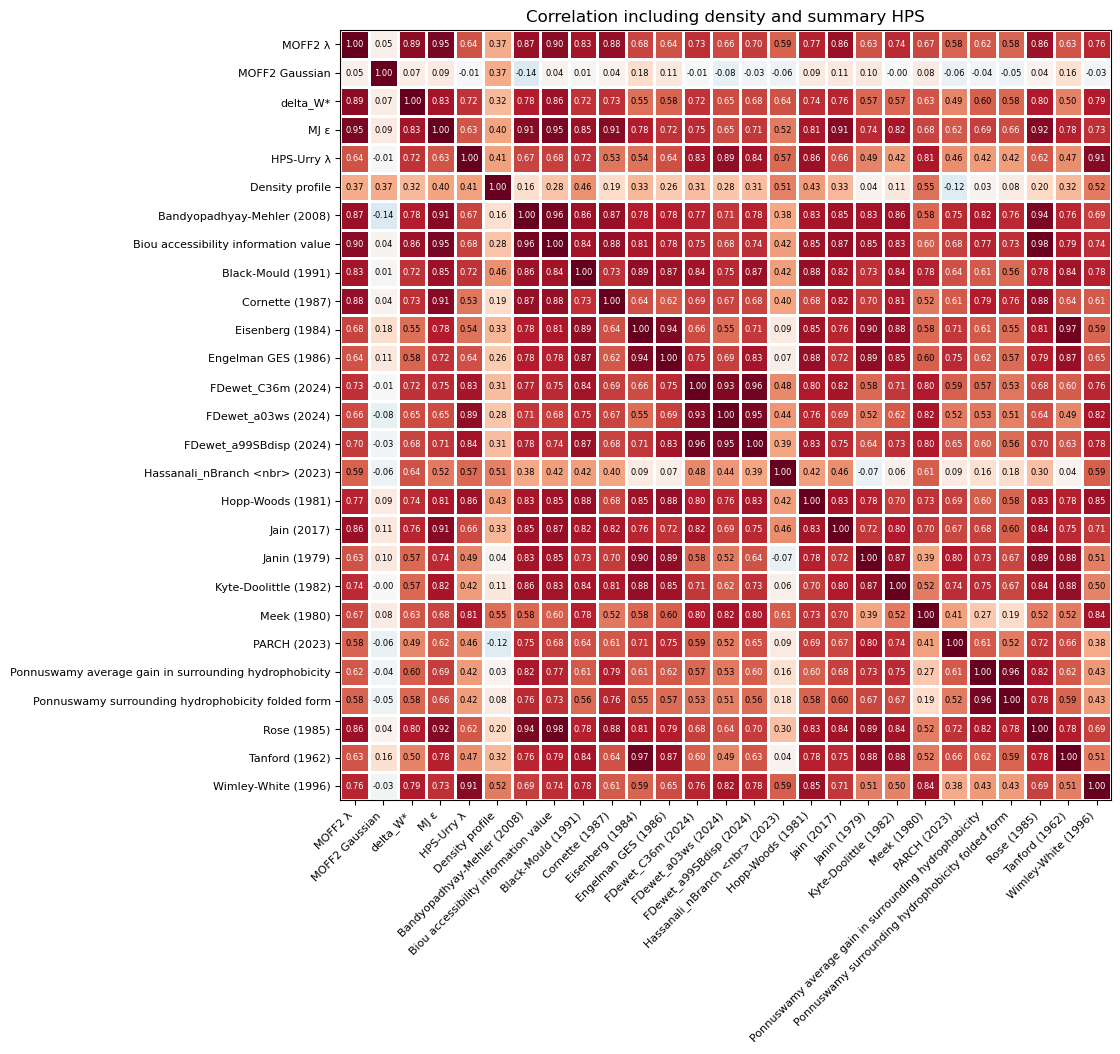

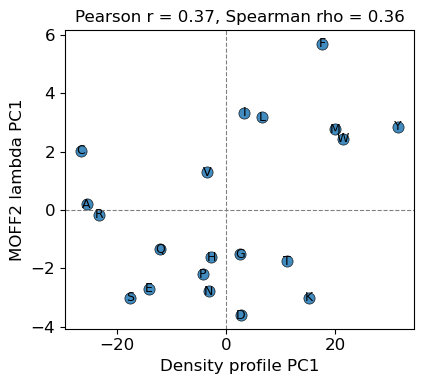

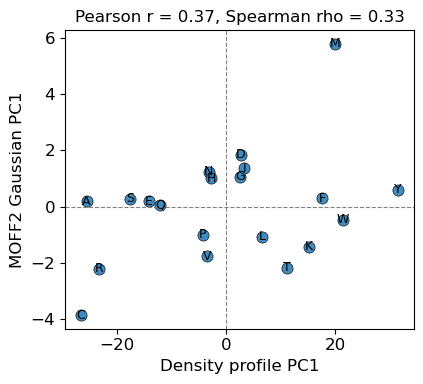

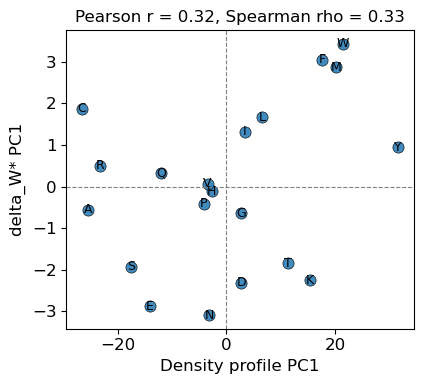

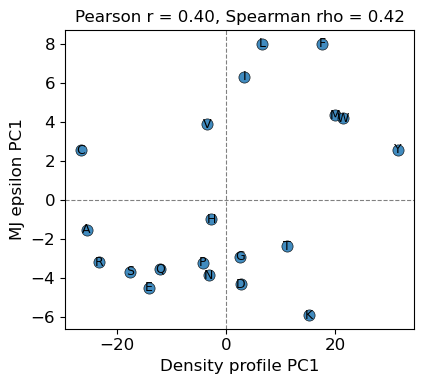

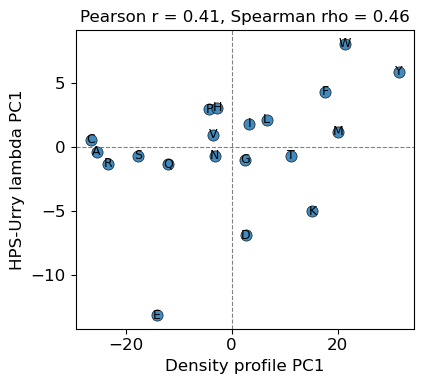

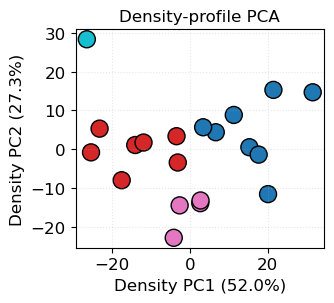

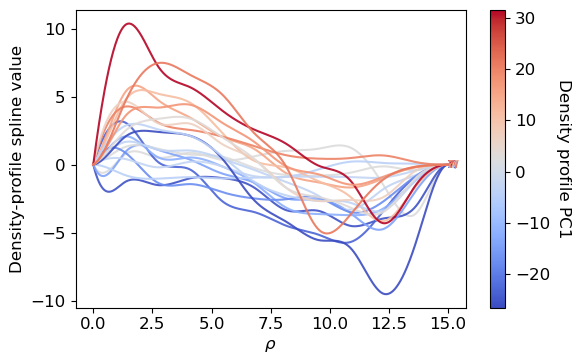


MOFF2 lambda PC1-PC2 clustering PC1-PC2 clusters
   AA       PC1       PC2  cluster
0   G -1.511811 -2.652287        1
1   A  0.189984 -0.489453        0
2   R -0.167031  1.582138        3
3   K -3.006371  0.953075        3
4   E -2.703160  2.505721        3
5   D -3.604982 -0.530157        1
6   Q -1.355993  0.601556        3
7   N -2.787308 -0.863840        1
8   S -3.008203 -1.125541        1
9   P -2.197842 -1.437317        1
10  T -1.761476  1.371040        3
11  H -1.629304 -1.320492        1
12  C  2.029205  5.891257        2
13  M  2.755147 -1.178059        0
14  V  1.288631 -0.446161        0
15  L  3.167520 -0.545410        0
16  I  3.328628 -1.475812        0
17  Y  2.853064  0.769586        0
18  F  5.685609 -1.097533        0
19  W  2.435693 -0.512313        0


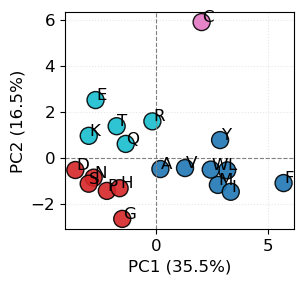


MOFF2 Gaussian PC1-PC2 clustering PC1-PC2 clusters
   AA       PC1       PC2  cluster
0   G  1.065333  0.573201        1
1   A  0.194159  1.809561        0
2   R -2.210017 -1.277468        3
3   K -1.416566 -2.111868        3
4   E  0.192532 -1.284290        1
5   D  1.840948 -1.391090        1
6   Q  0.063659  0.755089        1
7   N  1.239545 -0.268471        1
8   S  0.283904 -0.481887        1
9   P -1.000811  2.600421        0
10  T -2.169227 -1.651813        3
11  H  1.004783  0.656357        1
12  C -3.852890  3.930210        0
13  M  5.785366  1.419948        2
14  V -1.763565 -1.848115        3
15  L -1.064214 -0.647050        3
16  I  1.372219 -0.029267        1
17  Y  0.599119 -1.278088        1
18  F  0.302531 -1.503323        1
19  W -0.466809  2.027943        0


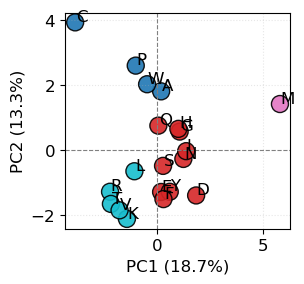


delta_W* PC1-PC2 clustering PC1-PC2 clusters
   AA       PC1       PC2  cluster
0   G -0.645233 -0.666507        1
1   A -0.562169  0.131306        1
2   R  0.499575  1.196991        1
3   K -2.250984  0.587329        3
4   E -2.876264 -0.026847        3
5   D -2.312819 -1.387153        3
6   Q  0.337703 -0.182943        1
7   N -3.090407 -0.693239        3
8   S -1.923327 -0.673742        3
9   P -0.417936  1.120868        1
10  T -1.843973  1.300082        3
11  H -0.108543 -1.323977        1
12  C  1.868919  5.632797        2
13  M  2.865646 -4.259133        0
14  V  0.065593  0.406137        1
15  L  1.663782  0.560254        1
16  I  1.313230 -0.674896        1
17  Y  0.942631 -0.419712        1
18  F  3.044617 -1.509789        0
19  W  3.429960  0.882172        0


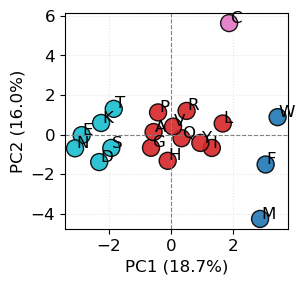


Density profile PC1-PC2 clustering PC1-PC2 clusters
   AA        PC1        PC2  cluster
0   G   2.627670 -13.857055        2
1   A -25.465534  -0.787858        0
2   R -23.264581   5.322352        0
3   K  15.250423   0.537305        1
4   E -14.096241   1.106063        0
5   D   2.693018 -13.171153        2
6   Q -11.964510   1.744040        0
7   N  -3.161070  -3.395449        1
8   S -17.577192  -7.958183        0
9   P  -4.195053 -22.772833        2
10  T  11.243136   8.840174        1
11  H  -2.682082 -14.426504        2
12  C -26.542095  28.321584        0
13  M  20.048980 -11.533308        1
14  V  -3.477812   3.369589        1
15  L   6.605685   4.388579        1
16  I   3.363427   5.672900        1
17  Y  31.530750  14.671093        3
18  F  17.633148  -1.365529        1
19  W  21.429932  15.294192        3


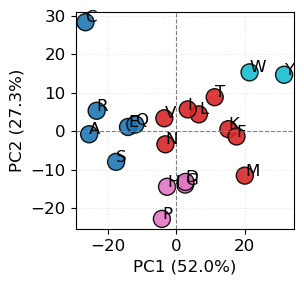


Done.
All outputs saved to: ./manu_figures/


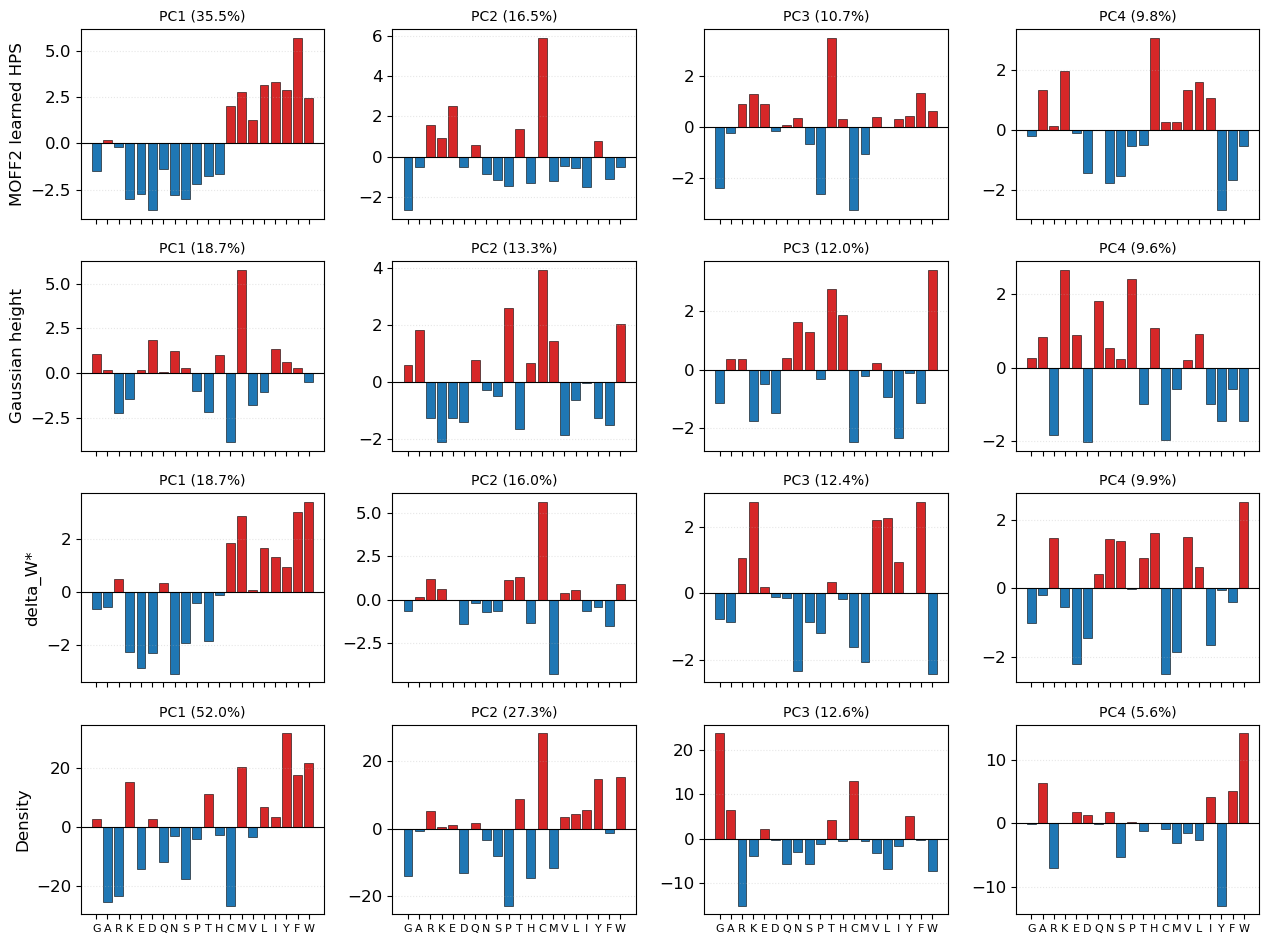


Done.
All outputs saved to: ./manu_figures/

Matrix-level correlations
lambda vs delta_W* Pearson: -0.6889815542127955
lambda vs Gaussian height Pearson: -0.29033821272117205
Gaussian height vs delta_W* Pearson: 0.8918341351149887

Ranges:
lambda: -1.9656792879104614 2.1824212074279785
Gaussian height: -1.0420989990234375 0.8653412461280823
delta_W*: -1.5710947867531504 1.2191314682773902

Row-mean correlations
row mean lambda vs row mean delta_W*: -0.8646562714498935
row mean Gaussian vs row mean delta_W*: 0.7777040786094027


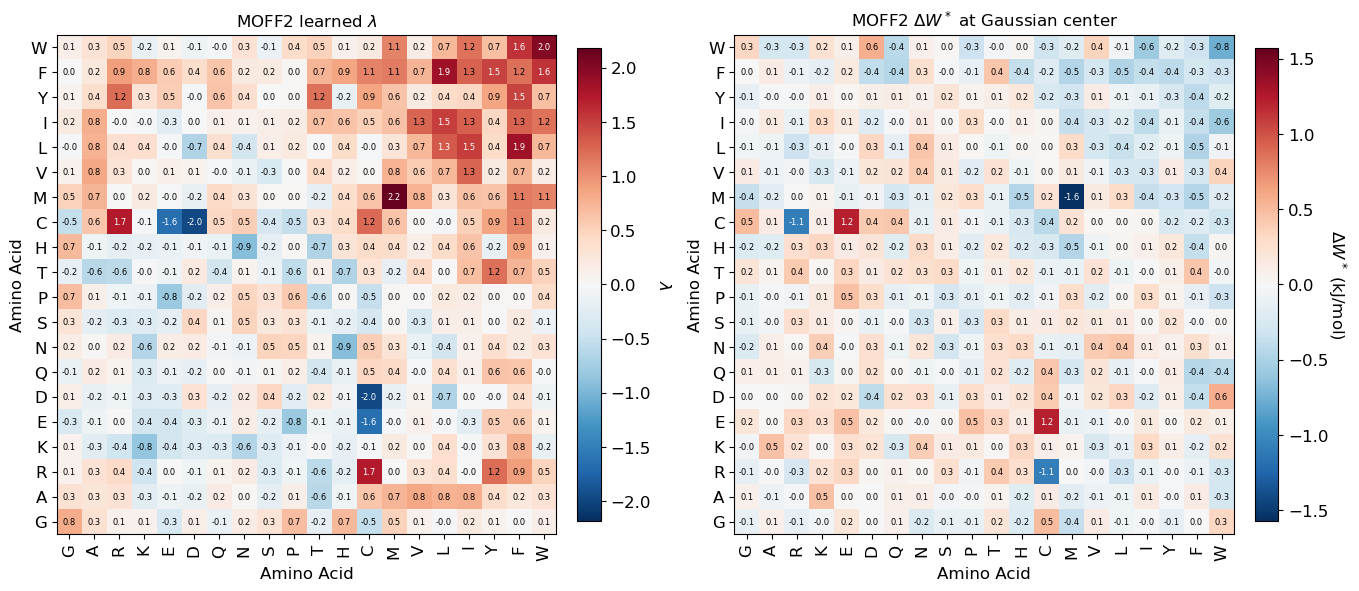


Full PC1 correlation summary
                                                 PC1_1                PC1_2  \
0                                              MOFF2 λ       MOFF2 Gaussian   
1                                              MOFF2 λ             delta_W*   
2                                              MOFF2 λ                 MJ ε   
3                                              MOFF2 λ           HPS-Urry λ   
4                                              MOFF2 λ      Density profile   
..                                                 ...                  ...   
346  Ponnuswamy surrounding hydrophobicity folded form       Tanford (1962)   
347  Ponnuswamy surrounding hydrophobicity folded form  Wimley-White (1996)   
348                                        Rose (1985)       Tanford (1962)   
349                                        Rose (1985)  Wimley-White (1996)   
350                                     Tanford (1962)  Wimley-White (1996)   

     pearson_r     pe

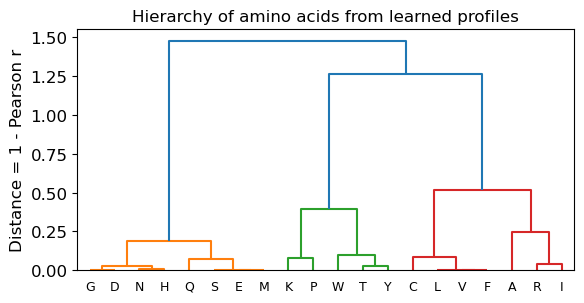

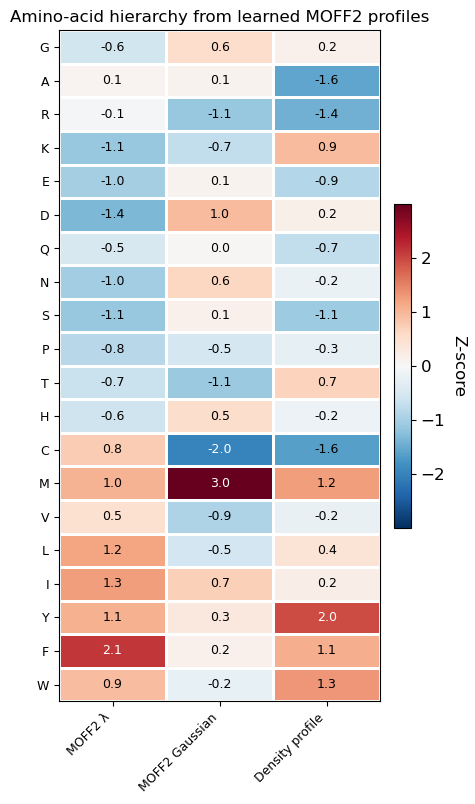


MOFF2 learned profiles vs existing HPS/reference profiles
MOFF2 λ                         MOFF2 learned
MOFF2 Gaussian                  MOFF2 learned
Density profile                 MOFF2 learned
MJ ε                            Existing/reference
HPS-Urry λ                      Existing/reference
Bandyopadhyay-Mehler (2008)     Existing/reference
Biou accessibility information value  Existing/reference
Black-Mould (1991)              Existing/reference
Cornette (1987)                 Existing/reference
Eisenberg (1984)                Existing/reference
Engelman GES (1986)             Existing/reference
FDewet_C36m (2024)              Existing/reference
FDewet_a03ws (2024)             Existing/reference
FDewet_a99SBdisp (2024)         Existing/reference
Hassanali_nBranch <nbr> (2023)  Existing/reference
Hopp-Woods (1981)               Existing/reference
Jain (2017)                     Existing/reference
Janin (1979)                    Existing/reference
Kyte-Doolittle (1982)           

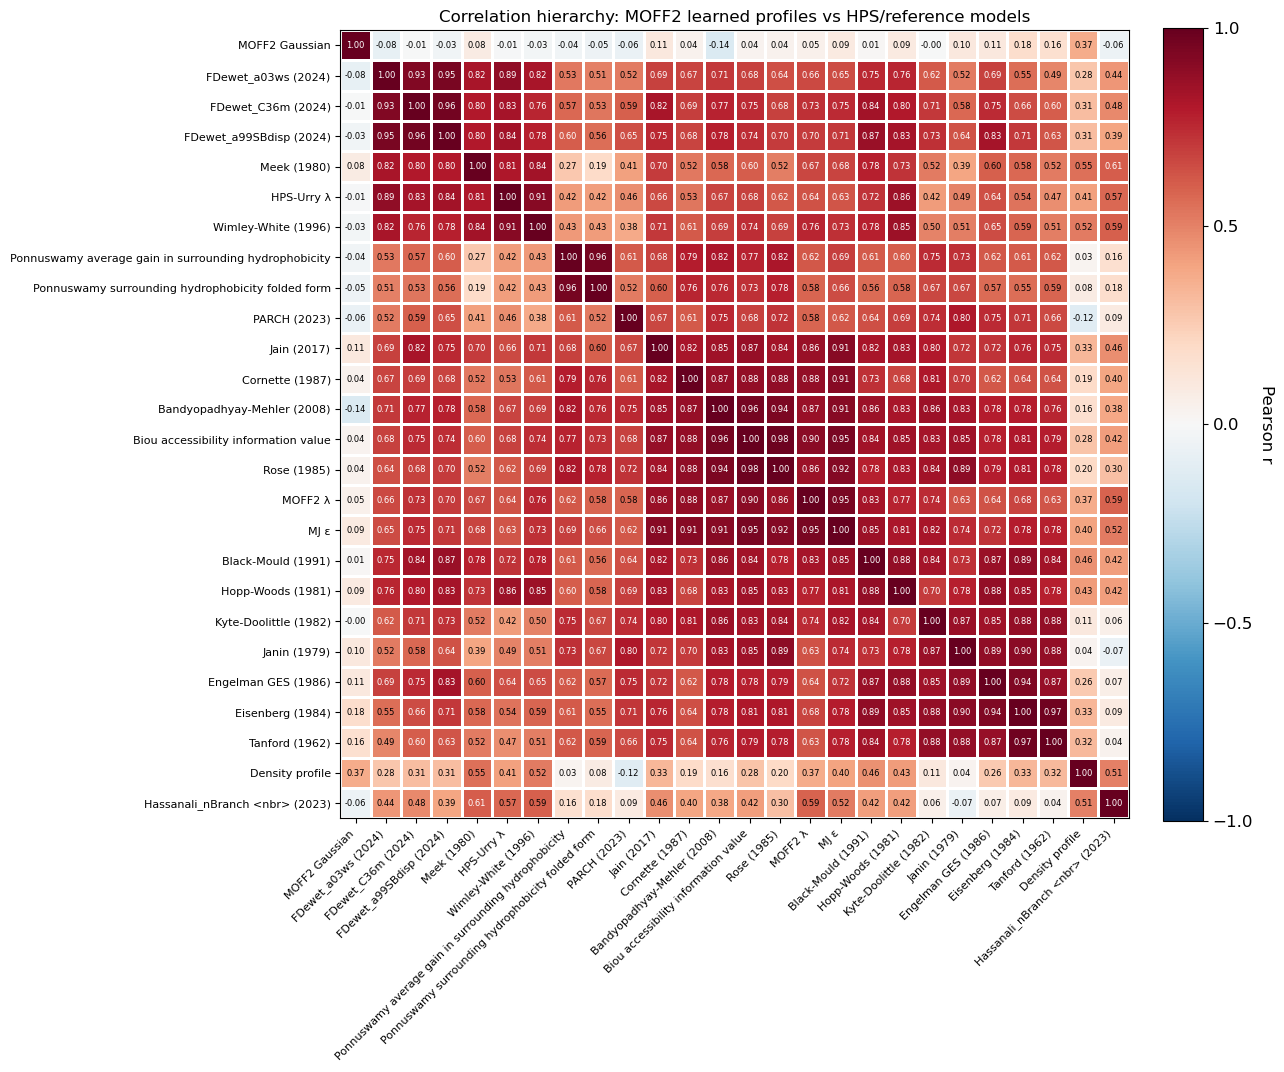

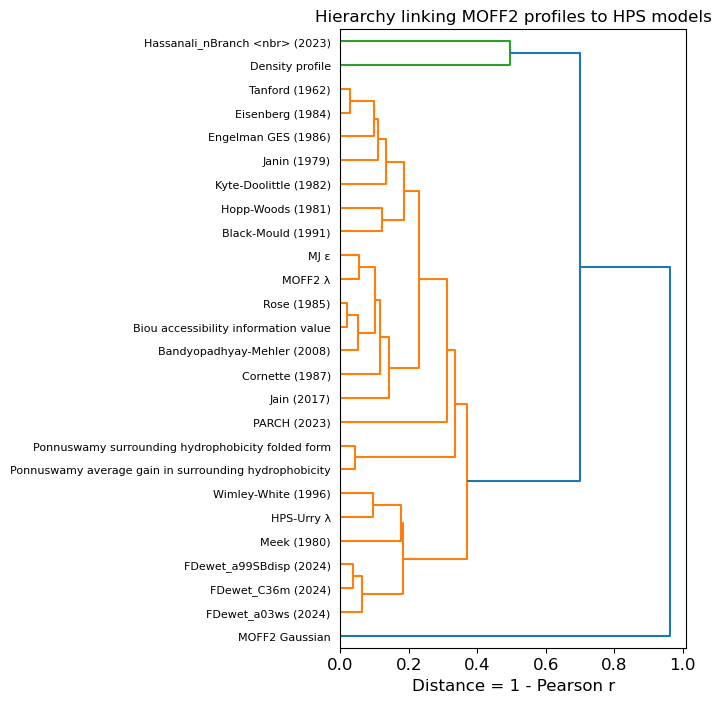


Top 3 HPS/reference links for each MOFF2 profile
     MOFF2_profile                     Reference_profile  pearson_r  \
0  Density profile                           Meek (1980)   0.552090   
1  Density profile                   Wimley-White (1996)   0.519242   
2  Density profile        Hassanali_nBranch <nbr> (2023)   0.505965   
3   MOFF2 Gaussian                      Eisenberg (1984)   0.176195   
4   MOFF2 Gaussian                        Tanford (1962)   0.159468   
5   MOFF2 Gaussian           Bandyopadhyay-Mehler (2008)  -0.144069   
6          MOFF2 λ                                  MJ ε   0.946258   
7          MOFF2 λ  Biou accessibility information value   0.900974   
8          MOFF2 λ                       Cornette (1987)   0.881234   

      pearson_p     abs_r  
0  1.160402e-02  0.552090  
1  1.896781e-02  0.519242  
2  2.283855e-02  0.505965  
3  4.574369e-01  0.176195  
4  5.018632e-01  0.159468  
5  5.445234e-01  0.144069  
6  2.920142e-10  0.946258  
7  6.042217e-08

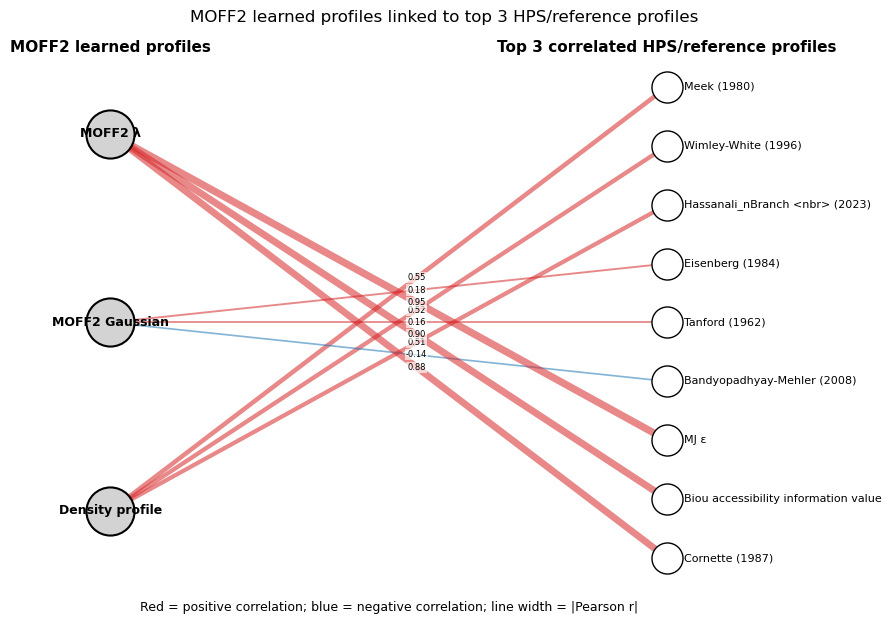


Anchor MOFF2 profiles
['MOFF2 λ', 'MOFF2 Gaussian', 'Density profile']

Reference/HPS profiles
['MJ ε', 'HPS-Urry λ', 'Bandyopadhyay-Mehler (2008)', 'Biou accessibility information value', 'Black-Mould (1991)', 'Cornette (1987)', 'Eisenberg (1984)', 'Engelman GES (1986)', 'FDewet_C36m (2024)', 'FDewet_a03ws (2024)', 'FDewet_a99SBdisp (2024)', 'Hassanali_nBranch <nbr> (2023)', 'Hopp-Woods (1981)', 'Jain (2017)', 'Janin (1979)', 'Kyte-Doolittle (1982)', 'Meek (1980)', 'PARCH (2023)', 'Ponnuswamy average gain in surrounding hydrophobicity', 'Ponnuswamy surrounding hydrophobicity folded form', 'Rose (1985)', 'Tanford (1962)', 'Wimley-White (1996)']

MOFF2 λ: top 5 correlated HPS/reference profiles
  anchor_profile                     reference_profile  pearson_r  \
0        MOFF2 λ                                  MJ ε   0.946258   
1        MOFF2 λ  Biou accessibility information value   0.900974   
2        MOFF2 λ                       Cornette (1987)   0.881234   
3        MOFF2 λ    

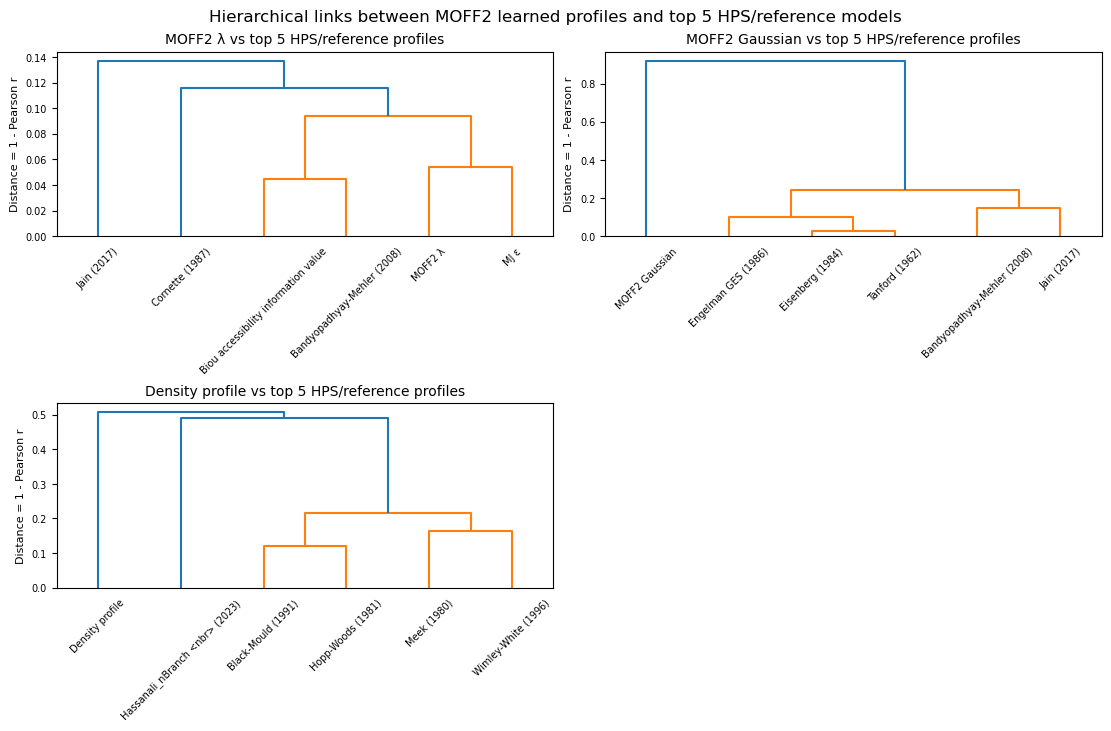

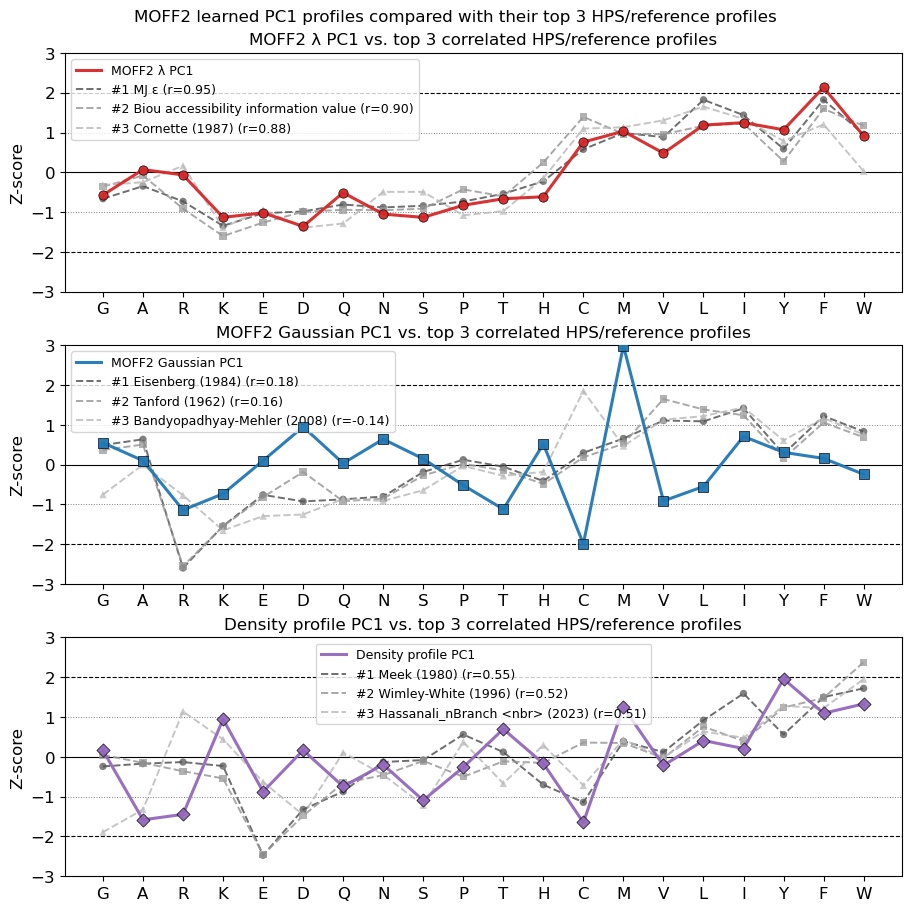


MOFF2 learned profiles vs existing HPS/reference profiles
MOFF2 λ                                        MOFF2 learned
MOFF2 Gaussian                                 MOFF2 learned
Density profile                                MOFF2 learned
MJ ε                                           Existing/reference
HPS-Urry λ                                     Existing/reference
Bandyopadhyay-Mehler (2008)                    Existing/reference
Biou accessibility information value           Existing/reference
Black-Mould (1991)                             Existing/reference
Cornette (1987)                                Existing/reference
Eisenberg (1984)                               Existing/reference
Engelman GES (1986)                            Existing/reference
FDewet_C36m (2024)                             Existing/reference
FDewet_a03ws (2024)                            Existing/reference
FDewet_a99SBdisp (2024)                        Existing/reference
Hassanali_nBranch <nbr> (2023)  

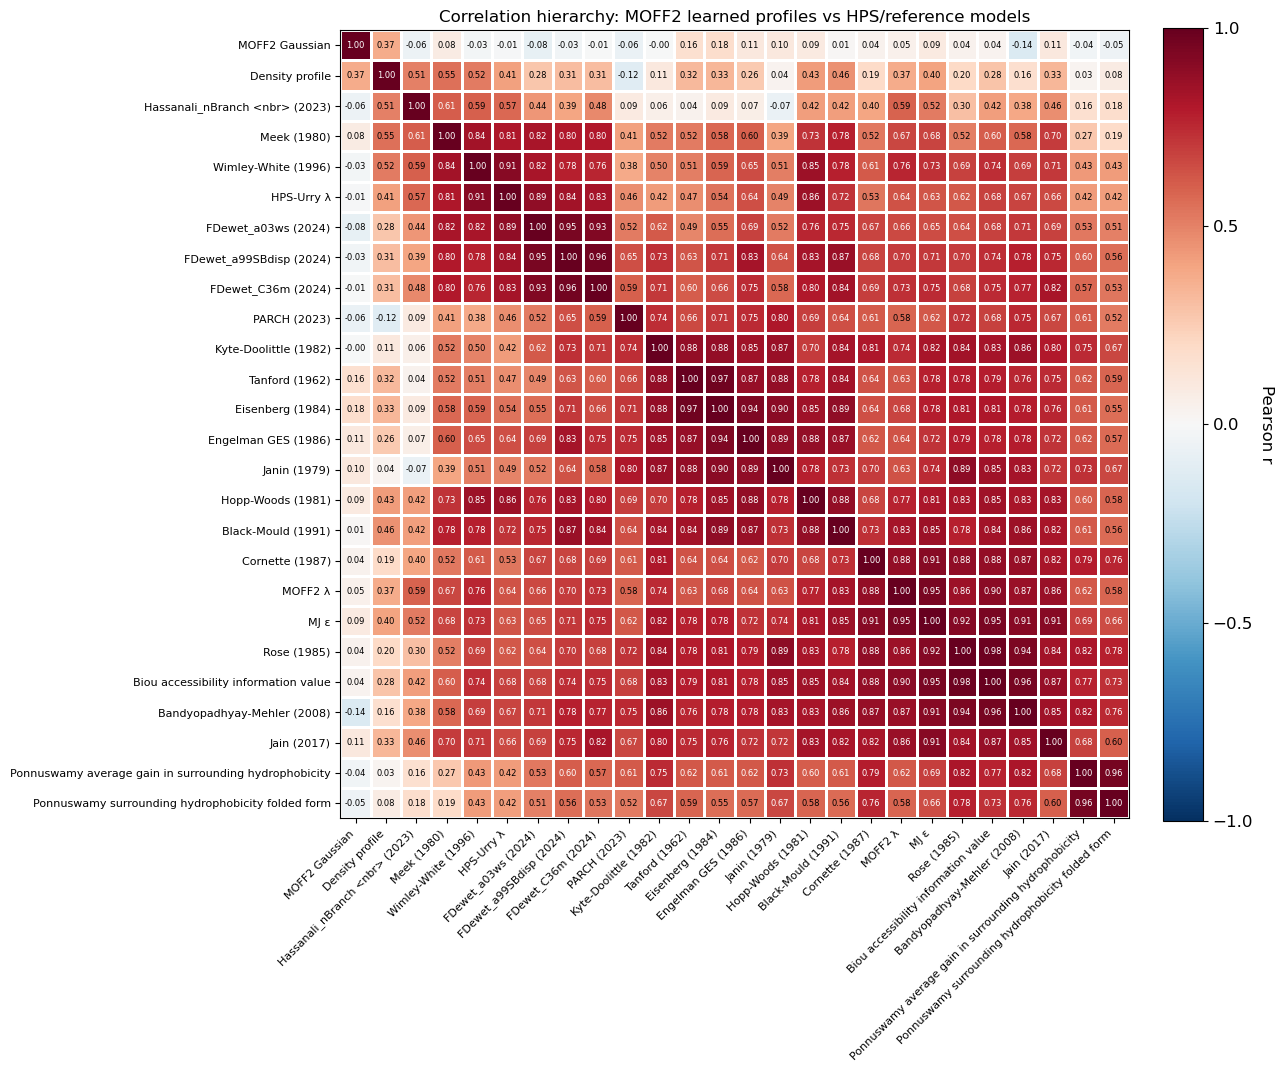

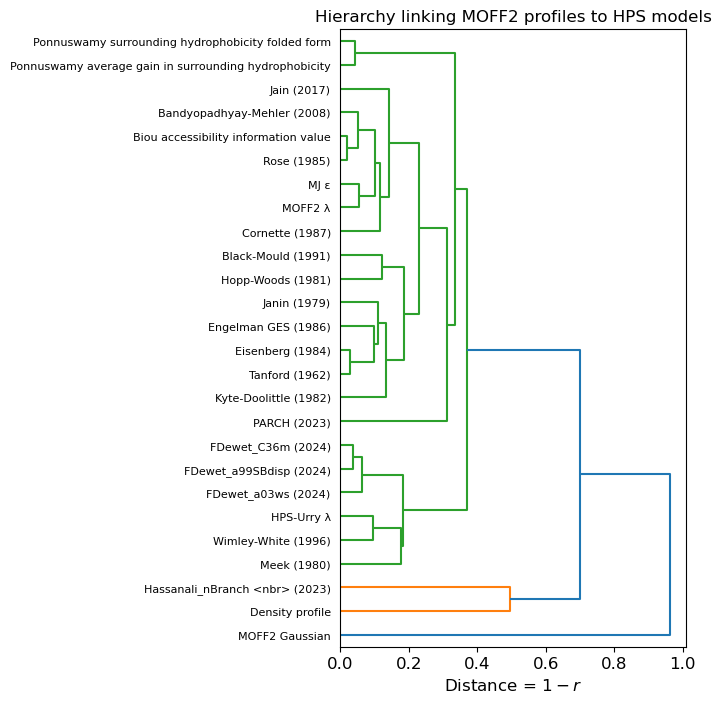

In [26]:
# %load /home/yumzhang/orcd/pool/work/4-idpcg/for_figure5/plot_2.py
#!/usr/bin/env python3

import os
import pickle
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors

from scipy.interpolate import BSpline
from scipy.stats import pearsonr, spearmanr
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import AgglomerativeClustering


# =========================================================
# CONFIG
# =========================================================
param_dir = "./parameters"
pkl_path = (
    "./parameters/"
    "MOFF2.pkl"
)

summary_hps_path = "./parameters/summary_HPS.csv"


mj_path = os.path.join(param_dir, "raw_MJ.csv")
hps_urry_path = os.path.join(param_dir, "HPS_Urry_parameters.csv")

savepath = "./manu_figures/"
os.makedirs(savepath, exist_ok=True)

# AH/Gaussian-tail constants. Keep this consistent with the pair-potential plotting script.
c216 = 2 ** (1 / 6)
kcal_to_kj = 4.184
epsilon_hps_urry = 0.2 * kcal_to_kj
# Gaussian center offset used by Gaussian_tail(): mu = r_min + extra.
gaussian_center_extra = 0.25


# =========================================================
# AMINO ACID ORDERING
# =========================================================

aa_labels_orig = [
    "A", "R", "N", "D", "C",
    "Q", "E", "G", "H", "I",
    "L", "K", "M", "F", "P",
    "S", "T", "W", "Y", "V"
]

aa_order_target = [
    "G", "A", "R", "K", "E",
    "D", "Q", "N", "S", "P",
    "T", "H", "C", "M", "V",
    "L", "I", "Y", "F", "W"
]

AA = aa_order_target

order_idx = [aa_labels_orig.index(aa) for aa in aa_order_target]

aa_three_to_one = {
    "ALA": "A", "ARG": "R", "ASN": "N", "ASP": "D",
    "CYS": "C", "GLN": "Q", "GLU": "E", "GLY": "G",
    "HIS": "H", "ILE": "I", "LEU": "L", "LYS": "K",
    "MET": "M", "PHE": "F", "PRO": "P", "SER": "S",
    "THR": "T", "TRP": "W", "TYR": "Y", "VAL": "V",
}


# =========================================================
# HELPERS
# =========================================================

def read_pair_matrix(
    csv_path,
    col_aa1,
    col_aa2,
    value_col,
    aa_order=AA,
    aa_map=aa_three_to_one
):
    df = pd.read_csv(csv_path)

    df[col_aa1] = df[col_aa1].map(aa_map)
    df[col_aa2] = df[col_aa2].map(aa_map)

    M = pd.DataFrame(np.nan, index=aa_order, columns=aa_order)

    for _, row in df.iterrows():
        aa1 = row[col_aa1]
        aa2 = row[col_aa2]
        val = row[value_col]

        if aa1 in aa_order and aa2 in aa_order:
            M.loc[aa1, aa2] = val
            M.loc[aa2, aa1] = val

    M = M.loc[aa_order, aa_order]

    if M.isna().any().any():
        print("\nWARNING: Missing values found in:")
        print(csv_path)
        print(M[M.isna().any(axis=1)])
        raise ValueError("Matrix contains missing values.")

    return M.values.astype(float)


def read_summary_hps(summary_csv_path, aa_order=AA):
    """
    Read summary_HPS.csv with columns:
        AA,HPS,Param_source

    Returns:
        dict[source_name] = 20-length numpy array ordered by aa_order
    """

    if not summary_csv_path:
        print("\nNo summary_HPS.csv path provided; skipping summary HPS sources.")
        return {}

    df = pd.read_csv(summary_csv_path)

    required_cols = {"AA", "HPS", "Param_source"}
    missing = required_cols - set(df.columns)
    if missing:
        raise ValueError(f"summary_HPS.csv missing columns: {missing}")

    df["AA"] = df["AA"].astype(str).str.upper().str.strip()

    summary_vectors = {}

    for source, g in df.groupby("Param_source"):
        s = g.set_index("AA")["HPS"]

        missing_aa = [aa for aa in aa_order if aa not in s.index]
        if missing_aa:
            print(f"WARNING: skipping {source}; missing AA: {missing_aa}")
            continue

        summary_vectors[source] = s.loc[aa_order].values.astype(float)

    print("\n================================")
    print("Loaded summary_HPS sources")
    print("================================")
    print(f"n_sources: {len(summary_vectors)}")
    for source in summary_vectors:
        print(source)

    return summary_vectors


def build_clamped_bspline_basis(x, xmin, xmax, n_internal_knots=10, degree=3):
    if n_internal_knots > 0:
        t_internal = np.linspace(xmin, xmax, n_internal_knots + 2)[1:-1]
    else:
        t_internal = np.array([])

    t = np.r_[
        np.repeat(xmin, degree + 1),
        t_internal,
        np.repeat(xmax, degree + 1)
    ]

    n_basis = len(t) - degree - 1
    X = np.empty((len(x), n_basis), dtype=float)

    for i in range(n_basis):
        c = np.zeros(n_basis)
        c[i] = 1.0
        spl = BSpline(t, c, degree, extrapolate=False)
        X[:, i] = spl(x)

    return np.nan_to_num(X)


def load_density_profiles_from_pkl(d, order_idx, average_over_groups=True):
    if "spl_values" in d and "rho" in d:
        spl_values = np.asarray(d["spl_values"])
        rho = np.asarray(d["rho"])
    else:
        coeffs = np.asarray(d["spl_coeffs"])

        rho_min = float(d.get("rho_min", 0.0))
        rho_max = float(d.get("rho_max", 15.0))
        n_knots = int(d.get("n_internal_knots", 10))
        degree = int(d.get("degree", 3))

        rho = np.linspace(rho_min, rho_max, 500)

        X_basis = build_clamped_bspline_basis(
            rho, rho_min, rho_max, n_knots, degree
        )

        min_basis = min(coeffs.shape[-1], X_basis.shape[1])
        coeffs = coeffs[..., :min_basis]
        X_basis = X_basis[:, :min_basis]

        spl_values = np.einsum("agn,tn->agt", coeffs, X_basis)

    spl_values = spl_values[order_idx]

    if spl_values.ndim == 3 and average_over_groups:
        X_density = np.mean(spl_values, axis=1)
    elif spl_values.ndim == 2:
        X_density = spl_values
    else:
        raise ValueError(f"Unexpected spl_values shape: {spl_values.shape}")

    return X_density, rho


def run_profile_pca(X, name, aa_labels=AA, scale=True, n_components=5):
    X = np.asarray(X, dtype=float)

    if scale:
        X_used = StandardScaler().fit_transform(X)
    else:
        X_used = X

    n_components_use = 4 #min(n_components, X_used.shape[0], X_used.shape[1])

    pca = PCA(n_components=n_components_use)
    scores = pca.fit_transform(X_used)
    explained = pca.explained_variance_ratio_

    print("\n================================")
    print(f"PCA: {name}")
    print("================================")
    for i, evr in enumerate(explained, start=1):
        print(f"PC{i}: {evr:.4f}")

    score_df = pd.DataFrame({"AA": aa_labels})
    for i in range(n_components_use):
        score_df[f"PC{i+1}"] = scores[:, i]

    score_df.to_csv(
        os.path.join(savepath, f"{name}_PCA_scores.csv"),
        index=False
    )

    evr_df = pd.DataFrame({
        "PC": [f"PC{i}" for i in range(1, n_components_use + 1)],
        "explained_variance_ratio": explained
    })

    evr_df.to_csv(
        os.path.join(savepath, f"{name}_PCA_explained_variance.csv"),
        index=False
    )

    return {
        "name": name,
        "pca": pca,
        "scores": scores,
        "pc1": scores[:, 0],
        "pc2": scores[:, 1] if scores.shape[1] > 1 else np.full(20, np.nan),
        "explained_variance_ratio": explained,
        "X_used": X_used,
    }


def align_to_reference(pc, ref):
    r, _ = pearsonr(pc, ref)
    return -pc if r < 0 else pc


def compare_pc1(pc_a, pc_b, name_a, name_b):
    pearson_r, pearson_p = pearsonr(pc_a, pc_b)
    spearman_r, spearman_p = spearmanr(pc_a, pc_b)

    return {
        "PC1_1": name_a,
        "PC1_2": name_b,
        "pearson_r": pearson_r,
        "pearson_p": pearson_p,
        "spearman_r": spearman_r,
        "spearman_p": spearman_p,
        "abs_pearson_r": abs(pearson_r),
        "abs_spearman_r": abs(spearman_r),
        "n_AA": len(pc_a),
    }


# =========================================================
# AH + GAUSSIAN CENTER HELPERS
# =========================================================

def AH_MOFF_piecewise(r, eps, sig, lam):
    """
    AH/MOFF piecewise potential, matching the fitting script.
    """

    r = np.asarray(r, dtype=float)
    U = np.zeros_like(r)

    r_min = c216 * sig
    r_cut = 4.0 * sig

    LJ = 4.0 * eps * ((sig / r) ** 12 - (sig / r) ** 6)
    LJ_cut = 4.0 * eps * ((sig / r_cut) ** 12 - (sig / r_cut) ** 6)

    s1 = r < r_min
    s2 = (r >= r_min) & (r < r_cut)

    U_excl = np.zeros_like(r)
    U_excl[s1] = LJ[s1] + eps

    AH_base = np.zeros_like(r)
    AH_base[s1] = -eps - LJ_cut
    AH_base[s2] = LJ[s2] - LJ_cut

    return U_excl + lam * AH_base


def build_pair_matrix_from_210(values_210, pair_idx, name):
    values_210 = np.asarray(values_210, dtype=float)

    if values_210.shape != (210,):
        raise ValueError(f"{name} must have shape (210,), got {values_210.shape}")

    M = np.zeros((20, 20), dtype=float)

    for i in range(20):
        for j in range(20):
            M[i, j] = values_210[pair_idx[i, j]]

    return M


def compute_delta_w_star_matrix(H, theta_matrix, sigma_matrix, epsilon):
    """
    Compute delta_W* exactly like the pair-potential plotting script.

    The baseline potential uses:
        epsilon = 0.2 * kcal_to_kj
        sigma from HPS_Urry_parameters.csv
        mu = 2^(1/6) * sigma + extra

    At mu, the Gaussian tail is theta, so:
        delta_W* = AH_MOFF_piecewise(mu, epsilon, sigma, lambda) + theta
    """

    delta_w_star = np.zeros((20, 20), dtype=float)

    for i in range(20):
        for j in range(20):
            sig = sigma_matrix[i, j]
            lam = H[i, j]
            theta = theta_matrix[i, j]

            mu = c216 * sig + gaussian_center_extra
            delta_w_star[i, j] = (
                AH_MOFF_piecewise(np.array([mu]), epsilon, sig, lam)[0]
                + theta
            )

    return delta_w_star


# =========================================================
# LOAD DATA
# =========================================================

with open(pkl_path, "rb") as f:
    d = pickle.load(f)

H = np.asarray(d["hydrophobic_scale"])
H = H[np.ix_(order_idx, order_idx)]
assert H.shape == (20, 20)

G_210 = np.asarray(d.get("gauss_coeffs", np.zeros(210)))

rows, cols = np.triu_indices(20, 0)
pair_idx_orig = np.zeros((20, 20), dtype=int)
pair_idx_orig[rows, cols] = np.arange(210)
pair_idx_orig[cols, rows] = np.arange(210)

pair_idx = pair_idx_orig[np.ix_(order_idx, order_idx)]

G = build_pair_matrix_from_210(G_210, pair_idx, "gauss_coeffs")

assert G.shape == (20, 20)

MJ = read_pair_matrix(
    mj_path,
    col_aa1="amino acid1",
    col_aa2="amino acid2",
    value_col="epsilon (RT)"
)

HPS_Urry = read_pair_matrix(
    hps_urry_path,
    col_aa1="atom_type1",
    col_aa2="atom_type2",
    value_col="lambda"
)

HPS_Urry_sigma = read_pair_matrix(
    hps_urry_path,
    col_aa1="atom_type1",
    col_aa2="atom_type2",
    value_col="sigma"
)

delta_W_star = compute_delta_w_star_matrix(
    H=H,
    theta_matrix=G,
    sigma_matrix=HPS_Urry_sigma,
    epsilon=epsilon_hps_urry
)

assert MJ.shape == (20, 20)
assert HPS_Urry.shape == (20, 20)
assert HPS_Urry_sigma.shape == (20, 20)
assert delta_W_star.shape == (20, 20)

# =========================================================
# HEATMAP: delta_W* 20 x 20 MATRIX
# =========================================================

mat_re = delta_W_star

vmax = 1 #,np.nanmax(np.abs(mat_re))
vmin = -1 #-vmax

plt.figure(figsize=(6.8, 6.0))

norm = mcolors.TwoSlopeNorm(
    vmin=vmin,
    vcenter=0.0,
    vmax=vmax
)

im = plt.imshow(
    mat_re,
    cmap="RdBu_r",
    norm=norm,
    origin="upper"
)

ax = plt.gca()

ax.set_xticks(np.arange(len(AA)))
ax.set_yticks(np.arange(len(AA)))

ax.set_xticklabels(AA)
ax.set_yticklabels(AA)

# Optional: match your previous visual orientation
ax.invert_yaxis()

for i in range(mat_re.shape[0]):
    for j in range(mat_re.shape[1]):
        val = mat_re[i, j]

        text_color = "white" if abs(val) > 0.6 * vmax else "black"

        ax.text(
            j,
            i,
            f"{val:.1f}",
            ha="center",
            va="center",
            color=text_color,
            fontsize=6
        )

cbar = plt.colorbar(im)
cbar.set_label(
    r"$\Delta W^*$ at Gaussian center (kJ/mol)",
    rotation=270,
    labelpad=18
)

ax.set_title(r"MOFF2 $\Delta W^*$ matrix")
ax.set_xlabel("AA")
ax.set_ylabel("AA")



plt.tight_layout()
plt.savefig(savepath+'MOFF2_delta_W_matrix.pdf')

plt.show()


# =========================================================
# HEATMAP: delta_W* 20 x 20 MATRIX
# =========================================================

mat_re = H

vmax = 1 #,np.nanmax(np.abs(mat_re))
vmin = -1 #-vmax

plt.figure(figsize=(6.8, 6.0))

norm = mcolors.TwoSlopeNorm(
    vmin=vmin,
    vcenter=0.0,
    vmax=vmax
)

im = plt.imshow(
    mat_re,
    cmap="RdBu_r",
    norm=norm,
    origin="upper"
)

ax = plt.gca()

ax.set_xticks(np.arange(len(AA)))
ax.set_yticks(np.arange(len(AA)))

ax.set_xticklabels(AA)
ax.set_yticklabels(AA)

# Optional: match your previous visual orientation
ax.invert_yaxis()

for i in range(mat_re.shape[0]):
    for j in range(mat_re.shape[1]):
        val = mat_re[i, j]

        text_color = "white" if abs(val) > 0.6 * vmax else "black"

        ax.text(
            j,
            i,
            f"{val:.1f}",
            ha="center",
            va="center",
            color=text_color,
            fontsize=6
        )

cbar = plt.colorbar(im)
cbar.set_label(
    r"H (kJ/mol)",
    rotation=270,
    labelpad=18
)

ax.set_title(r"MOFF2 H")
ax.set_xlabel("AA")
ax.set_ylabel("AA")



plt.tight_layout()
plt.savefig(savepath+'MOFF2_H_matrix.pdf')

plt.show()

# =========================================================
# HEATMAP: delta_W* 20 x 20 MATRIX
# =========================================================

mat_re = G

vmax = 1 #,np.nanmax(np.abs(mat_re))
vmin = -1 #-vmax

plt.figure(figsize=(6.8, 6.0))

norm = mcolors.TwoSlopeNorm(
    vmin=vmin,
    vcenter=0.0,
    vmax=vmax
)

im = plt.imshow(
    mat_re,
    cmap="RdBu_r",
    norm=norm,
    origin="upper"
)

ax = plt.gca()

ax.set_xticks(np.arange(len(AA)))
ax.set_yticks(np.arange(len(AA)))

ax.set_xticklabels(AA)
ax.set_yticklabels(AA)

# Optional: match your previous visual orientation
ax.invert_yaxis()

for i in range(mat_re.shape[0]):
    for j in range(mat_re.shape[1]):
        val = mat_re[i, j]

        text_color = "white" if abs(val) > 0.6 * vmax else "black"

        ax.text(
            j,
            i,
            f"{val:.1f}",
            ha="center",
            va="center",
            color=text_color,
            fontsize=6
        )

cbar = plt.colorbar(im)
cbar.set_label(
    r"G (kJ/mol)",
    rotation=270,
    labelpad=18
)

ax.set_title(r"MOFF2 G matrix")
ax.set_xlabel("AA")
ax.set_ylabel("AA")



plt.tight_layout()
plt.savefig(savepath+'MOFF2_G_matrix.pdf')

plt.show()




summary_hps_vectors = read_summary_hps(summary_hps_path)

X_density, rho = load_density_profiles_from_pkl(
    d,
    order_idx=order_idx,
    average_over_groups=True
)

assert X_density.shape[0] == 20

print("\n================================")
print("Density profile matrix")
print("================================")
print("X_density shape:", X_density.shape)


# =========================================================
# RUN PCA
# =========================================================

pca_results = {}

pca_results["MOFF2_lambda"] = run_profile_pca(H, name="MOFF2_lambda")
pca_results["MOFF2_gaussian"] = run_profile_pca(G, name="MOFF2_gaussian")
pca_results["delta_W_star"] = run_profile_pca(delta_W_star, name="delta_W_star")
pca_results["MJ_epsilon"] = run_profile_pca(MJ, name="MJ_epsilon")
pca_results["HPS_Urry_lambda"] = run_profile_pca(HPS_Urry, name="HPS_Urry_lambda")
pca_results["Density_profile"] = run_profile_pca(X_density, name="Density_profile")


# =========================================================
# PC1 / HPS VECTOR ALIGNMENT
# =========================================================

pc1_raw = {
    "MOFF2 λ": pca_results["MOFF2_lambda"]["pc1"],
    "MOFF2 Gaussian": pca_results["MOFF2_gaussian"]["pc1"],
    "delta_W*": pca_results["delta_W_star"]["pc1"],
    "MJ ε": pca_results["MJ_epsilon"]["pc1"],
    "HPS-Urry λ": pca_results["HPS_Urry_lambda"]["pc1"],
    "Density profile": pca_results["Density_profile"]["pc1"],
}

for source, vec in summary_hps_vectors.items():
    pc1_raw[source] = vec

ref_pc1 = pc1_raw["MOFF2 λ"]

pc1 = {
    name: align_to_reference(values, ref_pc1)
    for name, values in pc1_raw.items()
}

pc1_df = pd.DataFrame({"AA": AA})

for name, values in pc1.items():
    safe_name = (
        name.replace(" ", "_")
        .replace("/", "_")
        .replace("(", "")
        .replace(")", "")
        .replace("λ", "lambda")
        .replace("ε", "epsilon")
        .replace("<", "")
        .replace(">", "")
        .replace("*", "star")
    )
    pc1_df[f"{safe_name}_score"] = values

pc1_df.to_csv(
    os.path.join(savepath, "combined_scores_sign_aligned_with_summary_HPS.csv"),
    index=False
)

print("\n================================")
print("Combined sign-aligned scores")
print("================================")
print(pc1_df)


# =========================================================
# CORRELATION SUMMARY
# =========================================================

pc1_comparisons = []
pc1_names_all = list(pc1.keys())

for i in range(len(pc1_names_all)):
    for j in range(i + 1, len(pc1_names_all)):
        a = pc1_names_all[i]
        b = pc1_names_all[j]
        pc1_comparisons.append(compare_pc1(pc1[a], pc1[b], a, b))

pc1_corr_df = pd.DataFrame(pc1_comparisons)

pc1_corr_df.to_csv(
    os.path.join(savepath, "PC1_correlation_summary_with_density_and_summary_HPS.csv"),
    index=False
)

print("\n================================")
print("PC1 correlation summary")
print("================================")
print(pc1_corr_df)


# =========================================================
# CORRELATION HEATMAP
# =========================================================

pc1_names = list(pc1.keys())
n = len(pc1_names)

pc1_corr_mat = np.zeros((n, n))
pc1_pval_mat = np.zeros((n, n))

for i in range(n):
    for j in range(n):
        r, p = pearsonr(pc1[pc1_names[i]], pc1[pc1_names[j]])
        pc1_corr_mat[i, j] = r
        pc1_pval_mat[i, j] = p

pd.DataFrame(
    pc1_corr_mat,
    index=pc1_names,
    columns=pc1_names
).to_csv(
    os.path.join(savepath, "PC1_full_pearson_correlation_matrix_with_summary_HPS.csv")
)

pd.DataFrame(
    pc1_pval_mat,
    index=pc1_names,
    columns=pc1_names
).to_csv(
    os.path.join(savepath, "PC1_full_pearson_pvalue_matrix_with_summary_HPS.csv")
)

fig_size = max(6.0, 0.42 * n)
fig, ax = plt.subplots(figsize=(fig_size, fig_size))

norm = mcolors.TwoSlopeNorm(vmin=-1, vcenter=0, vmax=1)

im = ax.pcolormesh(
    np.arange(n + 1),
    np.arange(n + 1),
    pc1_corr_mat,
    cmap="RdBu_r",
    norm=norm,
    edgecolors="white",
    linewidth=1.0,
    shading="flat"
)

ax.set_aspect("equal")

ax.set_xticks(np.arange(n) + 0.5)
ax.set_xticklabels(pc1_names, rotation=45, ha="right", fontsize=8)

ax.set_yticks(np.arange(n) + 0.5)
ax.set_yticklabels(pc1_names, fontsize=8)

ax.invert_yaxis()

for i in range(n):
    for j in range(n):
        val = pc1_corr_mat[i, j]
        ax.text(
            j + 0.5,
            i + 0.5,
            f"{val:.2f}",
            ha="center",
            va="center",
            fontsize=6 if n > 15 else 9,
            color="white" if abs(val) > 0.6 else "black"
        )

# cbar = plt.colorbar(im, ax=ax)
# cbar.set_label("Pearson r", rotation=270, labelpad=15)
# cbar.set_ticks([-1, -0.5, 0, 0.5, 1])

ax.set_title("Correlation including density and summary HPS")

plt.tight_layout()

plt.savefig(
    os.path.join(savepath, "heatmap_PC1_correlation_with_summary_HPS.pdf"),
    dpi=300,
    bbox_inches="tight",
    facecolor="white"
)

plt.savefig(
    os.path.join(savepath, "heatmap_PC1_correlation_with_summary_HPS.png"),
    dpi=300,
    bbox_inches="tight",
    facecolor="white"
)

plt.show()


# =========================================================
# SELECTED SCATTER PLOTS
# =========================================================

def plot_pc1_scatter(x, y, xlabel, ylabel, filename):
    pearson_r, _ = pearsonr(x, y)
    spearman_r, _ = spearmanr(x, y)

    fig, ax = plt.subplots(figsize=(4.4, 4.0))

    ax.scatter(
        x,
        y,
        s=65,
        edgecolor="black",
        linewidth=0.5,
        alpha=0.85
    )

    for aa, xi, yi in zip(AA, x, y):
        ax.text(xi, yi, aa, fontsize=9, ha="center", va="center")

    ax.axhline(0, color="gray", linewidth=0.8, linestyle="--")
    ax.axvline(0, color="gray", linewidth=0.8, linestyle="--")

    ax.set_xlabel(xlabel)
    ax.set_ylabel(ylabel)
    ax.set_title(f"Pearson r = {pearson_r:.2f}, Spearman rho = {spearman_r:.2f}")

    plt.tight_layout()

    plt.savefig(
        os.path.join(savepath, filename),
        dpi=300,
        bbox_inches="tight",
        facecolor="white"
    )

    plt.show()


plot_pc1_scatter(
    pc1["Density profile"],
    pc1["MOFF2 λ"],
    xlabel="Density profile PC1",
    ylabel="MOFF2 lambda PC1",
    filename="scatter_PC1_density_vs_MOFF2_lambda.pdf"
)

plot_pc1_scatter(
    pc1["Density profile"],
    pc1["MOFF2 Gaussian"],
    xlabel="Density profile PC1",
    ylabel="MOFF2 Gaussian PC1",
    filename="scatter_PC1_density_vs_MOFF2_gaussian.pdf"
)

plot_pc1_scatter(
    pc1["Density profile"],
    pc1["delta_W*"],
    xlabel="Density profile PC1",
    ylabel="delta_W* PC1",
    filename="scatter_PC1_density_vs_delta_W_star.pdf"
)

plot_pc1_scatter(
    pc1["Density profile"],
    pc1["MJ ε"],
    xlabel="Density profile PC1",
    ylabel="MJ epsilon PC1",
    filename="scatter_PC1_density_vs_MJ.pdf"
)

plot_pc1_scatter(
    pc1["Density profile"],
    pc1["HPS-Urry λ"],
    xlabel="Density profile PC1",
    ylabel="HPS-Urry lambda PC1",
    filename="scatter_PC1_density_vs_HPS_Urry.pdf"
)


# =========================================================
# DENSITY PCA SCATTER / CLUSTERING
# =========================================================

density_scores = pca_results["Density_profile"]["scores"]
density_explained = pca_results["Density_profile"]["explained_variance_ratio"]

clustering = AgglomerativeClustering(n_clusters=4, linkage="ward")
density_clusters = clustering.fit_predict(density_scores[:, :4])

cluster_df = pd.DataFrame({
    "AA": AA,
    "density_cluster": density_clusters,
    "density_PC1": density_scores[:, 0],
    "density_PC2": density_scores[:, 1],
})

cluster_df.to_csv(
    os.path.join(savepath, "density_PCA_clusters.csv"),
    index=False
)

fig, ax = plt.subplots(figsize=(3.5, 3.2))

ax.scatter(
    density_scores[:, 0],
    density_scores[:, 1],
    c=density_clusters,
    cmap="tab10",
    s=150,
    edgecolor="black",
    linewidth=1.0
)

# for i, aa in enumerate(AA):
#     ax.text(
#         density_scores[i, 0] + 0.03,
#         density_scores[i, 1] + 0.03,
#         aa,
#         fontsize=12
#     )

ax.set_xlabel(f"Density PC1 ({density_explained[0] * 100:.1f}%)")
ax.set_ylabel(f"Density PC2 ({density_explained[1] * 100:.1f}%)")
ax.set_title("Density-profile PCA")
ax.grid(linestyle=":", alpha=0.3)

plt.tight_layout()

plt.savefig(
    os.path.join(savepath, "density_profile_PCA_scatter.pdf"),
    dpi=300,
    bbox_inches="tight",
    facecolor="white"
)

plt.savefig(
    os.path.join(savepath, "density_profile_PCA_scatter.png"),
    dpi=300,
    bbox_inches="tight",
    facecolor="white"
)

plt.show()


# =========================================================
# DENSITY PROFILES COLORED BY DENSITY PC1
# =========================================================

fig, ax = plt.subplots(figsize=(6.0, 3.8))

norm = plt.Normalize(
    vmin=pc1["Density profile"].min(),
    vmax=pc1["Density profile"].max()
)

cmap = plt.get_cmap("coolwarm")

for i, aa in enumerate(AA):
    color = cmap(norm(pc1["Density profile"][i]))

    ax.plot(
        rho,
        X_density[i],
        color=color,
        linewidth=1.5,
        alpha=0.9
    )

    ax.text(
        rho[-1],
        X_density[i, -1],
        aa,
        fontsize=8,
        va="center",
        color=color
    )

sm = plt.cm.ScalarMappable(norm=norm, cmap=cmap)
cbar = plt.colorbar(sm, ax=ax)
cbar.set_label("Density profile PC1", rotation=270, labelpad=15)

ax.set_xlabel(r"$\rho$")
ax.set_ylabel("Density-profile spline value")
#ax.set_title("Amino-acid density profiles colored by PC1")

plt.tight_layout()

plt.savefig(
    os.path.join(savepath, "density_profiles_colored_by_PC1.pdf"),
    dpi=300,
    bbox_inches="tight",
    facecolor="white"
)

plt.show()


# =========================================================
# PC1-PC2 CLUSTER PLOTS
# =========================================================

def plot_pc1_pc2_cluster(
    pca_result,
    title,
    filename,
    aa_labels=AA,
    n_clusters=4
):
    scores = pca_result["scores"]
    explained = pca_result["explained_variance_ratio"]

    X_cluster = scores[:, :2]

    clustering = AgglomerativeClustering(
        n_clusters=n_clusters,
        linkage="ward"
    )

    clusters = clustering.fit_predict(X_cluster)

    cluster_df = pd.DataFrame({
        "AA": aa_labels,
        "PC1": scores[:, 0],
        "PC2": scores[:, 1],
        "cluster": clusters
    })

    cluster_df.to_csv(
        os.path.join(savepath, filename.replace(".pdf", "_clusters.csv")),
        index=False
    )

    print("\n================================")
    print(f"{title} PC1-PC2 clusters")
    print("================================")
    print(cluster_df)

    fig, ax = plt.subplots(figsize=(3.2, 3.0))

    ax.scatter(
        scores[:, 0],
        scores[:, 1],
        c=clusters,
        cmap="tab10",
        s=150,
        edgecolor="black",
        linewidth=1.0,
        alpha=0.9
    )

    for i, aa in enumerate(aa_labels):
        ax.text(scores[i, 0] + 0.03, scores[i, 1] + 0.03, aa, fontsize=12)

    ax.axhline(0, color="gray", linestyle="--", linewidth=0.8)
    ax.axvline(0, color="gray", linestyle="--", linewidth=0.8)

    ax.set_xlabel(f"PC1 ({explained[0] * 100:.1f}%)")
    ax.set_ylabel(f"PC2 ({explained[1] * 100:.1f}%)")
    ax.grid(linestyle=":", alpha=0.3)

    plt.tight_layout()

    plt.savefig(
        os.path.join(savepath, filename),
        dpi=300,
        bbox_inches="tight",
        facecolor="white"
    )

    plt.show()


plot_pc1_pc2_cluster(
    pca_results["MOFF2_lambda"],
    title="MOFF2 lambda PC1-PC2 clustering",
    filename="cluster_PC1_PC2_MOFF2_lambda.pdf",
    n_clusters=4
)

plot_pc1_pc2_cluster(
    pca_results["MOFF2_gaussian"],
    title="MOFF2 Gaussian PC1-PC2 clustering",
    filename="cluster_PC1_PC2_MOFF2_gaussian.pdf",
    n_clusters=4
)

plot_pc1_pc2_cluster(
    pca_results["delta_W_star"],
    title="delta_W* PC1-PC2 clustering",
    filename="cluster_PC1_PC2_delta_W_star.pdf",
    n_clusters=4
)

plot_pc1_pc2_cluster(
    pca_results["Density_profile"],
    title="Density profile PC1-PC2 clustering",
    filename="cluster_PC1_PC2_density_profile.pdf",
    n_clusters=4
)


print("\nDone.")
print(f"All outputs saved to: {savepath}")


# =========================================================
# BAR PLOTS: PC1-PC4 BY AMINO ACID
# MOFF2 learned HPS, Gaussian height, delta_W*, density
# =========================================================

pc_bar_items = [
    ("MOFF2 learned HPS", pca_results["MOFF2_lambda"]),
    ("Gaussian height", pca_results["MOFF2_gaussian"]),
    ("delta_W*", pca_results["delta_W_star"]),
    ("Density", pca_results["Density_profile"]),
]

n_pcs = 4
x = np.arange(len(AA))

fig, axes = plt.subplots(
    len(pc_bar_items),
    n_pcs,
    figsize=(3.2 * n_pcs, 2.4 * len(pc_bar_items)),
    sharex=True
)

for row_idx, (label, result) in enumerate(pc_bar_items):
    scores = result["scores"]
    explained = result["explained_variance_ratio"]

    for pc_idx in range(n_pcs):
        ax = axes[row_idx, pc_idx]

        vals = scores[:, pc_idx]

        colors = [
            "#d62728" if v > 0 else "#1f77b4"
            for v in vals
        ]

        ax.bar(
            x,
            vals,
            color=colors,
            edgecolor="black",
            linewidth=0.4
        )

        ax.axhline(
            0,
            color="black",
            linewidth=0.8
        )

        ax.set_xticks(x)
        ax.set_xticklabels(
            AA,
            rotation=0,
            fontsize=8
        )

        ax.set_title(
            f"PC{pc_idx + 1} ({explained[pc_idx] * 100:.1f}%)",
            fontsize=10
        )

        if pc_idx == 0:
            ax.set_ylabel(label)

        ax.grid(
            axis="y",
            linestyle=":",
            alpha=0.3
        )

plt.tight_layout()

plt.savefig(
    os.path.join(savepath, "barplot_PC1_PC4_MOFF2_HPS_Gaussian_deltaW_density.pdf"),
    dpi=300,
    bbox_inches="tight",
    facecolor="white"
)

plt.savefig(
    os.path.join(savepath, "barplot_PC1_PC4_MOFF2_HPS_Gaussian_deltaW_density.png"),
    dpi=300,
    bbox_inches="tight",
    facecolor="white"
)

plt.show()

print("\nDone.")
print(f"All outputs saved to: {savepath}")


# =========================================================
# SANITY CHECK: lambda vs delta_W*
# =========================================================

flat_lambda = H[np.triu_indices(20)]
flat_delta = delta_W_star[np.triu_indices(20)]
flat_gauss = G[np.triu_indices(20)]

print("\n================================")
print("Matrix-level correlations")
print("================================")

print(
    "lambda vs delta_W* Pearson:",
    pearsonr(flat_lambda, flat_delta)[0]
)

print(
    "lambda vs Gaussian height Pearson:",
    pearsonr(flat_lambda, flat_gauss)[0]
)

print(
    "Gaussian height vs delta_W* Pearson:",
    pearsonr(flat_gauss, flat_delta)[0]
)

print("\nRanges:")
print("lambda:", np.nanmin(H), np.nanmax(H))
print("Gaussian height:", np.nanmin(G), np.nanmax(G))
print("delta_W*:", np.nanmin(delta_W_star), np.nanmax(delta_W_star))

print("\n================================")
print("Row-mean correlations")
print("================================")

print(
    "row mean lambda vs row mean delta_W*:",
    pearsonr(H.mean(axis=1), delta_W_star.mean(axis=1))[0]
)

print(
    "row mean Gaussian vs row mean delta_W*:",
    pearsonr(G.mean(axis=1), delta_W_star.mean(axis=1))[0]
)

# =========================================================
# SIDE-BY-SIDE HEATMAP: lambda vs delta_W*
# =========================================================



mats = [
    (H, r"MOFF2 learned $\lambda$", r"$\lambda$"),
    (delta_W_star, r"MOFF2 $\Delta W^*$ at Gaussian center", r"$\Delta W^*$ (kJ/mol)"),
]

fig, axes = plt.subplots(
    1,
    2,
    figsize=(13.5, 5.8),
    constrained_layout=True
)

for ax, (mat, title, cbar_label) in zip(axes, mats):
    vmax = np.nanmax(np.abs(mat))
    vmin = -vmax

    norm = mcolors.TwoSlopeNorm(
        vmin=vmin,
        vcenter=0.0,
        vmax=vmax
    )

    im = ax.imshow(
        mat,
        cmap="RdBu_r",
        norm=norm,
        origin="upper"
    )

    ax.invert_yaxis()

    ax.set_xticks(np.arange(len(AA)))
    ax.set_yticks(np.arange(len(AA)))

    ax.set_xticklabels(AA, rotation=90)
    ax.set_yticklabels(AA)

    ax.set_xlabel("Amino Acid")
    ax.set_ylabel("Amino Acid")
    ax.set_title(title)

    for i in range(mat.shape[0]):
        for j in range(mat.shape[1]):
            val = mat[i, j]

            text_color = "white" if abs(val) > 0.6 * vmax else "black"

            ax.text(
                j,
                i,
                f"{val:.1f}",
                ha="center",
                va="center",
                color=text_color,
                fontsize=6
            )

    cbar = fig.colorbar(
        im,
        ax=ax,
        fraction=0.046,
        pad=0.04
    )

    cbar.set_label(
        cbar_label,
        rotation=270,
        labelpad=15
    )

# plt.savefig(
#     os.path.join(savepath, "heatmap_lambda_vs_delta_W_star.pdf"),
#     dpi=300,
#     bbox_inches="tight",
#     facecolor="white"
# )

# plt.savefig(
#     os.path.join(savepath, "heatmap_lambda_vs_delta_W_star.png"),
#     dpi=300,
#     bbox_inches="tight",
#     facecolor="white"
# )

plt.show()

print("\n================================")
print("Full PC1 correlation summary")
print("================================")
print(pc1_corr_df)




# =========================================================
# HIERARCHICAL CLUSTERING OF AMINO ACIDS BY LEARNED PROFILES
# =========================================================
import os
import pickle
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors

from scipy.interpolate import BSpline
from scipy.stats import pearsonr, spearmanr
from scipy.cluster.hierarchy import linkage, dendrogram, leaves_list
from scipy.spatial.distance import squareform

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import AgglomerativeClustering


aa_feature_names = [
    "MOFF2 λ",
    "MOFF2 Gaussian",
    #"delta_W*",
    "Density profile",
]

aa_feature_names = [x for x in aa_feature_names if x in pc1]

# rows = amino acids, columns = learned profile scores
aa_feature_matrix = np.column_stack([
    pc1[name] for name in aa_feature_names
])

# Standardize columns
aa_feature_matrix_z = StandardScaler().fit_transform(aa_feature_matrix)

aa_feature_df = pd.DataFrame(
    aa_feature_matrix_z,
    index=AA,
    columns=aa_feature_names
)

aa_feature_df.to_csv(
    os.path.join(savepath, "AA_learned_profile_features_zscore.csv")
)

# Correlation distance between amino acids
aa_corr = np.corrcoef(aa_feature_matrix_z)
aa_dist = 1.0 - aa_corr
np.fill_diagonal(aa_dist, 0.0)

Z_aa = linkage(
    squareform(aa_dist, checks=False),
    method="average"
)

aa_order_hier = leaves_list(Z_aa)

# ---------------------------------------------------------
# Use fixed amino-acid order instead of hierarchical order
# ---------------------------------------------------------

fixed_AA_order = list("GARKEDQNSPTHCMVLIYFW")

aa_to_idx = {aa: i for i, aa in enumerate(AA)}

fixed_order_idx = [aa_to_idx[aa] for aa in fixed_AA_order]

ordered_AA = fixed_AA_order
ordered_features = aa_feature_matrix_z[fixed_order_idx, :]

# Save ordered AA features
pd.DataFrame(
    ordered_features,
    index=ordered_AA,
    columns=aa_feature_names
).to_csv(
    os.path.join(savepath, "AA_learned_profile_features_zscore_hierarchical_ordered.csv")
)

# Dendrogram
plt.figure(figsize=(6.0, 3.2))
dendrogram(
    Z_aa,
    labels=AA,
    leaf_rotation=0,
    leaf_font_size=9
)
plt.ylabel("Distance = 1 - Pearson r")
plt.title("Hierarchy of amino acids from learned profiles")
plt.tight_layout()

plt.savefig(
    os.path.join(savepath, "dendrogram_AA_learned_profile_hierarchy.pdf"),
    dpi=300,
    bbox_inches="tight",
    facecolor="white"
)
plt.savefig(
    os.path.join(savepath, "dendrogram_AA_learned_profile_hierarchy.png"),
    dpi=300,
    bbox_inches="tight",
    facecolor="white"
)

plt.show()


# Heatmap: AA x learned-profile features
n_aa = len(ordered_AA)
n_feat = len(aa_feature_names)

fig, ax = plt.subplots(figsize=(0.75 * n_feat + 2.4, 0.32 * n_aa + 1.8))

vmax = np.nanmax(np.abs(ordered_features))
norm = mcolors.TwoSlopeNorm(vmin=-vmax, vcenter=0, vmax=vmax)

im = ax.pcolormesh(
    np.arange(n_feat + 1),
    np.arange(n_aa + 1),
    ordered_features,
    cmap="RdBu_r",
    norm=norm,
    edgecolors="white",
    linewidth=0.8,
    shading="flat"
)

ax.set_xticks(np.arange(n_feat) + 0.5)
ax.set_xticklabels(aa_feature_names, rotation=45, ha="right", fontsize=9)

ax.set_yticks(np.arange(n_aa) + 0.5)
ax.set_yticklabels(ordered_AA, fontsize=9)

ax.invert_yaxis()

for i in range(n_aa):
    for j in range(n_feat):
        val = ordered_features[i, j]
        ax.text(
            j + 0.5,
            i + 0.5,
            f"{val:.1f}",
            ha="center",
            va="center",
            fontsize=9,
            color="white" if abs(val) > 0.6 * vmax else "black"
        )

cbar = plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
cbar.set_label("Z-score", rotation=270, labelpad=15)

ax.set_title("Amino-acid hierarchy from learned MOFF2 profiles")

plt.tight_layout()

plt.savefig(
    os.path.join(savepath, "heatmap_AA_learned_profile_hierarchy.pdf"),
    dpi=300,
    bbox_inches="tight",
    facecolor="white"
)
plt.savefig(
    os.path.join(savepath, "heatmap_AA_learned_profile_hierarchy.png"),
    dpi=300,
    bbox_inches="tight",
    facecolor="white"
)

plt.show()




# =========================================================
# HIERARCHY: MOFF2 LEARNED PROFILES VS EXISTING HPS MODELS
# =========================================================

from scipy.cluster.hierarchy import linkage, dendrogram, leaves_list
from scipy.spatial.distance import squareform

# ---------------------------------------------------------
# Define MOFF2 learned profiles
# ---------------------------------------------------------

moff2_profile_names = [
    "MOFF2 λ",
    "MOFF2 Gaussian",
    #"delta_W*",
    "Density profile",
]

# Keep only profiles that exist in pc1
moff2_profile_names = [x for x in moff2_profile_names if x in pc1]


# ---------------------------------------------------------
# Define existing / reference HPS-like profiles
# ---------------------------------------------------------

reference_profile_names = [
    "MJ ε",
    "HPS-Urry λ",
]

# Add all extra HPS summary sources from summary_HPS.csv
for source in summary_hps_vectors.keys():
    if source in pc1:
        reference_profile_names.append(source)

# Remove duplicates while preserving order
reference_profile_names = list(dict.fromkeys(reference_profile_names))

# Keep only profiles that exist
reference_profile_names = [x for x in reference_profile_names if x in pc1]


# ---------------------------------------------------------
# Combine MOFF2 + existing profiles
# ---------------------------------------------------------

profile_names_moff2_vs_hps = moff2_profile_names + reference_profile_names

print("\n================================")
print("MOFF2 learned profiles vs existing HPS/reference profiles")
print("================================")
for name in profile_names_moff2_vs_hps:
    group = "MOFF2 learned" if name in moff2_profile_names else "Existing/reference"
    print(f"{name:30s}  {group}")


# rows = profiles, columns = amino acids
profile_matrix = np.vstack([
    pc1[name] for name in profile_names_moff2_vs_hps
])

# Standardize each profile across amino acids
profile_matrix_z = StandardScaler().fit_transform(profile_matrix.T).T

# Correlation between profiles
profile_corr = np.corrcoef(profile_matrix_z)

# Convert correlation to distance
profile_dist = 1.0 - profile_corr
np.fill_diagonal(profile_dist, 0.0)

# Hierarchical clustering
Z_moff2_hps = linkage(
    squareform(profile_dist, checks=False),
    method="average"
)

profile_order = leaves_list(Z_moff2_hps)

ordered_names = [profile_names_moff2_vs_hps[i] for i in profile_order]
ordered_corr = profile_corr[np.ix_(profile_order, profile_order)]


# ---------------------------------------------------------
# Save ordered correlation matrix
# ---------------------------------------------------------

pd.DataFrame(
    ordered_corr,
    index=ordered_names,
    columns=ordered_names
).to_csv(
    os.path.join(savepath, "hierarchical_MOFF2_vs_HPS_profile_correlation_ordered.csv")
)

pd.DataFrame(
    profile_corr,
    index=profile_names_moff2_vs_hps,
    columns=profile_names_moff2_vs_hps
).to_csv(
    os.path.join(savepath, "MOFF2_vs_HPS_profile_correlation_raw_order.csv")
)





# ---------------------------------------------------------
# Ordered correlation heatmap
# ---------------------------------------------------------

n_prof = len(ordered_names)

fig_size = max(6.0, 0.50 * n_prof)

fig, ax = plt.subplots(figsize=(fig_size, fig_size))

norm = mcolors.TwoSlopeNorm(vmin=-1, vcenter=0, vmax=1)

im = ax.pcolormesh(
    np.arange(n_prof + 1),
    np.arange(n_prof + 1),
    ordered_corr,
    cmap="RdBu_r",
    norm=norm,
    edgecolors="white",
    linewidth=1.0,
    shading="flat"
)

ax.set_aspect("equal")

ax.set_xticks(np.arange(n_prof) + 0.5)
ax.set_xticklabels(
    ordered_names,
    rotation=45,
    ha="right",
    fontsize=8
)

ax.set_yticks(np.arange(n_prof) + 0.5)
ax.set_yticklabels(
    ordered_names,
    fontsize=8
)

ax.invert_yaxis()

for i in range(n_prof):
    for j in range(n_prof):
        val = ordered_corr[i, j]

        ax.text(
            j + 0.5,
            i + 0.5,
            f"{val:.2f}",
            ha="center",
            va="center",
            fontsize=6 if n_prof > 12 else 8,
            color="white" if abs(val) > 0.6 else "black"
        )

cbar = plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
cbar.set_label("Pearson r", rotation=270, labelpad=15)
cbar.set_ticks([-1, -0.5, 0, 0.5, 1])

ax.set_title("Correlation hierarchy: MOFF2 learned profiles vs HPS/reference models")

plt.tight_layout()

plt.savefig(
    os.path.join(savepath, "heatmap_MOFF2_vs_HPS_profile_correlation_hierarchical.pdf"),
    dpi=300,
    bbox_inches="tight",
    facecolor="white"
)

plt.savefig(
    os.path.join(savepath, "heatmap_MOFF2_vs_HPS_profile_correlation_hierarchical.png"),
    dpi=300,
    bbox_inches="tight",
    facecolor="white"
)

plt.show()


# ---------------------------------------------------------
# Vertical dendrogram
# ---------------------------------------------------------

plt.figure(figsize=(7.2, 7.2))

dendrogram(
    Z_moff2_hps,
    labels=profile_names_moff2_vs_hps,
    orientation="right",
    leaf_font_size=8
)

plt.xlabel("Distance = 1 - Pearson r")
plt.title("Hierarchy linking MOFF2 profiles to HPS models")

plt.tight_layout()

plt.savefig(
    os.path.join(savepath, "dendrogram_MOFF2_vs_HPS_profile_hierarchy_vertical.pdf"),
    dpi=300,
    bbox_inches="tight",
    facecolor="white"
)

plt.savefig(
    os.path.join(savepath, "dendrogram_MOFF2_vs_HPS_profile_hierarchy_vertical.png"),
    dpi=300,
    bbox_inches="tight",
    facecolor="white"
)

plt.show()


# =========================================================
# NETWORK: EACH MOFF2 LEARNED PROPERTY LINKED TO TOP HPS MODELS
# =========================================================

# =========================================================
# LINK PLOT WITHOUT NETWORKX:
# EACH MOFF2 LEARNED PROPERTY LINKED TO TOP HPS MODELS
# =========================================================

# ---------------------------------------------------------
# User settings
# ---------------------------------------------------------

top_n = 3   # change to 5 for top 5

moff2_dominant_profiles = [
    "MOFF2 λ",
    "MOFF2 Gaussian",
    #"delta_W*",
    "Density profile",
]

moff2_dominant_profiles = [
    x for x in moff2_dominant_profiles if x in pc1
]

reference_profiles = [
    "MJ ε",
    "HPS-Urry λ",
]

# Add all HPS summary sources
for source in summary_hps_vectors.keys():
    if source in pc1:
        reference_profiles.append(source)

# Remove duplicates
reference_profiles = list(dict.fromkeys(reference_profiles))
reference_profiles = [x for x in reference_profiles if x in pc1]


# ---------------------------------------------------------
# Calculate correlations
# ---------------------------------------------------------

edge_records = []

for moff_name in moff2_dominant_profiles:
    for ref_name in reference_profiles:
        r, p = pearsonr(pc1[moff_name], pc1[ref_name])

        edge_records.append({
            "MOFF2_profile": moff_name,
            "Reference_profile": ref_name,
            "pearson_r": r,
            "pearson_p": p,
            "abs_r": abs(r),
        })

edge_df = pd.DataFrame(edge_records)

edge_df.to_csv(
    os.path.join(savepath, "MOFF2_dominant_profile_vs_HPS_all_correlations.csv"),
    index=False
)

# Top N for each MOFF2 profile
top_edges = (
    edge_df
    .sort_values(["MOFF2_profile", "abs_r"], ascending=[True, False])
    .groupby("MOFF2_profile")
    .head(top_n)
    .reset_index(drop=True)
)

top_edges.to_csv(
    os.path.join(savepath, f"MOFF2_dominant_profile_vs_HPS_top{top_n}_correlations.csv"),
    index=False
)

print("\n================================")
print(f"Top {top_n} HPS/reference links for each MOFF2 profile")
print("================================")
print(top_edges)


# ---------------------------------------------------------
# Matplotlib-only link plot
# ---------------------------------------------------------

used_reference_profiles = list(
    dict.fromkeys(top_edges["Reference_profile"].tolist())
)

n_moff = len(moff2_dominant_profiles)
n_ref = len(used_reference_profiles)

# y positions
moff_y = np.linspace(1.0, -1.0, n_moff)
ref_y = np.linspace(1.25, -1.25, n_ref)

moff_pos = {
    name: (-1.0, y)
    for name, y in zip(moff2_dominant_profiles, moff_y)
}

ref_pos = {
    name: (1.0, y)
    for name, y in zip(used_reference_profiles, ref_y)
}

fig_height = max(6.5, 0.33 * n_ref + 2.5)
fig, ax = plt.subplots(figsize=(9.5, fig_height))


# ---------------------------------------------------------
# Draw edges
# ---------------------------------------------------------

for _, row in top_edges.iterrows():
    moff_name = row["MOFF2_profile"]
    ref_name = row["Reference_profile"]

    x1, y1 = moff_pos[moff_name]
    x2, y2 = ref_pos[ref_name]

    r = row["pearson_r"]
    abs_r = row["abs_r"]

    linewidth = 0.5 + 5.0 * abs_r
    color = "tab:red" if r >= 0 else "tab:blue"

    ax.plot(
        [x1, x2],
        [y1, y2],
        color=color,
        linewidth=linewidth,
        alpha=0.55,
        zorder=1,
    )

    # Edge label
    xm = x1 * 0.45 + x2 * 0.55
    ym = y1 * 0.45 + y2 * 0.55

    ax.text(
        xm,
        ym,
        f"{r:.2f}",
        fontsize=6,
        ha="center",
        va="center",
        color="black",
        bbox=dict(
            facecolor="white",
            edgecolor="none",
            alpha=0.65,
            pad=0.8
        ),
        zorder=4,
    )


# ---------------------------------------------------------
# Draw MOFF2 dominant nodes
# ---------------------------------------------------------

for name, (x, y) in moff_pos.items():
    ax.scatter(
        x,
        y,
        s=1200,
        facecolor="lightgray",
        edgecolor="black",
        linewidth=1.5,
        zorder=5,
    )

    ax.text(
        x,
        y,
        name,
        ha="center",
        va="center",
        fontsize=9,
        fontweight="bold",
        zorder=6,
    )


# ---------------------------------------------------------
# Draw reference/HPS nodes
# ---------------------------------------------------------

for name, (x, y) in ref_pos.items():
    ax.scatter(
        x,
        y,
        s=500,
        facecolor="white",
        edgecolor="black",
        linewidth=1.0,
        zorder=5,
    )

    ax.text(
        x + 0.06,
        y,
        name,
        ha="left",
        va="center",
        fontsize=8,
        zorder=6,
    )


# ---------------------------------------------------------
# Column labels and legend text
# ---------------------------------------------------------

ax.text(
    -1.0,
    1.42,
    "MOFF2 learned profiles",
    ha="center",
    va="bottom",
    fontsize=11,
    fontweight="bold",
)

ax.text(
    1.0,
    1.42,
    f"Top {top_n} correlated HPS/reference profiles",
    ha="center",
    va="bottom",
    fontsize=11,
    fontweight="bold",
)

ax.text(
    0.0,
    -1.48,
    "Red = positive correlation; blue = negative correlation; line width = |Pearson r|",
    ha="center",
    va="top",
    fontsize=9,
)

ax.set_title(
    f"MOFF2 learned profiles linked to top {top_n} HPS/reference profiles",
    fontsize=12,
)

ax.set_xlim(-1.35, 1.75)
ax.set_ylim(-1.6, 1.55)
ax.axis("off")

plt.tight_layout()

plt.savefig(
    os.path.join(savepath, f"linkplot_MOFF2_profiles_top{top_n}_HPS_links.pdf"),
    dpi=300,
    bbox_inches="tight",
    facecolor="white",
)

plt.savefig(
    os.path.join(savepath, f"linkplot_MOFF2_profiles_top{top_n}_HPS_links.png"),
    dpi=300,
    bbox_inches="tight",
    facecolor="white",
)

plt.show()


# =========================================================
# FOUR-PANEL HIERARCHY:
# EACH MOFF2 LEARNED PROFILE VS TOP-N CORRELATED HPS MODELS
# =========================================================

from scipy.cluster.hierarchy import linkage, dendrogram, leaves_list
from scipy.spatial.distance import squareform
from scipy.stats import pearsonr
from sklearn.preprocessing import StandardScaler

# ---------------------------------------------------------
# User settings
# ---------------------------------------------------------

top_n = 5

anchor_profiles = [
    "MOFF2 λ",
    "MOFF2 Gaussian",
    #"delta_W*",
    "Density profile",
]

anchor_profiles = [x for x in anchor_profiles if x in pc1]


def safe_filename(name):
    return (
        name.replace(" ", "_")
        .replace("/", "_")
        .replace("(", "")
        .replace(")", "")
        .replace("λ", "lambda")
        .replace("ε", "epsilon")
        .replace("*", "star")
        .replace("<", "")
        .replace(">", "")
    )


# ---------------------------------------------------------
# Define existing / reference HPS-like profiles
# ---------------------------------------------------------

reference_profile_names = [
    "MJ ε",
    "HPS-Urry λ",
]

# Add all extra HPS summary sources from summary_HPS.csv
for source in summary_hps_vectors.keys():
    if source in pc1:
        reference_profile_names.append(source)

# Remove duplicates while preserving order
reference_profile_names = list(dict.fromkeys(reference_profile_names))

# Keep only profiles that exist
reference_profile_names = [
    x for x in reference_profile_names
    if x in pc1 and x not in anchor_profiles
]

print("\n================================")
print("Anchor MOFF2 profiles")
print("================================")
print(anchor_profiles)

print("\n================================")
print("Reference/HPS profiles")
print("================================")
print(reference_profile_names)


# ---------------------------------------------------------
# Make four-panel dendrogram figure
# ---------------------------------------------------------

n_anchor = len(anchor_profiles)

fig, axes = plt.subplots(
    2,
    2,
    figsize=(11.0, 7.2),
    constrained_layout=True
)

axes = axes.flatten()

all_top_corr_records = []

for ax, anchor_profile in zip(axes, anchor_profiles):

    # -----------------------------------------------------
    # Calculate correlation between anchor and references
    # -----------------------------------------------------

    corr_records = []

    for ref_name in reference_profile_names:
        r, p = pearsonr(pc1[anchor_profile], pc1[ref_name])

        corr_records.append({
            "anchor_profile": anchor_profile,
            "reference_profile": ref_name,
            "pearson_r": r,
            "pearson_p": p,
            "abs_r": abs(r),
        })

    corr_df = pd.DataFrame(corr_records)

    corr_df.to_csv(
        os.path.join(
            savepath,
            f"{safe_filename(anchor_profile)}_vs_HPS_all_correlations.csv"
        ),
        index=False
    )

    # -----------------------------------------------------
    # Select top-N references by absolute Pearson r
    # -----------------------------------------------------

    top_refs_df = (
        corr_df
        .sort_values("abs_r", ascending=False)
        .head(top_n)
        .reset_index(drop=True)
    )

    top_refs_df.to_csv(
        os.path.join(
            savepath,
            f"{safe_filename(anchor_profile)}_top{top_n}_HPS_correlations.csv"
        ),
        index=False
    )

    all_top_corr_records.append(top_refs_df)

    print("\n================================")
    print(f"{anchor_profile}: top {top_n} correlated HPS/reference profiles")
    print("================================")
    print(top_refs_df)

    # -----------------------------------------------------
    # Build selected profile list
    # -----------------------------------------------------

    selected_profile_names = (
        [anchor_profile]
        + top_refs_df["reference_profile"].tolist()
    )

    # rows = profiles, columns = amino acids
    profile_matrix = np.vstack([
        pc1[name] for name in selected_profile_names
    ])

    # Standardize each profile across amino acids
    profile_matrix_z = StandardScaler().fit_transform(profile_matrix.T).T

    # Correlation between selected profiles
    profile_corr = np.corrcoef(profile_matrix_z)

    # Convert correlation to distance
    profile_dist = 1.0 - profile_corr
    np.fill_diagonal(profile_dist, 0.0)

    # Hierarchical clustering
    Z_anchor_top = linkage(
        squareform(profile_dist, checks=False),
        method="average"
    )

    profile_order = leaves_list(Z_anchor_top)

    ordered_names = [
        selected_profile_names[i]
        for i in profile_order
    ]

    ordered_corr = profile_corr[np.ix_(profile_order, profile_order)]

    # -----------------------------------------------------
    # Save ordered and raw correlation matrices
    # -----------------------------------------------------

    pd.DataFrame(
        ordered_corr,
        index=ordered_names,
        columns=ordered_names
    ).to_csv(
        os.path.join(
            savepath,
            f"hierarchical_{safe_filename(anchor_profile)}_top{top_n}_HPS_correlation_ordered.csv"
        )
    )

    pd.DataFrame(
        profile_corr,
        index=selected_profile_names,
        columns=selected_profile_names
    ).to_csv(
        os.path.join(
            savepath,
            f"{safe_filename(anchor_profile)}_top{top_n}_HPS_correlation_raw_order.csv"
        )
    )

    # -----------------------------------------------------
    # Plot dendrogram on subplot
    # -----------------------------------------------------

    dendrogram(
        Z_anchor_top,
        labels=selected_profile_names,
        leaf_rotation=45,
        leaf_font_size=7,
        ax=ax,
    )

    ax.set_ylabel("Distance = 1 - Pearson r", fontsize=8)
    ax.set_title(
        f"{anchor_profile} vs top {top_n} HPS/reference profiles",
        fontsize=10
    )

    ax.tick_params(axis="x", labelsize=7)
    ax.tick_params(axis="y", labelsize=7)


# Hide unused axes if fewer than 4 anchors exist
for k in range(n_anchor, len(axes)):
    axes[k].axis("off")


# ---------------------------------------------------------
# Save combined top-correlation table
# ---------------------------------------------------------

if len(all_top_corr_records) > 0:
    all_top_corr_df = pd.concat(
        all_top_corr_records,
        ignore_index=True
    )

    all_top_corr_df.to_csv(
        os.path.join(
            savepath,
            f"all_MOFF2_profiles_top{top_n}_HPS_correlations.csv"
        ),
        index=False
    )


# ---------------------------------------------------------
# Save four-panel figure
# ---------------------------------------------------------

fig.suptitle(
    f"Hierarchical links between MOFF2 learned profiles and top {top_n} HPS/reference models",
    fontsize=12
)

plt.savefig(
    os.path.join(
        savepath,
        f"dendrogram_four_MOFF2_profiles_top{top_n}_HPS_hierarchy.pdf"
    ),
    dpi=300,
    bbox_inches="tight",
    facecolor="white"
)

plt.savefig(
    os.path.join(
        savepath,
        f"dendrogram_four_MOFF2_profiles_top{top_n}_HPS_hierarchy.png"
    ),
    dpi=300,
    bbox_inches="tight",
    facecolor="white"
)

plt.show()


from scipy.stats import pearsonr
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import os

# ---------------------------------------------------------
# User settings
# ---------------------------------------------------------

top_n = 3

AA_plot = AA
x_pos = np.arange(len(AA_plot))

anchor_profiles = {
    "MOFF2 λ PC1": "MOFF2 λ",
    "MOFF2 Gaussian PC1": "MOFF2 Gaussian",
    #"delta_W* PC1": "delta_W*",
    "Density profile PC1": "Density profile",
}

anchor_profiles = {
    plot_name: pc1_name
    for plot_name, pc1_name in anchor_profiles.items()
    if pc1_name in pc1
}

reference_profiles = [
    "MJ ε",
    "HPS-Urry λ",
]

for source in summary_hps_vectors.keys():
    if source in pc1:
        reference_profiles.append(source)

reference_profiles = list(dict.fromkeys(reference_profiles))
reference_profiles = [
    x for x in reference_profiles
    if x in pc1 and x not in anchor_profiles.values()
]


def zscore_vector(v):
    v = np.asarray(v, dtype=float)
    return (v - np.nanmean(v)) / np.nanstd(v)


def safe_filename(name):
    return (
        name.replace(" ", "_")
        .replace("/", "_")
        .replace("(", "")
        .replace(")", "")
        .replace("λ", "lambda")
        .replace("ε", "epsilon")
        .replace("*", "star")
    )


# ---------------------------------------------------------
# Style settings
# ---------------------------------------------------------

moff2_styles = {
    "MOFF2 λ PC1": {
        "color": "#d62728",
        "marker": "o",
    },
    "MOFF2 Gaussian PC1": {
        "color": "#1f77b4",
        "marker": "s",
    },
    # "delta_W* PC1": {
    #     "color": "#2ca02c",
    #     "marker": "^",
    #},
    "Density profile PC1": {
        "color": "#9467bd",
        "marker": "D",
    },
}

hps_colors = [
    "#555555",
    "#999999",
    "#bbbbbb",
]

hps_markers = ["o", "s", "^"]


# ---------------------------------------------------------
# Figure
# ---------------------------------------------------------

fig, axes = plt.subplots(
    3,
    1,
    figsize=(9.0, 9.0),
    constrained_layout=True
)

if len(anchor_profiles) == 1:
    axes = [axes]

all_top_corr_records = []

for ax, (plot_name, pc1_name) in zip(axes, anchor_profiles.items()):

    # -----------------------------------------------------
    # Find top-N HPS/reference profiles for this MOFF2 profile
    # -----------------------------------------------------

    corr_records = []

    for ref_name in reference_profiles:
        r, p = pearsonr(pc1[pc1_name], pc1[ref_name])

        corr_records.append({
            "MOFF2_profile": pc1_name,
            "MOFF2_plot_name": plot_name,
            "Reference_profile": ref_name,
            "pearson_r": r,
            "pearson_p": p,
            "abs_r": abs(r),
        })

    corr_df = pd.DataFrame(corr_records)

    top_refs_df = (
        corr_df
        .sort_values("abs_r", ascending=False)
        .head(top_n)
        .reset_index(drop=True)
    )

    all_top_corr_records.append(top_refs_df)

    # -----------------------------------------------------
    # Plot MOFF2 profile
    # -----------------------------------------------------

    moff2_z = zscore_vector(pc1[pc1_name])
    style = moff2_styles[plot_name]

    ax.plot(
        x_pos,
        moff2_z,
        color=style["color"],
        linewidth=2.2,
        alpha=0.95,
        label=plot_name,
        zorder=5,
    )

    ax.scatter(
        x_pos,
        moff2_z,
        color=style["color"],
        marker=style["marker"],
        s=45,
        edgecolor="black",
        linewidth=0.5,
        alpha=0.95,
        zorder=6,
    )

    # -----------------------------------------------------
    # Plot top-N HPS/reference profiles
    # -----------------------------------------------------

    for k, row in top_refs_df.iterrows():
        ref_name = row["Reference_profile"]
        r = row["pearson_r"]

        ref_z = zscore_vector(pc1[ref_name])

        ax.plot(
            x_pos,
            ref_z,
            color=hps_colors[k % len(hps_colors)],
            linewidth=1.4,
            linestyle="--",
            alpha=0.85,
            label=f"#{k+1} {ref_name} (r={r:.2f})",
            zorder=3,
        )

        ax.scatter(
            x_pos,
            ref_z,
            color=hps_colors[k % len(hps_colors)],
            marker=hps_markers[k % len(hps_markers)],
            s=28,
            edgecolor="none",
            alpha=0.75,
            zorder=4,
        )

    # -----------------------------------------------------
    # Formatting
    # -----------------------------------------------------

    ax.axhline(0, color="black", linestyle="-", linewidth=0.8)
    ax.axhline(1, color="gray", linestyle=":", linewidth=0.7)
    ax.axhline(-1, color="gray", linestyle=":", linewidth=0.7)
    ax.axhline(2, color="black", linestyle="--", linewidth=0.8)
    ax.axhline(-2, color="black", linestyle="--", linewidth=0.8)

    ax.set_ylabel("Z-score", fontsize=12)

    ax.set_title(
        f"{plot_name} vs. top {top_n} correlated HPS/reference profiles",
        fontsize=12,
    )

    ax.legend(fontsize=9)
        # loc="upper left",
        # bbox_to_anchor=(1.01, 1.02),
        # fontsize=9,
        # frameon=True,
    #)

    ax.set_ylim(-3.0, 3.0)
    ax.set_xticks(x_pos)
    ax.set_xticklabels(AA_plot, fontsize=12)

    #ax.set_xlabel("Amino acid", fontsize=12)



# Hide unused axes if needed
#for k in range(len(anchor_profiles), len(axes)):
#    axes[k].axis("off")

# axes[-1].set_xticks(x_pos)
# axes[-1].set_xticklabels(AA_plot, fontsize=9)

# axes[-1].set_xlabel("Amino acid", fontsize=10)

fig.suptitle(
    f"MOFF2 learned PC1 profiles compared with their top {top_n} HPS/reference profiles",
    fontsize=12,
)

# ---------------------------------------------------------
# Save top correlation table
# ---------------------------------------------------------

if len(all_top_corr_records) > 0:
    all_top_corr_df = pd.concat(
        all_top_corr_records,
        ignore_index=True
    )

    all_top_corr_df.to_csv(
        os.path.join(
            savepath,
            f"MOFF2_PC1_profiles_top{top_n}_HPS_comparison_correlations.csv"
        ),
        index=False
    )

# ---------------------------------------------------------
# Save figure
# ---------------------------------------------------------

plt.savefig(
    os.path.join(
        savepath,
        f"MOFF2_PC1_profiles_vs_top{top_n}_HPS_subplots.pdf"
    ),
    dpi=300,
    bbox_inches="tight",
    facecolor="white",
)

plt.savefig(
    os.path.join(
        savepath,
        f"MOFF2_PC1_profiles_vs_top{top_n}_HPS_subplots.png"
    ),
    dpi=300,
    bbox_inches="tight",
    facecolor="white",
)

plt.show()


# =========================================================
# HIERARCHY: MOFF2 LEARNED PROFILES VS EXISTING HPS MODELS
# =========================================================

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors

from scipy.cluster.hierarchy import linkage, dendrogram, leaves_list
from scipy.spatial.distance import squareform
from sklearn.preprocessing import StandardScaler


# ---------------------------------------------------------
# User options
# ---------------------------------------------------------

# If True, orient all profiles to have positive correlation
# with a chosen reference profile. This is useful because PC1
# signs are arbitrary.
ALIGN_PC1_SIGN = True
SIGN_REFERENCE = "MJ ε"

# If True, use distance = 1 - abs(r), so opposite-sign profiles
# are treated as equivalent. Usually I would keep this False
# if you already align signs.
USE_ABSOLUTE_CORRELATION_DISTANCE = False

# Linkage method
LINKAGE_METHOD = "average"


# ---------------------------------------------------------
# Define MOFF2 learned profiles
# ---------------------------------------------------------

moff2_profile_names = [
    "MOFF2 λ",
    "MOFF2 Gaussian",
    # "delta_W*",
    "Density profile",
]

# Keep only profiles that exist in pc1
moff2_profile_names = [x for x in moff2_profile_names if x in pc1]


# ---------------------------------------------------------
# Define existing / reference HPS-like profiles
# ---------------------------------------------------------

reference_profile_names = [
    "MJ ε",
    "HPS-Urry λ",
]

# Add all extra HPS summary sources from summary_HPS.csv
for source in summary_hps_vectors.keys():
    if source in pc1:
        reference_profile_names.append(source)

# Remove duplicates while preserving order
reference_profile_names = list(dict.fromkeys(reference_profile_names))

# Keep only profiles that exist
reference_profile_names = [x for x in reference_profile_names if x in pc1]


# ---------------------------------------------------------
# Combine MOFF2 + existing profiles
# ---------------------------------------------------------

profile_names_moff2_vs_hps = moff2_profile_names + reference_profile_names

print("\n================================")
print("MOFF2 learned profiles vs existing HPS/reference profiles")
print("================================")
for name in profile_names_moff2_vs_hps:
    group = "MOFF2 learned" if name in moff2_profile_names else "Existing/reference"
    print(f"{name:45s}  {group}")


# ---------------------------------------------------------
# Build profile matrix
# rows = profiles, columns = amino acids
# ---------------------------------------------------------

profile_matrix = np.vstack([
    np.asarray(pc1[name], dtype=float)
    for name in profile_names_moff2_vs_hps
])

# Standardize each profile across amino acids
# This removes arbitrary scale/offset differences between profiles.
profile_matrix_z = StandardScaler().fit_transform(profile_matrix.T).T


# ---------------------------------------------------------
# Optional: orient PC1-like profiles to a common sign
# ---------------------------------------------------------

if ALIGN_PC1_SIGN:
    if SIGN_REFERENCE in profile_names_moff2_vs_hps:
        ref_idx = profile_names_moff2_vs_hps.index(SIGN_REFERENCE)
        ref_vec = profile_matrix_z[ref_idx].copy()

        print("\n================================")
        print(f"Aligning profile signs to reference: {SIGN_REFERENCE}")
        print("================================")

        for i, name in enumerate(profile_names_moff2_vs_hps):
            r = np.corrcoef(profile_matrix_z[i], ref_vec)[0, 1]

            if np.isfinite(r) and r < 0:
                profile_matrix_z[i] *= -1.0
                print(f"Flipped sign: {name:45s}  original r = {r: .3f}")
            else:
                print(f"Kept sign:    {name:45s}  r = {r: .3f}")

    else:
        print(
            f"\n[WARNING] SIGN_REFERENCE = {SIGN_REFERENCE!r} not found. "
            "Skipping sign alignment."
        )


# ---------------------------------------------------------
# Save z-scored profiles in raw order
# ---------------------------------------------------------

pd.DataFrame(
    profile_matrix_z,
    index=profile_names_moff2_vs_hps,
    columns=AA
).to_csv(
    os.path.join(savepath, "MOFF2_vs_HPS_profile_vectors_zscore_raw_order.csv")
)


# ---------------------------------------------------------
# Correlation between profiles
# ---------------------------------------------------------

profile_corr = np.corrcoef(profile_matrix_z)

# Numerical cleanup
profile_corr = np.clip(profile_corr, -1.0, 1.0)
profile_corr = 0.5 * (profile_corr + profile_corr.T)
np.fill_diagonal(profile_corr, 1.0)


# ---------------------------------------------------------
# Convert correlation to distance
# ---------------------------------------------------------

if USE_ABSOLUTE_CORRELATION_DISTANCE:
    profile_dist = 1.0 - np.abs(profile_corr)
    distance_label = r"Distance = $1 - |r|$"
    distance_name = "1_minus_abs_pearson_r"
else:
    profile_dist = 1.0 - profile_corr
    distance_label = r"Distance = $1 - r$"
    distance_name = "1_minus_pearson_r"

# Numerical cleanup
profile_dist = np.clip(profile_dist, 0.0, None)
profile_dist = 0.5 * (profile_dist + profile_dist.T)
np.fill_diagonal(profile_dist, 0.0)


# ---------------------------------------------------------
# Save raw-order correlation and distance matrices
# ---------------------------------------------------------

pd.DataFrame(
    profile_corr,
    index=profile_names_moff2_vs_hps,
    columns=profile_names_moff2_vs_hps
).to_csv(
    os.path.join(savepath, "MOFF2_vs_HPS_profile_correlation_raw_order.csv")
)

pd.DataFrame(
    profile_dist,
    index=profile_names_moff2_vs_hps,
    columns=profile_names_moff2_vs_hps
).to_csv(
    os.path.join(savepath, f"MOFF2_vs_HPS_profile_distance_raw_order_{distance_name}.csv")
)


# ---------------------------------------------------------
# Print strongest pairwise correlations
# ---------------------------------------------------------

pairs = []

for i in range(len(profile_names_moff2_vs_hps)):
    for j in range(i + 1, len(profile_names_moff2_vs_hps)):
        pairs.append((
            profile_names_moff2_vs_hps[i],
            profile_names_moff2_vs_hps[j],
            profile_corr[i, j],
            profile_dist[i, j]
        ))

pairs = sorted(pairs, key=lambda x: x[2], reverse=True)

print("\n================================")
print("Top pairwise Pearson correlations")
print("================================")
for a, b, r, d in pairs[:30]:
    print(f"{a:45s}  {b:45s}  r = {r: .3f}   d = {d: .3f}")


# ---------------------------------------------------------
# Hierarchical clustering
# ---------------------------------------------------------

Z_moff2_hps = linkage(
    squareform(profile_dist, checks=False),
    method=LINKAGE_METHOD,
    optimal_ordering=True
)

profile_order = leaves_list(Z_moff2_hps)

ordered_names = [profile_names_moff2_vs_hps[i] for i in profile_order]
ordered_corr = profile_corr[np.ix_(profile_order, profile_order)]
ordered_dist = profile_dist[np.ix_(profile_order, profile_order)]


# ---------------------------------------------------------
# Print dendrogram merge steps
# ---------------------------------------------------------

clusters = {
    i: [profile_names_moff2_vs_hps[i]]
    for i in range(len(profile_names_moff2_vs_hps))
}

n_start = len(profile_names_moff2_vs_hps)

print("\n================================")
print("Hierarchical clustering merge steps")
print("Average linkage means cluster-to-cluster distance is averaged")
print("================================")

for step, row in enumerate(Z_moff2_hps):
    c1, c2, dist, size = row
    c1 = int(c1)
    c2 = int(c2)

    members1 = clusters[c1]
    members2 = clusters[c2]

    if USE_ABSOLUTE_CORRELATION_DISTANCE:
        approx_r_text = f"equivalent |r| ≈ {1.0 - dist:.3f}"
    else:
        approx_r_text = f"equivalent r ≈ {1.0 - dist:.3f}"

    print(f"\nStep {step + 1}")
    print(f"Distance = {dist:.3f}, {approx_r_text}, cluster size = {int(size)}")
    print("Cluster 1:", members1)
    print("Cluster 2:", members2)

    clusters[n_start + step] = members1 + members2


# ---------------------------------------------------------
# Save ordered correlation and distance matrices
# ---------------------------------------------------------

pd.DataFrame(
    ordered_corr,
    index=ordered_names,
    columns=ordered_names
).to_csv(
    os.path.join(savepath, "hierarchical_MOFF2_vs_HPS_profile_correlation_ordered.csv")
)

pd.DataFrame(
    ordered_dist,
    index=ordered_names,
    columns=ordered_names
).to_csv(
    os.path.join(savepath, f"hierarchical_MOFF2_vs_HPS_profile_distance_ordered_{distance_name}.csv")
)

pd.DataFrame(
    {
        "ordered_profile_name": ordered_names
    }
).to_csv(
    os.path.join(savepath, "hierarchical_MOFF2_vs_HPS_profile_leaf_order.csv"),
    index=False
)


# ---------------------------------------------------------
# Ordered correlation heatmap
# ---------------------------------------------------------

n_prof = len(ordered_names)

fig_size = max(6.0, 0.50 * n_prof)

fig, ax = plt.subplots(figsize=(fig_size, fig_size))

norm = mcolors.TwoSlopeNorm(vmin=-1, vcenter=0, vmax=1)

im = ax.pcolormesh(
    np.arange(n_prof + 1),
    np.arange(n_prof + 1),
    ordered_corr,
    cmap="RdBu_r",
    norm=norm,
    edgecolors="white",
    linewidth=1.0,
    shading="flat"
)

ax.set_aspect("equal")

ax.set_xticks(np.arange(n_prof) + 0.5)
ax.set_xticklabels(
    ordered_names,
    rotation=45,
    ha="right",
    fontsize=8
)

ax.set_yticks(np.arange(n_prof) + 0.5)
ax.set_yticklabels(
    ordered_names,
    fontsize=8
)

ax.invert_yaxis()

for i in range(n_prof):
    for j in range(n_prof):
        val = ordered_corr[i, j]

        ax.text(
            j + 0.5,
            i + 0.5,
            f"{val:.2f}",
            ha="center",
            va="center",
            fontsize=6 if n_prof > 12 else 8,
            color="white" if abs(val) > 0.6 else "black"
        )

cbar = plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
cbar.set_label("Pearson r", rotation=270, labelpad=15)
cbar.set_ticks([-1, -0.5, 0, 0.5, 1])

ax.set_title("Correlation hierarchy: MOFF2 learned profiles vs HPS/reference models")

plt.tight_layout()

plt.savefig(
    os.path.join(savepath, "heatmap_MOFF2_vs_HPS_profile_correlation_hierarchical.pdf"),
    dpi=300,
    bbox_inches="tight",
    facecolor="white"
)

plt.savefig(
    os.path.join(savepath, "heatmap_MOFF2_vs_HPS_profile_correlation_hierarchical.png"),
    dpi=300,
    bbox_inches="tight",
    facecolor="white"
)

plt.show()


# ---------------------------------------------------------
# Vertical dendrogram
# ---------------------------------------------------------

plt.figure(figsize=(7.2, 7.2))

dendrogram(
    Z_moff2_hps,
    labels=profile_names_moff2_vs_hps,
    orientation="right",
    leaf_font_size=8
)

plt.xlabel(distance_label)
plt.title("Hierarchy linking MOFF2 profiles to HPS models")

plt.tight_layout()

plt.savefig(
    os.path.join(savepath, "dendrogram_MOFF2_vs_HPS_profile_hierarchy_vertical.pdf"),
    dpi=300,
    bbox_inches="tight",
    facecolor="white"
)

plt.savefig(
    os.path.join(savepath, "dendrogram_MOFF2_vs_HPS_profile_hierarchy_vertical.png"),
    dpi=300,
    bbox_inches="tight",
    facecolor="white"
)

plt.show()

## Figure S1. AA-compositions


Protein counts after deduplication:

CL_train_all
  IDP: 41
  MDP: 13
  OP: 37

ESS_train_all
  IDP: 20
  MDP: 14
  OP: 21

MOFF2_test_all
  IDP: 25
  MDP: 60
  OP: 60

./manu_figures/


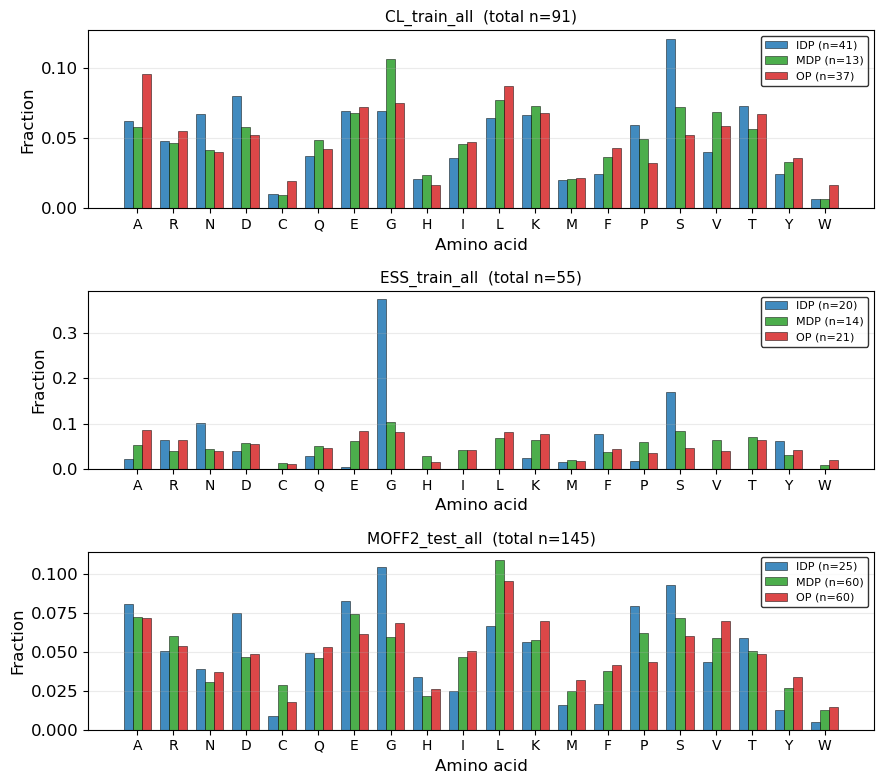

In [73]:
import os
import glob
import numpy as np
import matplotlib.pyplot as plt
from collections import Counter


# ------------------------------------
# Base directory
# ------------------------------------

base_dir = "./protein_classes"



# ------------------------------------
# Amino acids
# ------------------------------------

aa_list = [
    "ALA", "ARG", "ASN", "ASP", "CYS",
    "GLN", "GLU", "GLY", "HIS", "ILE",
    "LEU", "LYS", "MET", "PHE", "PRO",
    "SER", "VAL","THR", "TYR", "TRP",
]

aa_oneletter = {
    "ALA": "A", "ARG": "R", "ASN": "N", "ASP": "D", "CYS": "C",
    "GLN": "Q", "GLU": "E", "GLY": "G", "HIS": "H", "ILE": "I",
    "LEU": "L", "LYS": "K", "MET": "M", "PHE": "F", "PRO": "P",
    "SER": "S", "THR": "T", "TRP": "W", "TYR": "Y", "VAL": "V"
}

aa_labels = [aa_oneletter[a] for a in aa_list]


# ------------------------------------
# Parser
# Expected folder names:
# CL_IDP_train
# CL_MDP_test
# ESS_OP_train
# MOFF2_IDP_test
# ------------------------------------

def parse_folder(folder_name):
    parts = folder_name.split("_")

    if len(parts) < 3:
        raise ValueError(f"Unexpected folder name: {folder_name}")

    dset = parts[0]
    cls = parts[1].upper()
    split = parts[2]

    return dset, cls, split


# ------------------------------------
# Read residues from CA PDB
# ------------------------------------

def read_residues(pdb):
    residues = []

    with open(pdb) as f:
        for line in f:
            if line.startswith("ATOM"):
                atom_name = line[12:16].strip()
                res_name = line[17:20].strip()

                if atom_name == "CA" and res_name in aa_list:
                    residues.append(res_name)

    return residues


def residues_to_key(residues):
    """
    Used for deduplicating identical sequences within each panel.
    """
    return "-".join(residues)


# ------------------------------------
# Panels
# ------------------------------------

panel_names = [
    "CL_train_all",
    #"CL_test_IDP_MDP",
    "ESS_train_all",
    "MOFF2_test_all"
]

panels = {
    panel: {"IDP": [], "MDP": [], "OP": []}
    for panel in panel_names
}

panel_seen = {
    panel: set()
    for panel in panel_names
}


# ------------------------------------
# Collect amino-acid compositions
# ------------------------------------

subfolders = [
    f for f in os.listdir(base_dir)
    if os.path.isdir(os.path.join(base_dir, f))
]

for sub in subfolders:

    folder_path = os.path.join(base_dir, sub)

    try:
        dset, cls, split = parse_folder(sub)
    except Exception:
        continue

    pdbs = glob.glob(os.path.join(folder_path, "*_ca.pdb"))

    for pdb in pdbs:

        residues = read_residues(pdb)

        if len(residues) == 0:
            continue

        key = residues_to_key(residues)

        counter = Counter(residues)
        total = sum(counter.values())

        freq = np.array([
            counter[a] / total
            for a in aa_list
        ])

        # ------------------------------------
        # Assign panel
        # ------------------------------------

        panel = None

        if dset == "CL" and split == "train":
            panel = "CL_train_all"

       # elif dset == "CL" and split == "test" and cls in ["IDP", "MDP"]:
       #     panel = "CL_test_IDP_MDP"

        elif dset == "ESS" and split == "train":
            panel = "ESS_train_all"

        elif dset == "MOFF2" and split == "test":
            panel = "MOFF2_test_all"

        if panel is None:
            continue

        # ------------------------------------
        # Deduplicate within each panel
        # ------------------------------------

        if key not in panel_seen[panel]:
            panels[panel][cls].append(freq)
            panel_seen[panel].add(key)


# ------------------------------------
# Print counts
# ------------------------------------

print("\nProtein counts after deduplication:\n")

for panel in panel_names:
    print(panel)
    for cls in ["IDP", "MDP", "OP"]:
        print(f"  {cls}: {len(panels[panel][cls])}")
    print()


# ------------------------------------
# Plot mean 20-AA composition
# ------------------------------------

colors = {
    "IDP": "tab:blue",
    "MDP": "tab:green",
    "OP": "tab:red"
}

class_order = ["IDP", "MDP", "OP"]

x = np.arange(len(aa_list))
bar_width = 0.25

fig, axes = plt.subplots(
    len(panel_names),
    1,
    figsize=(9, 8),
    #sharex=True,
    #sharey=True
)

if len(panel_names) == 1:
    axes = [axes]


for ax, panel in zip(axes, panel_names):

    total_n = 0

    existing_classes = [
        cls for cls in class_order
        if len(panels[panel][cls]) > 0
    ]

    n_classes = len(existing_classes)

    if n_classes == 0:
        ax.set_title(f"{panel}  (no data)")
        ax.set_ylabel("Fraction")
        continue

    offsets = np.linspace(
        -bar_width * (n_classes - 1) / 2,
        bar_width * (n_classes - 1) / 2,
        n_classes
    )

    for offset, cls in zip(offsets, existing_classes):

        data = np.array(panels[panel][cls])
        n_cls = data.shape[0]
        total_n += n_cls

        mean_freq = data.mean(axis=0)
        std_freq = data.std(axis=0)

        ax.bar(
            x + offset,
            mean_freq,
            width=bar_width,
            color=colors[cls],
            edgecolor="black",
            linewidth=0.4,
            alpha=0.85,
            label=f"{cls} (n={n_cls})"
        )

    ax.set_title(
        f"{panel}  (total n={total_n})",
        fontsize=11
    )

    ax.set_ylabel("Fraction")
    ax.set_xticks(x)
    ax.set_xticklabels(aa_labels, fontsize=10)
    ax.set_xlabel("Amino acid")

    ax.legend(
        fontsize=8,
        frameon=True,
        edgecolor="black",
        loc="upper right"
    )

    ax.grid(axis="y", alpha=0.25)


axes[-1].set_xticks(x)
axes[-1].set_xticklabels(aa_labels, fontsize=10)
axes[-1].set_xlabel("Amino acid")

plt.tight_layout()

# ------------------------------------
# Save
# ------------------------------------

plt.savefig(
    os.path.join(savepath, "FigS1_AA_composition_3classes.pdf")
)
print(savepath)

plt.show()

## Figure S2. Hyperparam scan

df21 default: 577
df22 default_nodensity: 23

Target model found: 1

Thresholds
IDP: 0.12567188756174208
OP : 0.2444028737445792
MDP: 0.13629088947150328

Number of overlapping best models: 4


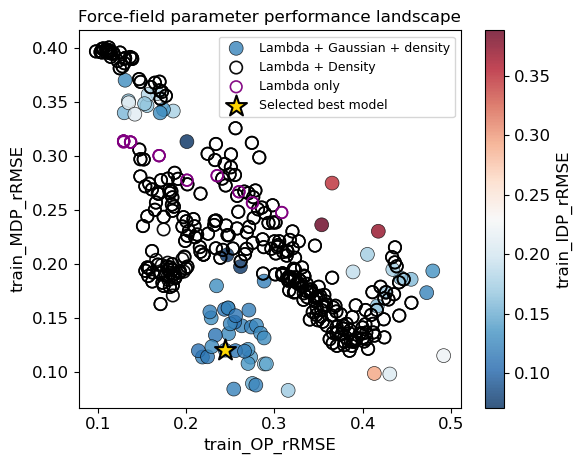


Selected target model:
                                            scale_hps  zeta1  zeta2  \
15  train_CL_ah_gau/results/group_default_IDP_w_0....    1.0  0.005   

    IDP_weight  OP_weight  MDP_weight  train_IDP_rRMSE  train_OP_rRMSE  \
15         0.5        1.0         1.0         0.130337        0.244307   

    train_MDP_rRMSE  
15           0.1203  


In [76]:
#!/usr/bin/env python3

import pandas as pd
import matplotlib.pyplot as plt

# ============================================================
# Load data
# ============================================================

csv_path = "./results/train_CL_ah_gau.csv"

data2 = "./results/train_all_default_mdp_op_0912.csv"

df = pd.read_csv(csv_path)

df = df[df['zeta1']<1.5]
df2 = pd.read_csv(data2)

df2["res_group_mapping"] = df2["res_group_mapping"].astype(str).str.strip()

df21 = df2[df2["res_group_mapping"] == "default"]
df22 = df2[df2["res_group_mapping"] == "default_nodensity"]

print("df21 default:", len(df21))
print("df22 default_nodensity:", len(df22))


# ============================================================
# Target best model
# ============================================================

target_model = (
    "train_CL_ah_gau/results/"
    "group_default_IDP_w_0.5_OP_w_1.0_MDP_w_1.0_10_"
    "zeta_1.0_0.005_gauss_delta_mu_0.25_gauss_width_0.1"
)

# Try to find target_model in any text/object column
target_mask = pd.Series(False, index=df.index)

for col in df.columns:
    if df[col].dtype == "object":
        target_mask |= df[col].astype(str).str.contains(target_model, regex=False, na=False)

target_row = df[target_mask]

print("\nTarget model found:", len(target_row))

if len(target_row) == 0:
    print("\nWARNING: target_model was not found in df.")
    print("Available object columns:")
    print(df.select_dtypes(include="object").columns.tolist())


# ============================================================
# Define good regions only for printing/checking
# No plotting of these outer circles
# ============================================================

IDP_thr = df["train_IDP_rRMSE"].quantile(0.35)
OP_thr  = df["train_OP_rRMSE"].quantile(0.35)
MDP_thr = df["train_MDP_rRMSE"].quantile(0.35)

print("\nThresholds")
print("IDP:", IDP_thr)
print("OP :", OP_thr)
print("MDP:", MDP_thr)

good_IDP = df["train_IDP_rRMSE"] <= IDP_thr
good_OP  = df["train_OP_rRMSE"]  <= OP_thr
good_MDP = df["train_MDP_rRMSE"] <= MDP_thr

best_models = df[good_IDP & good_OP & good_MDP]

print("\nNumber of overlapping best models:", len(best_models))


# ============================================================
# Plot performance landscape
# ============================================================

fig, ax = plt.subplots(figsize=(6, 4.8))

# Main CL landscape
sc = ax.scatter(
    df["train_OP_rRMSE"],
    df["train_MDP_rRMSE"],
    c=df["train_IDP_rRMSE"],
    cmap="RdBu_r",
    s=100,
    edgecolor="black",
    linewidth=0.5,
    alpha=0.80,
    label="Lambda + Gaussian + density"
)

# df2 group 1: default
ax.scatter(
    df21["train_OP_rRMSE"],
    df21["train_MDP_rRMSE"],
    facecolors="none",
    edgecolors="black",
    s=80,
    linewidth=1.2,
    alpha=0.95,
    label="Lambda + Density"
)

# df2 group 2: default_nodensity
ax.scatter(
    df22["train_OP_rRMSE"],
    df22["train_MDP_rRMSE"],
    facecolors="none",
    edgecolors="purple",
    s=70,
    linewidth=1.2,
    alpha=0.95,
    label="Lambda only"
)

# Only target model as yellow star
if len(target_row) > 0:
    ax.scatter(
        target_row["train_OP_rRMSE"],
        target_row["train_MDP_rRMSE"],
        marker="*",
        s=250,
        color="gold",
        edgecolor="black",
        linewidth=1.5,
        zorder=10,
        label="Selected best model"
    )

# Colorbar
cbar = plt.colorbar(sc, ax=ax)
cbar.set_label("train_IDP_rRMSE")

ax.set_xlabel("train_OP_rRMSE")
ax.set_ylabel("train_MDP_rRMSE")
ax.set_title("Force-field parameter performance landscape")

ax.legend(frameon=True, fontsize=9)

plt.tight_layout()
plt.savefig(savepath+'FigureSI_hyperparamter_scan.pdf')
plt.show()


# ============================================================
# Print selected target model
# ============================================================

print("\nSelected target model:")

cols = [
    "scale_hps",
    "zeta1",
    "zeta2",
    "IDP_weight",
    "OP_weight",
    "MDP_weight",
    "train_IDP_rRMSE",
    "train_OP_rRMSE",
    "train_MDP_rRMSE"
]

cols_existing = [c for c in cols if c in df.columns]

if len(target_row) > 0:
    print(target_row[cols_existing])
else:
    print("Target model not found.")

## Figure S9. Reweight vs. Direct MD

[INFO] IDP MD columns:
['result', 'name', 'class', 'ref_rg', 'sim_rg_mean', 'sim_rg_std', 'seq_charge', 'n_residues']
[INFO] IDP reweight columns:
['name', 'Rg_exp', 'Rg_reweight', 'length']
[INFO] Using IDP x column: sim_rg_mean
[INFO] Using IDP y column: Rg_reweight
[INFO] IDP merged entries after cleaning: 9
[INFO] Using IDP charge column: seq_charge
[INFO] OP MD columns:
['result', 'name', 'class', 'sim_rg_mean', 'sim_rg_std', 'n_residues']
[INFO] OP reweight columns:
['name', 'Rg_exp', 'length', 'Rg_pre', 'Rg_pre_err', 'Rg_ess', 'Rg_ess_err']
[INFO] OP merged entries after cleaning: 19
[INFO] Using OP length column: length


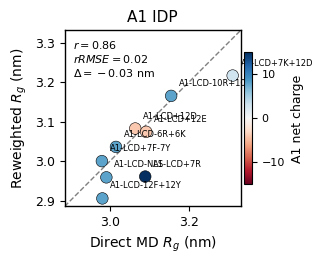

[INFO] Saved: ./manu_figures/direct_MD_vs_reweight_IDP_charge.png
[INFO] Saved: ./manu_figures/direct_MD_vs_reweight_IDP_charge.pdf


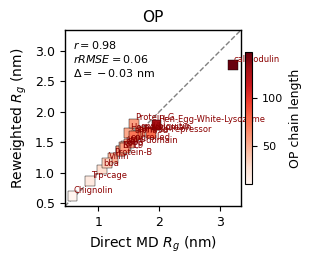

[INFO] Saved: ./manu_figures/direct_MD_vs_reweight_OP_length.png
[INFO] Saved: ./manu_figures/direct_MD_vs_reweight_OP_length.pdf

========== Metrics ==========
IDP: r = 0.8565, rRMSE = 0.0196, delta = -0.0309 nm
OP : r = 0.9771, rRMSE = 0.0614, delta = -0.0267 nm


In [22]:
#!/usr/bin/env python3

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from matplotlib.colors import Normalize, TwoSlopeNorm
from scipy.stats import pearsonr

# ============================================================
# User settings
# ============================================================

data_path = "./results/"
save_path = "./manu_figures/"
os.makedirs(save_path, exist_ok=True)

# IDP / A1-LCD files
data_IDP_MD = data_path + "MOFF2-pc_rg_A1_lcd.csv"
data_IDP_rw = data_path + "rg_summary_a1_pc-model_reweight.csv"

# OP files
data_OP_MD = data_path + "rg_summary_op_pc-model_direct_md.csv"
data_OP_rw = data_path + "collected_model_OP_Rg.csv"

out_png_idp = save_path + "direct_MD_vs_reweight_IDP_charge.png"
out_pdf_idp = save_path + "direct_MD_vs_reweight_IDP_charge.pdf"

out_png_op = save_path + "direct_MD_vs_reweight_OP_length.png"
out_pdf_op = save_path + "direct_MD_vs_reweight_OP_length.pdf"

# ============================================================
# Helper functions
# ============================================================

def find_first_existing_column(df, possible_cols):
    for col in possible_cols:
        if col in df.columns:
            return col
    return None


def clean_merged_df(df, x_col, y_col):
    df = df.copy()

    df[x_col] = pd.to_numeric(df[x_col], errors="coerce")
    df[y_col] = pd.to_numeric(df[y_col], errors="coerce")

    df = df.dropna(subset=[x_col, y_col])

    return df


def get_axis_limits(x, y, pad_frac=0.05):
    x = np.asarray(x, dtype=float)
    y = np.asarray(y, dtype=float)

    xy_min = np.nanmin([np.nanmin(x), np.nanmin(y)])
    xy_max = np.nanmax([np.nanmax(x), np.nanmax(y)])

    pad = pad_frac * (xy_max - xy_min)

    return xy_min - pad, xy_max + pad


def calc_metrics(x, y):
    """
    x = direct MD Rg
    y = reweighted Rg

    rRMSE follows your definition:
        sqrt(mean((x - y)^2 / x^2))

    delta follows:
        mean(y - x)
    """

    x = np.asarray(x, dtype=float)
    y = np.asarray(y, dtype=float)

    mask = np.isfinite(x) & np.isfinite(y) & (x != 0)
    x = x[mask]
    y = y[mask]

    if len(x) < 2:
        return np.nan, np.nan, np.nan

    r, _ = pearsonr(x, y)
    rRMSE = np.sqrt(np.mean((x - y) ** 2 / x ** 2))
    delta = np.mean(y - x)

    return r, rRMSE, delta


def add_metrics_text(ax, x, y, loc=(0.05, 0.95)):
    r, rRMSE, delta = calc_metrics(x, y)

    text = (
        rf"$r = {r:.2f}$" + "\n" +
        rf"$rRMSE = {rRMSE:.2f}$" + "\n" +
        rf"$\Delta = {delta:.2f}$ nm"
    )

    ax.text(
        loc[0],
        loc[1],
        text,
        transform=ax.transAxes,
        fontsize=8,
        ha="left",
        va="top",
        bbox=dict(
            facecolor="white",
            edgecolor="none",
            alpha=0.75,
            pad=2.5
        ),
        zorder=20
    )


def add_point_labels(ax, df, x_col, y_col, label_col="name", color="black"):
    for _, row in df.iterrows():
        ax.text(
            row[x_col] + 0.02,
            row[y_col] + 0.02,
            str(row[label_col]),
            fontsize=6,
            color=color,
            ha="left",
            va="bottom",
            zorder=10
        )


# ============================================================
# Load and merge IDP
# ============================================================

df_IDP_MD = pd.read_csv(data_IDP_MD)
df_IDP_rw = pd.read_csv(data_IDP_rw)

print("[INFO] IDP MD columns:")
print(df_IDP_MD.columns.tolist())

print("[INFO] IDP reweight columns:")
print(df_IDP_rw.columns.tolist())

df_IDP = pd.merge(
    df_IDP_MD,
    df_IDP_rw,
    on="name",
    how="inner",
    suffixes=("_MD", "_rw")
)

# Automatically detect IDP x column
# Put your preferred direct-MD column names first.
idp_x_col = find_first_existing_column(
    df_IDP,
    [
        "sim_rg_mean",
        "MOFF2-pc",
        "MOFF2_pc",
        "MOFF2",
        "Rg_sim",
        "rg_sim",
        "Rg_MD",
        "rg_MD"
    ]
)

idp_y_col = "Rg_reweight"

if idp_x_col is None:
    raise ValueError(
        "Could not find IDP direct-MD Rg column. "
        "Please check df_IDP columns and add the correct column name to idp_x_col candidates."
    )

if idp_y_col not in df_IDP.columns:
    raise ValueError(
        f"Could not find IDP reweight column: {idp_y_col}"
    )

print(f"[INFO] Using IDP x column: {idp_x_col}")
print(f"[INFO] Using IDP y column: {idp_y_col}")

df_IDP = clean_merged_df(
    df_IDP,
    x_col=idp_x_col,
    y_col=idp_y_col
)

print(f"[INFO] IDP merged entries after cleaning: {len(df_IDP)}")

# Detect IDP charge column
idp_charge_col = find_first_existing_column(
    df_IDP,
    [
        "seq_charge",
        "net_charge",
        "charge",
        "q",
        "Q"
    ]
)

if idp_charge_col is None:
    print("[WARNING] No IDP charge column found. IDP points will use one blue color.")
    df_IDP["plot_charge"] = 0.0
    use_charge_cmap = False
else:
    print(f"[INFO] Using IDP charge column: {idp_charge_col}")
    df_IDP["plot_charge"] = pd.to_numeric(df_IDP[idp_charge_col], errors="coerce")
    df_IDP = df_IDP.dropna(subset=["plot_charge"])
    use_charge_cmap = True

# ============================================================
# Load and merge OP
# ============================================================

df_OP_MD = pd.read_csv(data_OP_MD)
df_OP_rw = pd.read_csv(data_OP_rw)

print("[INFO] OP MD columns:")
print(df_OP_MD.columns.tolist())

print("[INFO] OP reweight columns:")
print(df_OP_rw.columns.tolist())

df_OP = pd.merge(
    df_OP_MD,
    df_OP_rw,
    on="name",
    how="inner",
    suffixes=("_MD", "_rw")
)

op_x_col = "sim_rg_mean"
op_y_col = "Rg_pre"

if op_x_col not in df_OP.columns:
    raise ValueError(
        f"Could not find OP direct-MD column: {op_x_col}"
    )

if op_y_col not in df_OP.columns:
    raise ValueError(
        f"Could not find OP reweight column: {op_y_col}"
    )

df_OP = clean_merged_df(
    df_OP,
    x_col=op_x_col,
    y_col=op_y_col
)

print(f"[INFO] OP merged entries after cleaning: {len(df_OP)}")

# Detect OP length column
op_length_col = find_first_existing_column(
    df_OP,
    [
        "length",
        "Length",
        "chain_length",
        "Chain_length",
        "n_res",
        "N_res",
        "nres",
        "Nres",
        "num_residues"
    ]
)

if op_length_col is None:
    print("[WARNING] No OP length column found. OP points will use one red color.")
    df_OP["plot_length"] = 1.0
    use_length_cmap = False
else:
    print(f"[INFO] Using OP length column: {op_length_col}")
    df_OP["plot_length"] = pd.to_numeric(df_OP[op_length_col], errors="coerce")
    df_OP = df_OP.dropna(subset=["plot_length"])
    use_length_cmap = True

# ============================================================
# Figure 1: IDP colored by charge
# ============================================================

fig, ax = plt.subplots(figsize=(3.2, 2.8))

if use_charge_cmap:
    max_abs_charge = np.max(np.abs(df_IDP["plot_charge"].to_numpy()))

    # Avoid zero-width norm if all charges are zero
    if max_abs_charge == 0:
        max_abs_charge = 1.0

    charge_norm = TwoSlopeNorm(
        vmin=-max_abs_charge,
        vcenter=0.0,
        vmax=max_abs_charge
    )

    sc_idp = ax.scatter(
        df_IDP[idp_x_col],
        df_IDP[idp_y_col],
        s=70,
        c=df_IDP["plot_charge"],
        cmap="RdBu",
        norm=charge_norm,
        edgecolors="black",
        linewidths=0.4,
        marker="o",
        zorder=3
    )

    cbar = plt.colorbar(
        sc_idp,
        ax=ax,
        pad=0.02,
        shrink=0.75,
        fraction=0.045,
        aspect=18
    )
    cbar.set_label("A1 net charge", fontsize=9)
    cbar.ax.tick_params(labelsize=8)

else:
    ax.scatter(
        df_IDP[idp_x_col],
        df_IDP[idp_y_col],
        s=50,
        color="#1f77b4",
        edgecolors="black",
        linewidths=0.4,
        marker="o",
        zorder=3
    )

# Protein labels
add_point_labels(
    ax,
    df_IDP,
    x_col=idp_x_col,
    y_col=idp_y_col,
    label_col="name",
    color="black"
)

xy_min, xy_max = get_axis_limits(
    df_IDP[idp_x_col].to_numpy(),
    df_IDP[idp_y_col].to_numpy()
)

ax.plot(
    [xy_min, xy_max],
    [xy_min, xy_max],
    linestyle="--",
    color="gray",
    linewidth=1.0,
    zorder=1
)

add_metrics_text(
    ax,
    df_IDP[idp_x_col].to_numpy(),
    df_IDP[idp_y_col].to_numpy(),
    loc=(0.05, 0.95)
)

ax.set_xlim(xy_min, xy_max)
ax.set_ylim(xy_min, xy_max)
ax.set_aspect("equal", adjustable="box")

ax.set_xlabel(r"Direct MD $R_g$ (nm)", fontsize=10)
ax.set_ylabel(r"Reweighted $R_g$ (nm)", fontsize=10)
ax.set_title("A1 IDP", fontsize=11)

ax.tick_params(axis="both", labelsize=9)

for spine in ax.spines.values():
    spine.set_linewidth(1.0)

plt.tight_layout()
plt.savefig(out_png_idp, dpi=600, bbox_inches="tight")
plt.savefig(out_pdf_idp, bbox_inches="tight")
plt.show()

print(f"[INFO] Saved: {out_png_idp}")
print(f"[INFO] Saved: {out_pdf_idp}")

# ============================================================
# Figure 2: OP colored by length
# ============================================================

fig, ax = plt.subplots(figsize=(3.2, 2.8))

if use_length_cmap:
    cmap = plt.get_cmap("Reds")
    norm = Normalize(
        vmin=df_OP["plot_length"].min(),
        vmax=df_OP["plot_length"].max()
    )

    sc_op = ax.scatter(
        df_OP[op_x_col],
        df_OP[op_y_col],
        s=50,
        c=df_OP["plot_length"],
        cmap=cmap,
        norm=norm,
        edgecolors="black",
        linewidths=0.3,
        marker="s",
        zorder=4
    )

    cbar = plt.colorbar(
        sc_op,
        ax=ax,
        pad=0.02,
        shrink=0.75,
        fraction=0.045,
        aspect=18
    )
    cbar.set_label("OP chain length", fontsize=9)
    cbar.ax.tick_params(labelsize=8)

else:
    ax.scatter(
        df_OP[op_x_col],
        df_OP[op_y_col],
        s=42,
        color="#d62728",
        edgecolors="black",
        linewidths=0.3,
        marker="s",
        zorder=4
    )

# Protein labels
add_point_labels(
    ax,
    df_OP,
    x_col=op_x_col,
    y_col=op_y_col,
    label_col="name",
    color="#8B0000"
)

xy_min, xy_max = get_axis_limits(
    df_OP[op_x_col].to_numpy(),
    df_OP[op_y_col].to_numpy()
)

ax.plot(
    [xy_min, xy_max],
    [xy_min, xy_max],
    linestyle="--",
    color="gray",
    linewidth=1.0,
    zorder=1
)

add_metrics_text(
    ax,
    df_OP[op_x_col].to_numpy(),
    df_OP[op_y_col].to_numpy(),
    loc=(0.05, 0.95)
)

ax.set_xlim(xy_min, xy_max)
ax.set_ylim(xy_min, xy_max)
ax.set_aspect("equal", adjustable="box")

ax.set_xlabel(r"Direct MD $R_g$ (nm)", fontsize=10)
ax.set_ylabel(r"Reweighted $R_g$ (nm)", fontsize=10)
ax.set_title("OP", fontsize=11)

ax.tick_params(axis="both", labelsize=9)

for spine in ax.spines.values():
    spine.set_linewidth(1.0)

plt.tight_layout()
plt.savefig(out_png_op, dpi=600, bbox_inches="tight")
plt.savefig(out_pdf_op, bbox_inches="tight")
plt.show()

print(f"[INFO] Saved: {out_png_op}")
print(f"[INFO] Saved: {out_pdf_op}")

# ============================================================
# Also print metrics to terminal
# ============================================================

idp_r, idp_rrmse, idp_delta = calc_metrics(
    df_IDP[idp_x_col].to_numpy(),
    df_IDP[idp_y_col].to_numpy()
)

op_r, op_rrmse, op_delta = calc_metrics(
    df_OP[op_x_col].to_numpy(),
    df_OP[op_y_col].to_numpy()
)

print("\n========== Metrics ==========")
print(f"IDP: r = {idp_r:.4f}, rRMSE = {idp_rrmse:.4f}, delta = {idp_delta:.4f} nm")
print(f"OP : r = {op_r:.4f}, rRMSE = {op_rrmse:.4f}, delta = {op_delta:.4f} nm")

[INFO] IDP merged entries: 9
[INFO] Using IDP charge column: seq_charge
[INFO] OP merged entries: 19
[INFO] Using OP length column: length


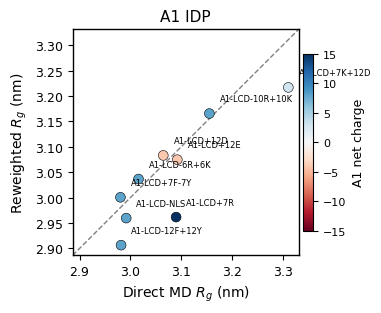

[INFO] Saved: ./manu_figures/direct_MD_vs_reweight_IDP_charge.png
[INFO] Saved: ./manu_figures/direct_MD_vs_reweight_IDP_charge.pdf


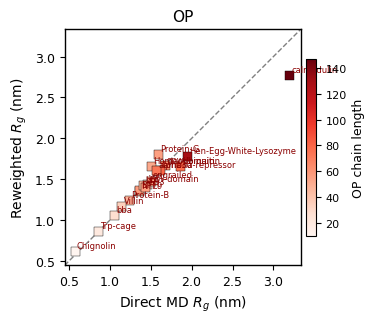

[INFO] Saved: ./manu_figures/direct_MD_vs_reweight_OP.png
[INFO] Saved: ./manu_figures/direct_MD_vs_reweight_OP.pdf


In [17]:
#!/usr/bin/env python3

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import Normalize, TwoSlopeNorm

# ============================================================
# User settings
# ============================================================

data_path = "./results/"
save_path = "./manu_figures/"
os.makedirs(save_path, exist_ok=True)

# IDP / A1-LCD files
data_IDP_MD = data_path + "MOFF2-pc_rg_A1_lcd.csv"
data_IDP_rw = data_path + "rg_summary_a1_pc-model_reweight.csv"

# OP files
data_OP_MD = data_path + "rg_summary_op_pc-model_direct_md.csv"
data_OP_rw = data_path + "collected_model_OP_Rg.csv"

out_png_idp = save_path + "direct_MD_vs_reweight_IDP_charge.png"
out_pdf_idp = save_path + "direct_MD_vs_reweight_IDP_charge.pdf"

out_png_op = save_path + "direct_MD_vs_reweight_OP.png"
out_pdf_op = save_path + "direct_MD_vs_reweight_OP.pdf"

# ============================================================
# Helper functions
# ============================================================

def find_charge_column(df):
    possible_cols = [
        "seq_charge", "net_charge", "charge", "q"
    ]
    for col in possible_cols:
        if col in df.columns:
            return col
    return None


def find_length_column(df):
    possible_cols = [
        "length", "Length", "chain_length", "Chain_length",
        "n_res", "N_res", "nres", "Nres", "num_residues"
    ]
    for col in possible_cols:
        if col in df.columns:
            return col
    return None


def clean_merged_df(df, x_col, y_col):
    df = df.copy()
    df[x_col] = pd.to_numeric(df[x_col], errors="coerce")
    df[y_col] = pd.to_numeric(df[y_col], errors="coerce")
    df = df.dropna(subset=[x_col, y_col])
    return df


def get_axis_limits(x, y, pad_frac=0.05):
    xy_min = np.nanmin([np.min(x), np.min(y)])
    xy_max = np.nanmax([np.max(x), np.max(y)])
    pad = pad_frac * (xy_max - xy_min)
    return xy_min - pad, xy_max + pad


# ============================================================
# Load and merge IDP
# ============================================================

df_IDP_MD = pd.read_csv(data_IDP_MD)
df_IDP_rw = pd.read_csv(data_IDP_rw)

df_IDP = pd.merge(
    df_IDP_MD,
    df_IDP_rw,
    on="name",
    how="inner",
    suffixes=("_MD", "_rw")
)

# NOTE:
# This assumes the direct-MD x column is "sim_rg_mean".
# If your MOFF2-pc_rg_A1_lcd.csv uses another column name
# (for example "MOFF2-pc"), replace x_col below.
df_IDP = clean_merged_df(
    df_IDP,
    x_col="sim_rg_mean",
    y_col="Rg_reweight"
)

print(f"[INFO] IDP merged entries: {len(df_IDP)}")

# Detect IDP charge column
charge_col = find_charge_column(df_IDP)

if charge_col is None:
    print("[WARNING] No IDP charge column found. IDP points will use one blue color.")
    df_IDP["plot_charge"] = 0.0
    use_charge_cmap = False
else:
    print(f"[INFO] Using IDP charge column: {charge_col}")
    df_IDP["plot_charge"] = pd.to_numeric(df_IDP[charge_col], errors="coerce")
    df_IDP = df_IDP.dropna(subset=["plot_charge"])
    use_charge_cmap = True

# ============================================================
# Load and merge OP
# ============================================================

df_OP_MD = pd.read_csv(data_OP_MD)
df_OP_rw = pd.read_csv(data_OP_rw)

df_OP = pd.merge(
    df_OP_MD,
    df_OP_rw,
    on="name",
    how="inner",
    suffixes=("_MD", "_rw")
)

df_OP = clean_merged_df(
    df_OP,
    x_col="sim_rg_mean",
    y_col="Rg_pre"
)

print(f"[INFO] OP merged entries: {len(df_OP)}")

# Detect OP length column
length_col = find_length_column(df_OP)

if length_col is None:
    print("[WARNING] No OP length column found. OP points will use one red color.")
    df_OP["plot_length"] = 1.0
    use_length_cmap = False
else:
    print(f"[INFO] Using OP length column: {length_col}")
    df_OP["plot_length"] = pd.to_numeric(df_OP[length_col], errors="coerce")
    df_OP = df_OP.dropna(subset=["plot_length"])
    use_length_cmap = True

# ============================================================
# Figure 1: IDP colored by charge
# ============================================================

fig, ax = plt.subplots(figsize=(3.8, 3.4))

if use_charge_cmap:
    max_abs_charge = np.max(np.abs(df_IDP["plot_charge"].to_numpy()))
    charge_norm = TwoSlopeNorm(
        vmin=-max_abs_charge,
        vcenter=0.0,
        vmax=max_abs_charge
    )

    sc_idp = ax.scatter(
        df_IDP["sim_rg_mean"],
        df_IDP["Rg_reweight"],
        s=50,
        c=df_IDP["plot_charge"],
        cmap="RdBu",
        norm=charge_norm,
        edgecolors="black",
        linewidths=0.4,
        marker="o",
        zorder=3
    )

    cbar = plt.colorbar(
        sc_idp,
        ax=ax,
        pad=0.02,
        shrink=0.75,
        fraction=0.045,
        aspect=18
    )
    cbar.set_label("A1 net charge", fontsize=9)
    cbar.ax.tick_params(labelsize=8)

else:
    ax.scatter(
        df_IDP["sim_rg_mean"],
        df_IDP["Rg_reweight"],
        s=50,
        color="#1f77b4",
        edgecolors="black",
        linewidths=0.4,
        marker="o",
        zorder=3
    )

# Protein labels
for _, row in df_IDP.iterrows():
    ax.text(
        row["sim_rg_mean"] + 0.02,
        row["Rg_reweight"] + 0.02,
        str(row["name"]),
        fontsize=6,
        color="black",
        ha="left",
        va="bottom",
        zorder=5
    )

xy_min, xy_max = get_axis_limits(
    df_IDP["sim_rg_mean"].to_numpy(),
    df_IDP["Rg_reweight"].to_numpy()
)

ax.plot(
    [xy_min, xy_max],
    [xy_min, xy_max],
    linestyle="--",
    color="gray",
    linewidth=1.0,
    zorder=1
)

ax.set_xlim(xy_min, xy_max)
ax.set_ylim(xy_min, xy_max)
ax.set_aspect("equal", adjustable="box")

ax.set_xlabel(r"Direct MD $R_g$ (nm)", fontsize=10)
ax.set_ylabel(r"Reweighted $R_g$ (nm)", fontsize=10)
ax.set_title("A1 IDP", fontsize=11)

ax.tick_params(axis="both", labelsize=9)
for spine in ax.spines.values():
    spine.set_linewidth(1.0)

plt.tight_layout()
plt.savefig(out_png_idp, dpi=600, bbox_inches="tight")
plt.savefig(out_pdf_idp, bbox_inches="tight")
plt.show()

print(f"[INFO] Saved: {out_png_idp}")
print(f"[INFO] Saved: {out_pdf_idp}")

# ============================================================
# Figure 2: OP colored by length
# ============================================================

fig, ax = plt.subplots(figsize=(3.8, 3.4))

if use_length_cmap:
    cmap = plt.get_cmap("Reds")
    norm = Normalize(
        vmin=df_OP["plot_length"].min(),
        vmax=df_OP["plot_length"].max()
    )

    sc = ax.scatter(
        df_OP["sim_rg_mean"],
        df_OP["Rg_pre"],
        s=42,
        c=df_OP["plot_length"],
        cmap=cmap,
        norm=norm,
        edgecolors="black",
        linewidths=0.3,
        marker="s",
        zorder=4
    )

    cbar = plt.colorbar(
        sc,
        ax=ax,
        pad=0.02,
        shrink=0.75,
        fraction=0.045,
        aspect=18
    )
    cbar.set_label("OP chain length", fontsize=9)
    cbar.ax.tick_params(labelsize=8)

else:
    ax.scatter(
        df_OP["sim_rg_mean"],
        df_OP["Rg_pre"],
        s=42,
        color="#d62728",
        edgecolors="black",
        linewidths=0.3,
        marker="s",
        zorder=4
    )

# Protein labels
for _, row in df_OP.iterrows():
    ax.text(
        row["sim_rg_mean"] + 0.02,
        row["Rg_pre"] + 0.02,
        str(row["name"]),
        fontsize=6,
        color="#8B0000",
        ha="left",
        va="bottom",
        zorder=5
    )

xy_min, xy_max = get_axis_limits(
    df_OP["sim_rg_mean"].to_numpy(),
    df_OP["Rg_pre"].to_numpy()
)

ax.plot(
    [xy_min, xy_max],
    [xy_min, xy_max],
    linestyle="--",
    color="gray",
    linewidth=1.0,
    zorder=1
)

ax.set_xlim(xy_min, xy_max)
ax.set_ylim(xy_min, xy_max)
ax.set_aspect("equal", adjustable="box")

ax.set_xlabel(r"Direct MD $R_g$ (nm)", fontsize=10)
ax.set_ylabel(r"Reweighted $R_g$ (nm)", fontsize=10)
ax.set_title("OP", fontsize=11)

ax.tick_params(axis="both", labelsize=9)
for spine in ax.spines.values():
    spine.set_linewidth(1.0)

plt.tight_layout()
plt.savefig(out_png_op, dpi=600, bbox_inches="tight")
plt.savefig(out_pdf_op, bbox_inches="tight")
plt.show()

print(f"[INFO] Saved: {out_png_op}")
print(f"[INFO] Saved: {out_pdf_op}")